<div style="text-align: center;">
    <img src="logo_tierra_adentro.PNG" alt="Logo Tierra Adentro">
</div>

<div style="text-align: center;">
    <h1>Análisis de Rentabilidad Tierra Adentro 2024</h1>
</div>

<u>Autor:</u> **René Joaquin**  
<u>Fecha:</u> **01/11/2024**





## Índice General

### Parte 1: Limpieza del DataFrame
1. Instalación de Librerías
2. Importación de Librerías
3. Carga de Datos Inicial
4. Eliminación de Columnas Irrelevantes
5. Ajustar la primera fila como nombres de columnas
6. Descripción de la Tabla
7. Renombrar Columnas
8. Guardar Versión Intermedia
9. Limpieza de Fechas (Eliminación de 'hs.', 'Llegó el', etc.)
10. Convertir a DateTime y Separar la Hora
11. Limpieza de Títulos y Extracción de Atributos (Color, Suela, Talle)
12. Limpieza de Domicilio, DNI, Cliente y Ciudad
13. Ajuste Final de Tipos y Estadísticas del DataFrame

### Parte 2: Creación de Base de Datos y Consultas
14. Creación de la Base de Datos y Tablas
15. Consultas SQL sobre la Base de Datos
    - **15.1 Tabla `venta`**
        - 15.1.1 Análisis de Ingresos
        - 15.1.2 Análisis Temporal de Ventas
        - 15.1.3 Análisis de Costos e Impuestos
        - 15.1.4 Análisis de Unidades Vendidas
        - 15.1.5 Tiempos de Entrega y Eficiencia
        - 15.1.6 Tendencias Horarias y Semanales
    - **16. Tabla `publicacion`**
        - 16.1 Análisis General de Publicaciones
        - 16.2 Análisis Específico de Calzados
        - 16.3 Análisis de Productos por Color
        - 16.4 Análisis de Materiales Utilizados
        - 16.5 Análisis de Cuota Agregada
        - 16.6 Productos Más Vendidos (Genérico)
    - **17. Tabla `clientes`**
        - 17.1 Análisis Geográfico de Clientes
        - 17.2 Verificación de Datos y Distribución
        - 17.3 Análisis de Comportamiento de Compra
    - **18. Tabla `envios`**
        - 18.1 Validación de Fechas Coherentes

### Parte 3: Visualizaciones de Datos
19. Visualizaciones - Tabla `venta`
    - Cantidad de Ventas Anual
    - Ingresos Brutos Totales por Año
    - Ventas por Encima/Debajo del Promedio
    - Cargo de Impuesto Mensual
    - Cantidad Anual de Ventas
    - Ventas por Mes
    - Ventas por Día de la Semana
    - Horas Pico de Venta
20. Visualizaciones - Tabla `publicacion`
    - Calzados Más Vendidos
    - Conteo de Publicaciones por Tipo de Producto
    - Ingresos Totales por Tipo de Producto
    - Distribución de Colores en Productos
21. Visualizaciones - Tabla `clientes`
    - Cantidad de Clientes por Provincia
    - Top 10 Ciudades con Más Ventas
    - Barrios con Más Ventas en Capital Federal
    - Top 10 Clientes con Más Compras
22. Visualizaciones - Tabla `envios`
    - Tiempo Promedio de Entrega
    - Envíos por Intervalo de Tiempo del Día
    - Envíos por Día de la Semana



## Introducción al Proyecto

Tierra Adentro Artesanal es un emprendimiento argentino dedicado a la fabricación y venta de productos 
artesanales de cuero (principalmente calzado y accesorios) a través de plataformas como Mercado Libre. 

La finalidad de este proyecto es **analizar la rentabilidad** y el desempeño general de las ventas para 
el año 2024, abordando desde la limpieza de datos hasta la generación de visualizaciones y conclusiones 
que ayuden en la toma de decisiones estratégicas.

### Objetivo General

- Construir un **informe integral** de la rentabilidad de Tierra Adentro Artesanal para el período 2024, 
  identificando patrones de venta, costos, ingresos y oportunidades de mejora.

### Objetivos Específicos

1. **Depurar y Estandarizar** la información de ventas exportada desde Mercado Libre:
   - Eliminar columnas irrelevantes.
   - Limpiar fechas, horas y datos personales (DNI, domicilio).
   - Unificar nombres de productos y extraer atributos clave (color, talle, material).

2. **Crear** un DataFrame final que sirva como **base** para el análisis de rentabilidad:
   - Separar variables (fecha, hora) de un modo que facilite la identificación de horas pico.
   - Calcular métricas como el ingreso total, costos de envío, impuestos y el margen.

3. **Documentar** cada paso del proceso:
   - Explicar en celdas Markdown los métodos de limpieza y transformaciones aplicadas.
   - Guardar el resultado en un archivo Excel definitivo.
     listo para el análisis posterior y la creación de dashboards.

---

A continuación, verás el proceso de principio a fin con el **código** y **comentarios** que explican 
cada paso.


## Parte 1: Limpieza del DataFrame

En esta primera parte, se detallan todas las transformaciones requeridas para preparar 
el dataset proveniente de Mercado Libre, desde la **carga del archivo** hasta la 
**conversión de tipos** y **unificación de columnas**.

A continuación, se muestran los pasos:

1. Cargar Excel original y mostrar contenido.
2. Eliminar columnas irrelevantes.
3. Ajustar primera fila como encabezados.
4. Descripción inicial de la tabla.
5. Renombrar columnas para facilitar análisis.
6. Guardar DataFrame limpio intermedio.
7. Limpieza de fechas y horas (eliminación de texto irrelevante).
8. Separar fechas de horas en columnas diferentes.
9. Limpieza de títulos, variantes (color, suela, talle, etc.).
10. Limpieza de domicilio, DNI, direcciones.
11. Correcciones finales (renombrar, filtrar filas).
12. Conversión de tipos (fechas, horas, numéricos).



### 1. Intalacion de Librerias

In [1]:
# 1.intalacion de las librerias a utilizar
#pip install pandas
#pip install openpyxl
#!pip install matplotlib seaborn plotly
#!pip install plotly geopandas nbformat jupyterlab
#pip install folium

### 2. Importación de Librerías

In [2]:
# 2. Importación de Librerías
import pandas as pd
import locale
import re
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import streamlit as st
import geopandas as gpd
import folium
print("Librerías instaladas y funcionando correctamente")

# Ajuste local para nombres de meses/días en español (puede variar)
locale.setlocale(locale.LC_TIME, 'es_ES.UTF-8')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)



'es_ES.UTF-8'

### 3. Carga de Datos Inicial

Aquí cargamos el archivo `tierra_adentro2024.xlsx` generado por Mercado Libre y mostramos sus primeras filas e informacion de tabla.


In [3]:
#Cargando archivo excel generado por Mercado Libre( Resumen de ventas 2024)
df_mercado_libre=pd.read_excel('C:/Users/Pilar/Desktop/tierra_adentro2024.xlsx')
df_mercado_libre

pd.set_option('display.max_columns', None)
print(df_mercado_libre.head())



             Ventas                      Unnamed: 1              Unnamed: 2  \
0        # de venta                  Fecha de venta                  Estado   
1  2000006410760615  4 de octubre de 2024 09:41 hs.  Paquete de 2 productos   
2  2000008984414606   8 de agosto de 2024 15:27 hs.               Entregado   
3  2000007740393256    4 de marzo de 2024 10:05 hs.               Entregado   
4  2000008953022318   5 de agosto de 2024 16:05 hs.               Entregado   

               Unnamed: 3                   Unnamed: 4 Unnamed: 5  \
0  Descripción del estado  Paquete de varios productos   Unidades   
1                                                             NaN   
2   Llegó el 19 de agosto                           No          1   
3     Llegó el 7 de marzo                           No          1   
4   Llegó el 13 de agosto                           No          1   

                     Unnamed: 6                Unnamed: 7  \
0  Ingresos por productos (ARS)  Ingresos por env

In [4]:
#Informacion de la tabla Mercado Libre
informacion= df_mercado_libre.info()
print(informacion)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Ventas                    260 non-null    object
 1   Unnamed: 1                260 non-null    object
 2   Unnamed: 2                260 non-null    object
 3   Unnamed: 3                260 non-null    object
 4   Unnamed: 4                260 non-null    object
 5   Unnamed: 5                259 non-null    object
 6   Unnamed: 6                258 non-null    object
 7   Unnamed: 7                3 non-null      object
 8   Unnamed: 8                258 non-null    object
 9   Unnamed: 9                257 non-null    object
 10  Unnamed: 10               2 non-null      object
 11  Unnamed: 11               258 non-null    object
 12  Unnamed: 12               260 non-null    object
 13  Publicidad                260 non-null    object
 14  Publicaciones             

In [5]:
df_mercado_libre

,Ventas,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Publicidad,Publicaciones,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Facturación al comprador,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Compradores,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Envíos,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Devoluciones,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Reclamos,Unnamed: 46,Unnamed: 47,Unnamed: 48
0,# de venta,Fecha de venta,Estado,Descripción del estado,Paquete de varios productos,Unidades,Ingresos por productos (ARS),Ingresos por envío (ARS),Cargo por venta e impuestos,Costos de envío,Anulaciones y reembolsos (ARS),Total (ARS),Mes de facturación de tus cargos,Venta por publicidad,SKU,# de publicación,Título de la publicación,Variante,Precio unitario de venta de la publicación (ARS),Tiene cuotas agregadas,Factura adjunta,Datos personales o de empresa,Tipo y número de documento,Dirección,Condición fiscal,Comprador,DNI,Domicilio,Ciudad,Estado,Código postal,País,Forma de entrega,Fecha en camino,Fecha entregado,Transportista,Número de seguimiento,URL de seguimiento,Unidades,Forma de entrega,Fecha en camino,Fecha entregado,Transportista,Número de seguimiento,URL de seguimiento,Unidades,Reclamo abierto,Reclamo cerrado,Con mediación
1,2000006410760615,4 de octubre de 2024 09:41 hs.,Paquete de 2 productos,,,NaN,109118.4,NaN,-19668.6,-10875.98,NaN,78573.82,octubre 2024,,,,,,NaN,,Factura no adjunta,Maria Fernanda Belani,DNI 29756388,"acerboni 387, Buenos Aires - C.P.: 1665, Bueno...",Consumidor Final,Maria Fernanda Belani,29756388,acerboni 387 / Referencia: Casa De 1 Planta Co...,Buenos Aires,Buenos Aires,1665,Argentina,Correo y puntos de despacho,4 de octubre | 11:51,9 de octubre | 11:22,Correo Argentino,1627683X2521IXA501,http://www.correoargentino.com.ar/empresas/tyt...,,,,,,,,NaN,,NaN,
2,2000008984414606,8 de agosto de 2024 15:27 hs.,Entregado,Llegó el 19 de agosto,No,1,53045.3,NaN,-10078.61,-5357.49,NaN,37609.2,agosto 2024,,,MLA1127127025,Agenda Cuero Tierra Adentro A5 Diaria Lazo.,Color : Negro,53045.3,Sí,Factura no adjunta,Camila Fong,CUIT 27399085689,"Tucuman 540, San Nicolás - C.P.: 1049, Capital...",IVA Responsable Inscripto,Camila Fong,27399085689,Calle 7 1260 / Referencia: es en un local de c...,La Plata,Buenos Aires,1900,Argentina,Correo y puntos de despacho,12 de agosto | 18:06,19 de agosto | 11:25,Correo Argentino,162763PC2A3P5MC601,http://www.correoargentino.com.ar/empresas/tyt...,,,,,,,,NaN,No,NaN,No
3,2000007740393256,4 de marzo de 2024 10:05 hs.,Entregado,Llegó el 7 de marzo,No,1,36835.11,NaN,-6707.31,-3384.99,NaN,26742.81,marzo 2024,,,MLA706942163,Alpargatas Cuero Genuino Combinada -tierra Ade...,Color : Otro | Talle : 42,36835.11,Sí,Factura adjunta,Beatriz Dora Lequerica,DNI 09748401,"Calle Sosa 835 835, capilla del señor - C.P.: ...",Consumidor Final,Beatriz Dora Lequerica,09748401,Calle Sosa 835 / xxx Entre: Rauch y Soldado M...,capilla del señor,Buenos Aires,2812,Argentina,Correo y puntos de despacho,4 de marzo | 11:40,7 de marzo | 09:50,Correo Argentino,1627630T9E41201501,http://www.correoargentino.com.ar/empresas/tyt...,,,,,,,,NaN,No,NaN,No
4,2000008953022318,5 de agosto de 2024 16:05 hs.,Entregado,Llegó el 13 de agosto,No,1,34923,NaN,-6111.52,-4643.49,NaN,24167.99,agosto 2024,,,MLA1124694526,Alpargatas Cuero Tierra Adentro Adulto Unisex,Color : Marrón oscuro | Talle : 41,34923,Sí,Factura no adjunta,Angel José Vega,DNI 12977266,"Calle Belgrano 720, Seguí - C.P.: 3117, Entre ...",Consumidor Final,Angel José Vega,12977266,"Calle Belgrano 720 / CP 3117 - Seguí, Entre Ríos",Seguí,Entre Ríos,3117,Argentina,Correo y puntos de despacho,12 de agosto | 18:06,13 de agosto | 08:19,Correo Argentino,162761PCLCAC16C601,http://www.correoargentino.com.ar/empresas/tyt...,,,,,,,,NaN,No,NaN,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

### 4. Eliminación de Columnas Irrelevantes

Definimos una lista de columnas que no aportan al análisis y las removemos del DataFrame.


In [6]:
columnas_a_eliminar = [
    'Publicidad', 'Publicaciones', 'Facturación al comprador', 'Unnamed: 2','Unnamed: 7','Unnamed: 10','Unnamed: 12', 'Ingresos por envío (ARS)', 'Mes de facturación de tus cargos','Unnamed: 22','Unnamed: 24',
     'Unnamed: 27', 'Unnamed: 36', 'Unnamed: 37','Unnamed: 37' 'Devoluciones', 'Reclamos', 'Unnamed: 39','Ingresos por envío (ARS)',
    'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44',
    'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Tipo y número de documento',
    'Compradores', 'estado', 'Devoluciones'
]

df_mercado_libre = df_mercado_libre.drop(columns=columnas_a_eliminar, errors='ignore')

df_mercado_libre

,Ventas,Unnamed: 1,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 8,Unnamed: 9,Unnamed: 11,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 21,Unnamed: 23,Unnamed: 26,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Envíos,Unnamed: 33,Unnamed: 34,Unnamed: 35
0,# de venta,Fecha de venta,Descripción del estado,Paquete de varios productos,Unidades,Ingresos por productos (ARS),Cargo por venta e impuestos,Costos de envío,Total (ARS),# de publicación,Título de la publicación,Variante,Precio unitario de venta de la publicación (ARS),Tiene cuotas agregadas,Datos personales o de empresa,Dirección,DNI,Ciudad,Estado,Código postal,País,Forma de entrega,Fecha en camino,Fecha entregado,Transportista
1,2000006410760615,4 de octubre de 2024 09:41 hs.,,,NaN,109118.4,-19668.6,-10875.98,78573.82,,,,NaN,,Maria Fernanda Belani,"acerboni 387, Buenos Aires - C.P.: 1665, Bueno...",29756388,Buenos Aires,Buenos Aires,1665,Argentina,Correo y puntos de despacho,4 de octubre | 11:51,9 de octubre | 11:22,Correo Argentino
2,2000008984414606,8 de agosto de 2024 15:27 hs.,Llegó el 19 de agosto,No,1,53045.3,-10078.61,-5357.49,37609.2,MLA1127127025,Agenda Cuero Tierra Adentro A5 Diaria Lazo.,Color : Negro,53045.3,Sí,Camila Fong,"Tucuman 540, San Nicolás - C.P.: 1049, Capital...",27399085689,La Plata,Buenos Aires,1900,Argentina,Correo y puntos de despacho,12 de agosto | 18:06,19 de agosto | 11:25,Correo Argentino
3,2000007740393256,4 de marzo de 2024 10:05 hs.,Llegó el 7 de marzo,No,1,36835.11,-6707.31,-3384.99,26742.81,MLA706942163,Alpargatas Cuero Genuino Combinada -tierra Ade...,Color : Otro | Talle : 42,36835.11,Sí,Beatriz Dora Lequerica,"Calle Sosa 835 835, capilla del señor - C.P.: ...",09748401,capilla del señor,Buenos Aires,2812,Argentina,Correo y puntos de despacho,4 de marzo | 11:40,7 de marzo | 09:50,Correo Argentino
4,2000008953022318,5 de agosto de 2024 16:05 hs.,Llegó el 13 de agosto,No,1,34923,-6111.52,-4643.49,24167.99,MLA1124694526,Alpargatas Cuero Tierra Adentro Adulto Unisex,Color : Marrón oscuro | Talle : 41,34923,Sí,Angel José Vega,"Calle Belgrano 720, Seguí - C.P.: 3117, Entre ...",12977266,Seguí,Entre Ríos,3117,Argentina,Correo y puntos de despacho,12 de agosto | 18:06,13 de agosto | 08:19,Correo Argentino
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,2000009114555526,23 de agosto de 2024 18:46 hs.,Llegó el 28 de agosto,No,1,34642.3,-9526.63,-4414.49,20701.18,MLA716518479,Tabaquera Artesanal Cuero Genuino - Tierra Ade...,Color : Negro | Talle : 30,34642.3,Sí,Carmela Colus,"italia 5043 5043, Benavidez - C.P.: 1621, Buen...",45201410,Benavidez,Buenos Aires,1621,Argentina,Correo y puntos de despacho,26 de agosto | 15:33,28 de agosto | 15:00,Correo Argentino
256,2000008843868670,23 de julio de 2024 01:19 hs.,Llegó el 5 de agosto,No,1,38241.5,-7265.88,-4414.49,26561.13,MLA716518479,Tabaquera Artesanal Cuero Genuino - Tierra Ade...,Color : Marrón claro | Talle : 30,38241.5,Sí,Rodrigo Gonzalo Bastida,"3 de febrero 1755 1755, General Roca - C.P.: 8...",35207620,General Roca,Río Negro,8332,Argentina,Correo y puntos de despacho,29 de julio | 17:55,5 de agosto | 12:43,Correo Argentino
257,2000008999722138,10 de agosto de 2024 12:33 hs.,Llegó el 20 de agosto,No,1,37722.3,-7167.23,-4414.49,26140.58,MLA917503004,Tierra Adentro Artesanal Diario Moleskine Cove...,Color : Marrón,37722.3,Sí,Maria Carolina Carnicero,"Avenida 26 390 390, Miramar - C.P.: 7607, Buen...",22007893,Miramar,Buenos Aires,7607,Argentina,Correo y puntos de despacho,14 de agosto | 15:52,20 de agosto | 09:06,Correo Argentino
258,2000008699556786,5 de julio de 2024 20:46 hs.,Llegó el 15 de julio,No,1,52990,-10598,-4414.49,37977.51,MLA1144160292,Tierra Adentro Estuche 1 Pipa Roll Cuero,,52990,Sí,Augusto Javier Conci,"Zado 3452, Villa Urquiza - C.P.: 1431, Capital...",35253411,CIUDAD AUTONOMA BUENOS AIRES,Capital Federal,1431,Argentina,Correo y puntos de despacho,8 de julio | 17:07,15 de julio | 20:01,Co

### 5. Ajustar la primera fila como nombres de columnas

El archivo Excel suele traer una fila adicional como “header”. 
Con este paso, convertimos esa fila en los encabezados.


In [7]:
# Hacer que la primera fila se convierta en los nombres de las columnas
df_mercado_libre.columns = df_mercado_libre.iloc[0]  # Asignar la primera fila como nombres de columna
df_mercado_libre = df_mercado_libre.drop(0).reset_index(drop=True)  # Eliminar la primera fila y reiniciar el índice

# Verificar el resultado
print(df_mercado_libre.head())


0        # de venta                  Fecha de venta Descripción del estado  \
0  2000006410760615  4 de octubre de 2024 09:41 hs.                          
1  2000008984414606   8 de agosto de 2024 15:27 hs.  Llegó el 19 de agosto   
2  2000007740393256    4 de marzo de 2024 10:05 hs.    Llegó el 7 de marzo   
3  2000008953022318   5 de agosto de 2024 16:05 hs.  Llegó el 13 de agosto   
4  2000008712814252    7 de julio de 2024 18:57 hs.   Llegó el 16 de julio   

0 Paquete de varios productos Unidades Ingresos por productos (ARS)  \
0                                  NaN                     109118.4   
1                          No        1                      53045.3   
2                          No        1                     36835.11   
3                          No        1                        34923   
4                          No        1                        29934   

0 Cargo por venta e impuestos Costos de envío Total (ARS) # de publicación  \
0                    -1966

### 6. Descripción de la Tabla

Revisamos estadísticos básicos para entender la dimensión del dataset.


In [8]:
# Descripcion de la tabla Mercado Libre
descripcion_tabla=df_mercado_libre.describe()
print(descripcion_tabla)

0             # de venta                  Fecha de venta  \
count                259                             259   
unique               259                             256   
top     2000006410760615  4 de octubre de 2024 09:41 hs.   
freq                   1                               3   

0       Descripción del estado Paquete de varios productos  Unidades  \
count                      259                         259       258   
unique                     134                           3         2   
top     Llegó el 10 de octubre                          No         1   
freq                         5                         240       257   

0       Ingresos por productos (ARS)  Cargo por venta e impuestos  \
count                         257.00                       257.00   
unique                        162.00                       198.00   
top                         42300.48                     -7617.89   
freq                           16.00                        10

### 7. Renombrar Columnas

definimos nombres a las columnas para facilitar el análisis y posteriormente la carga en base de datos.


In [9]:
#renombrando las columnas a utilizar del dataframe
df_mercado_libre=df_mercado_libre.rename(columns= {
    '# de venta': 'id_venta', 
    'Fecha de venta': 'fecha_venta',
    'Descripción del estado': 	'fecha_recepcion',
    'Paquete de varios productos': 'es_paquete_producto',
    'Unidades':	'unidades_ vendidas',
    'Ingresos por productos (ARS)':	'ingresos_por_productos',
    'Cargo por venta e impuestos': 'cargo_venta_impuesto',
    'Costos de envío': 'costos_envios',
    'Total (ARS)': 'total', 
    '# de publicación' : 'id_publicacion',
    'Título de la publicación':'titulo_publicacion' ,
    'Precio unitario de venta de la publicación (ARS)':'ingresos_productos',
    'Tiene cuotas agregadas':'cuota_agregada',
    'Datos personales o de empresa':'cliente',
    'Dirección':'Domicilio',
    'Estado':'Provincia',
    'Forma de entrega':'forma_entrega',
    'Fecha en camino':'fecha_envio',
    'Fecha entregado':'fecha_entrega',
    'Código postal' : 'codigo_postal'
})



#mostrando datafreame con los renombres de columnas 
df_mercado_libre

,id_venta,fecha_venta,fecha_recepcion,es_paquete_producto,unidades_ vendidas,ingresos_por_productos,cargo_venta_impuesto,costos_envios,total,id_publicacion,titulo_publicacion,Variante,ingresos_productos,cuota_agregada,cliente,Domicilio,DNI,Ciudad,Provincia,codigo_postal,País,forma_entrega,fecha_envio,fecha_entrega,Transportista
0,2000006410760615,4 de octubre de 2024 09:41 hs.,,,NaN,109118.4,-19668.6,-10875.98,78573.82,,,,NaN,,Maria Fernanda Belani,"acerboni 387, Buenos Aires - C.P.: 1665, Bueno...",29756388,Buenos Aires,Buenos Aires,1665,Argentina,Correo y puntos de despacho,4 de octubre | 11:51,9 de octubre | 11:22,Correo Argentino
1,2000008984414606,8 de agosto de 2024 15:27 hs.,Llegó el 19 de agosto,No,1,53045.3,-10078.61,-5357.49,37609.2,MLA1127127025,Agenda Cuero Tierra Adentro A5 Diaria Lazo.,Color : Negro,53045.3,Sí,Camila Fong,"Tucuman 540, San Nicolás - C.P.: 1049, Capital...",27399085689,La Plata,Buenos Aires,1900,Argentina,Correo y puntos de despacho,12 de agosto | 18:06,19 de agosto | 11:25,Correo Argentino
2,2000007740393256,4 de marzo de 2024 10:05 hs.,Llegó el 7 de marzo,No,1,36835.11,-6707.31,-3384.99,26742.81,MLA706942163,Alpargatas Cuero Genuino Combinada -tierra Ade...,Color : Otro | Talle : 42,36835.11,Sí,Beatriz Dora Lequerica,"Calle Sosa 835 835, capilla del señor - C.P.: ...",09748401,capilla del señor,Buenos Aires,2812,Argentina,Correo y puntos de despacho,4 de marzo | 11:40,7 de marzo | 09:50,Correo Argentino
3,2000008953022318,5 de agosto de 2024 16:05 hs.,Llegó el 13 de agosto,No,1,34923,-6111.52,-4643.49,24167.99,MLA1124694526,Alpargatas Cuero Tierra Adentro Adulto Unisex,Color : Marrón oscuro | Talle : 41,34923,Sí,Angel José Vega,"Calle Belgrano 720, Seguí - C.P.: 3117, Entre ...",12977266,Seguí,Entre Ríos,3117,Argentina,Correo y puntos de despacho,12 de agosto | 18:06,13 de agosto | 08:19,Correo Argentino
4,2000008712814252,7 de julio de 2024 18:57 hs.,Llegó el 16 de julio,No,1,29934,-5238.45,-4414.49,20281.06,MLA1124694526,Alpargatas Cuero Tierra Adentro Adulto Unisex,Color : Azul | Talle : 46,29934,Sí,Daniel Horacio Maero,"Alejandro Magariños Cervantes 3375, Santa Rita...",12228306,CIUDAD AUTONOMA BUENOS AIRES,Capital Federal,1407,Argentina,Correo y puntos de despacho,12 de julio | 15:56,16 de julio | 18:19,Correo Argentino
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254,2000009114555526,23 de agosto de 2024 18:46 hs.,Llegó el 28 de agosto,No,1,34642.3,-9526.63,-4414.49,20701.18,MLA716518479,Tabaquera Artesanal Cuero Genuino - Tierra Ade...,Color : Negro | Talle : 30,34642.3,Sí,Carmela Colus,"italia 5043 5043, Benavidez - C.P.: 1621, Buen...",45201410,Benavidez,Buenos Aires,1621,Argentina,Correo y puntos de despacho,26 de agosto | 15:33,28 de agosto | 15:00,Correo Argentino
255,2000008843868670,23 de julio de 2024 01:19 hs.,Llegó el 5 de agosto,No,1,38241.5,-7265.88,-4414.49,26561.13,MLA716518479,Tabaquera Artesanal Cuero Genuino - Tierra Ade...,Color : Marrón claro | Talle : 30,38241.5,Sí,Rodrigo Gonzalo Bastida,"3 de febrero 1755 1755, General Roca - C.P.: 8...",35207620,General Roca,Río Negro,8332,Argentina,Correo y puntos de despacho,29 de julio | 17:55,5 de agosto | 12:43,Correo Argentino
256,2000008999722138,10 de agosto de 2024 12:33 hs.,Llegó el 20 de agosto,No,1,37722.3,-7167.23,-4414.49,26140.58,MLA917503004,Tierra Adentro Artesanal Diario Moleskine Cove...,Color : Marrón,37722.3,Sí,Maria Carolina Carnicero,"Avenida 26 390 390, Miramar - C.P.: 7607, Buen...",22007893,Miramar,Buenos Aires,7607,Argentina,Correo y puntos de despacho,14 de agosto | 15:52,20 de agosto | 09:06,Correo Argentino
257,2000008699556786,5 de julio de 2024 20:46 hs.,Llegó el 15 de julio,No,1,52990,-10598,-4414.49,37977.51,MLA1144160292,Tierra Adentro Estuche 1 Pipa Roll Cuero,,52990,Sí,Augusto Javier Conci,"Zado 3452, Villa Urquiza - C.P.: 1431, Capital...",35253411,CIUDAD AUTONOMA BUENOS AIRES,Capital Federal,1431,Argentina,Correo y puntos de despacho,8 

In [10]:
# Buscando los indices que corresponden a cada columna del data freame 
for idx, col in enumerate(df_mercado_libre.columns):
    print(idx, col)


0 id_venta
1 fecha_venta
2 fecha_recepcion
3 es_paquete_producto
4 unidades_ vendidas
5 ingresos_por_productos
6 cargo_venta_impuesto
7 costos_envios
8 total
9 id_publicacion
10 titulo_publicacion
11 Variante
12 ingresos_productos
13 cuota_agregada
14 cliente
15 Domicilio
16 DNI
17 Ciudad
18 Provincia
19 codigo_postal
20 País
21 forma_entrega
22 fecha_envio
23 fecha_entrega
24 Transportista


### 8. Guardar Versión Intermedia

Se guarda un archivo `tierra_adentro_2024_limpio.xlsx` que conserva los cambios hasta este punto.


In [11]:
#guardando data freame limpio
df_mercado_libre.to_excel('C:/Users/Pilar/Desktop/tierra_adentro_2024_limpio.xlsx', index=False)

In [ ]:
df_mercado_libre=pd.read_excel('C:/Users/Pilar/Desktop/tierra_adentro_2024_limpio.xlsx')
pd.set_option('display.max_columns', None)
df_mercado_libre

### 9. Limpieza de Fechas (Eliminación de 'hs.', 'Llegó el', etc.)


In [ ]:
df_mercado_libre = pd.read_excel('C:/Users/Pilar/Desktop/tierra_adentro_2024_limpio.xlsx')

df_mercado_libre.loc[:, 'fecha_venta'] = df_mercado_libre['fecha_venta'].str.replace(' hs.', '', regex=False)
df_mercado_libre.loc[:, 'fecha_recepcion'] = df_mercado_libre['fecha_recepcion'].str.replace('Llegó el ', '', regex=False)
df_mercado_libre.loc[:, 'fecha_envio'] = df_mercado_libre['fecha_envio'].str.replace(' | ', ' ', regex=False)
df_mercado_libre.loc[:, 'fecha_entrega'] = df_mercado_libre['fecha_entrega'].str.replace(' | ', ' ', regex=False)

df_mercado_libre.loc[:, 'fecha_recepcion'] = df_mercado_libre['fecha_recepcion'] + ' de 2024'
df_mercado_libre.loc[:, 'fecha_envio'] = df_mercado_libre['fecha_envio'].str.replace(
    r'(\d+ de \w+)', r'\1 de 2024', regex=True
)
df_mercado_libre.loc[:, 'fecha_entrega'] = df_mercado_libre['fecha_entrega'].str.replace(
    r'(\d+ de \w+)', r'\1 de 2024', regex=True
)

df_mercado_libre


### 10. Convertir a DateTime y Separar la Hora

Separamos la hora en columnas `hora_venta`, `hora_envio`, `hora_entrega`.


In [ ]:
# Guardamos y recargamos
df_mercado_libre.to_excel('C:/Users/Pilar/Desktop/tierra_adentro_2024_limpio.xlsx', index=False)
df_mercado_libre = pd.read_excel('C:/Users/Pilar/Desktop/tierra_adentro_2024_limpio.xlsx')

# Convertir a datetime con formatos
df_mercado_libre['fecha_venta'] = pd.to_datetime(df_mercado_libre['fecha_venta'], format='%d de %B de %Y %H:%M', errors='coerce')
df_mercado_libre['fecha_recepcion'] = pd.to_datetime(df_mercado_libre['fecha_recepcion'], format='%d de %B de %Y', errors='coerce')
df_mercado_libre['fecha_envio'] = pd.to_datetime(df_mercado_libre['fecha_envio'], format='%d de %B de %Y %H:%M', errors='coerce')
df_mercado_libre['fecha_entrega'] = pd.to_datetime(df_mercado_libre['fecha_entrega'], format='%d de %B de %Y %H:%M', errors='coerce')

# Extraer la parte hora
hora_venta = df_mercado_libre['fecha_venta'].dt.time
hora_envio = df_mercado_libre['fecha_envio'].dt.time
hora_entrega = df_mercado_libre['fecha_entrega'].dt.time

# Dejar solo la parte fecha
df_mercado_libre['fecha_venta'] = df_mercado_libre['fecha_venta'].dt.date
df_mercado_libre['fecha_envio'] = df_mercado_libre['fecha_envio'].dt.date
df_mercado_libre['fecha_entrega'] = df_mercado_libre['fecha_entrega'].dt.date

# Insertar las columnas de hora
df_mercado_libre.insert(df_mercado_libre.columns.get_loc('fecha_venta')+1, 'hora_venta', hora_venta)
df_mercado_libre.insert(df_mercado_libre.columns.get_loc('fecha_envio')+1, 'hora_envio', hora_envio)
df_mercado_libre.insert(df_mercado_libre.columns.get_loc('fecha_entrega')+1, 'hora_entrega', hora_entrega)

df_mercado_libre


In [15]:
df_mercado_libre

,id_venta,fecha_venta,hora_venta,fecha_recepcion,es_paquete_producto,unidades_ vendidas,ingresos_por_productos,cargo_venta_impuesto,costos_envios,total,id_publicacion,titulo_publicacion,Variante,ingresos_productos,cuota_agregada,cliente,Domicilio,DNI,Ciudad,Provincia,codigo_postal,País,forma_entrega,fecha_envio,hora_envio,fecha_entrega,hora_entrega,Transportista
0,2000009621140658,2024-10-21,18:16:00,2024-10-28,No,1.0,63470.80,-11440.61,-4805.99,47224.20,MLA749984850,Sandalias De Cuero Casual Para Mujer - Primave...,Color : Marrón | Talle : 42,63470.80,Sí,Fernando Daniel Gigena,"Calle Donofrio 230, Lobería - C.P.: 7635, Buen...",33536999,Lobería,Buenos Aires,7635,Argentina,Correo y puntos de despacho,2024-10-23,11:40:00,2024-10-28,11:16:00,Correo Argentino
1,2000009614906152,2024-10-21,03:41:00,2024-10-29,No,1.0,115200.00,-35049.60,-4805.99,75344.41,MLA762670510,Sandalias Artesanal Atenea Cuero Genuino Casua...,Color : Negro | Nombre del diseño : Atenea | T...,115200.00,Sí,Luciana Karina Figueroa,"Calle calle mendoza 210, colonia santa rosa - ...",33056006,colonia santa rosa,Salta,4531,Argentina,Correo y puntos de despacho,2024-10-23,11:40:00,2024-10-29,12:58:00,Correo Argentino
2,2000009611759696,2024-10-20,18:46:00,2024-10-24,No,1.0,99180.00,-28687.82,-5437.99,65054.19,MLA762156720,Sandalia Artesanal Cruz Cuero Goma Flexible - ...,Color : Marrón | Talle : 39 AR,99180.00,Sí,Milagros del Carmen Ceparo,"CORRIENTES 328 Piso:2 Dpto:B 328, PARANA - C.P...",27374700044,Paraná,Entre Ríos,3100,Argentina,Correo y puntos de despacho,2024-10-23,11:40:00,2024-10-24,10:14:00,Correo Argentino
3,2000009609844830,2024-10-20,14:16:00,2024-10-29,No,1.0,111360.00,-32210.88,-5437.99,73711.13,MLA614277985,Sandalias Birk Mujer Cuero Genuino Artesanal C...,Color : Negro | Talle : 41 AR,111360.00,Sí,Alejandra del Roeaeic Lujan,"Jaramillo 3894, Saavedra - C.P.: 1430, Capital...",24356029,Saavedra,Capital Federal,1429,Argentina,Correo y puntos de despacho,2024-10-23,11:40:00,2024-10-29,10:48:00,Correo Argentino
4,2000009604986264,2024-10-19,17:51:00,2024-10-24,No,1.0,62917.20,-14423.77,-4805.99,43687.44,MLA1444950203,Sandalia Cuero Arcaica Goma Artesanal Stock,Color : Marrón | Nombre del diseño : Arcaica G...,62917.20,Sí,Laura Carina Lambertucci,"Av. Fuerza Aérea 3808, Córdoba - C.P.: 5011, C...",27219018822,Córdoba,Córdoba,5011,Argentina,Correo y puntos de despacho,2024-10-21,12:57:00,2024-10-24,09:38:00,Correo Argentino
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254,2000007321115300,2024-01-06,18:59:00,2024-01-17,No,1.0,42300.48,-7617.89,-2032.49,32650.10,MLA761693227,Sandalia Cuero Arcaica Básica - Tierra Adentr...,Color : Blanco | Talle : 36 AR,42300.48,Sí,Maria Graciela D' Alessandro,"Mamuel Choique 665, Las grutas - C.P.: 8521, R...",14378959,Las grutas,Río Negro,8521,Argentina,Correo y puntos de despacho,2024-01-12,16:19:00,2024-01-17,09:51:00,Correo Argentino
255,2000007320915992,2024-01-06,18:27:00,2024-01-15,No,1.0,42300.48,-7617.89,-2032.49,32650.10,MLA1194793002,Sandalias Cuero Gladiadoras Mujer Artesanal Ti...,Color : Negro | Nombre del diseño : Carmen | T...,42300.48,Sí,Evangelina Negretti,"Fray Cayetano Rodriguez 1062, Villa Adelina - ...",20385665,Villa Adelina,Buenos Aires,1607,Argentina,Correo y puntos de despacho,2024-01-12,16:19:00,2024-01-15,12:24:00,Correo Argentino
256,2000007309886292,2024-01-05,07:36:00,2024-01-15,No,1.0,39906.11,-7186.69,-2032.49,30686.93,MLA742754747,Sandalias Cuero Helénica Anillo - Tierra Adent...,Color : Marrón | Talle : 43 AR,39906.11,Sí,Carlos Roberto Perassi,"belgrano 715, general baldissera - C.P.: 2583,...",20178733789,general baldissera,Córdoba,2583,Argentina,Correo y puntos de despacho,2024-01-10,13:25:00,2024-01-15,11:00:00,Correo Argentino
257,2000007301302260,2024-01-04,06:58:00,2024-01-15,No,1.0,39906.11,-7186.69,-2032.49,30686.93,MLA1218102827,Sandalia Cuero Mujer Tira Chatitas Artesanal T...,Color : Negro | Talle : 42 AR

In [16]:
df_mercado_libre.to_excel('C:/Users/Pilar/Desktop/tierra_adentro_2024_limpio.xlsx', index=False)

### 11. Limpieza de Títulos y Extracción de Atributos (Color, Suela, Talle)

En esta parte, realizamos los siguientes pasos:

1. Definimos y aplicamos una lista de palabras irrelevantes en `titulo_publicacion_limpio`.  
2. Movemos la columna `titulo_publicacion_limpio` a la posición 12 y unificamos con `titulo_publicacion`.  
3. Extraemos `color`, `suela` y `talle` desde la columna `Variante`.  
4. Ajustamos el orden de las columnas tras la extracción.  
5. Unificamos `titulo_publicacion` por `id_publicacion` (tomando el más frecuente).  
6. Limpiamos la suela dentro del título, eliminando duplicados.  
7. Eliminamos caracteres `-`, `/` y estandarizamos la suela con “Goma plana”.  
8. Finalmente, guardamos en el archivo `tierra_adentro_2024_limpio_3.xlsx`.  




In [ ]:
import re
import pandas as pd

# ------------------------------------------------------------------------------
# DEFINICIÓN DE PALABRAS IRRELEVANTES EN 'titulo_publicacion_limpio'
# ------------------------------------------------------------------------------
palabras_irrelevantes = [
    "Tierra", "Adentro", "Artesanal", "Personalizado", "Unisex", "Adulto", "Adultos",
    "Stock", "Primavera", "Verano", "Primavera/Verano", "2025", "/", "Vacuno", "Ta Ar", "Paraná", "Art"
]
patron_irrelevantes = re.compile(r'\b(?:' + '|'.join(palabras_irrelevantes) + r')\b', flags=re.IGNORECASE)

def limpiar_titulo_publicacion(titulo):
    """
    Elimina palabras irrelevantes y guiones, corrige espacios 
    y capitaliza cada palabra del título.
    """
    if not isinstance(titulo, str):
        return titulo
    # Eliminar las palabras irrelevantes
    titulo = patron_irrelevantes.sub("", titulo)
    # Eliminar guiones y espacios extra
    titulo = re.sub(r"[-]", "", titulo)
    titulo = re.sub(r"\s{2,}", " ", titulo).strip()
    # Capitalizar cada palabra
    return titulo.title()

# OPCIONAL: Verificación de algunas filas (puedes comentar o eliminar si no deseas ver outputs)
#print(df_mercado_libre[['titulo_publicacion', 'titulo_publicacion_limpio']].head(20))

# ------------------------------------------------------------------------------
# AJUSTES DE VISUALIZACIÓN
# ------------------------------------------------------------------------------
from IPython.display import display
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

#print(df_mercado_libre['titulo_publicacion_limpio'])  # Opcional para debug

# ------------------------------------------------------------------------------
# GUARDAR Y RECARGAR (VERSIÓN 2)
# ------------------------------------------------------------------------------
df_mercado_libre.to_excel('C:/Users/Pilar/Desktop/tierra_adentro_2024_limpio_2.xlsx', index=False)
df_mercado_libre = pd.read_excel('C:/Users/Pilar/Desktop/tierra_adentro_2024_limpio_2.xlsx')
pd.set_option('display.max_columns', None)

# ------------------------------------------------------------------------------
# MOVEMOS 'titulo_publicacion_limpio' A LA POSICIÓN 12 Y ELIMINAMOS 'titulo_publicacion' ORIGINAL
# ------------------------------------------------------------------------------
columnas = df_mercado_libre.columns.tolist()
if 'titulo_publicacion_limpio' in columnas:
    columnas.insert(12, columnas.pop(columnas.index('titulo_publicacion_limpio')))
    df_mercado_libre = df_mercado_libre[columnas]

if 'titulo_publicacion' in df_mercado_libre.columns:
    df_mercado_libre.drop(columns=['titulo_publicacion'], inplace=True)

# Renombrar 'titulo_publicacion_limpio' a 'titulo_publicacion'
if 'titulo_publicacion_limpio' in df_mercado_libre.columns:
    df_mercado_libre.rename(columns={'titulo_publicacion_limpio': 'titulo_publicacion'}, inplace=True)

# ------------------------------------------------------------------------------
# EXTRAER DATOS DE LA COLUMNA 'Variante' -> color, suela, talle
# ------------------------------------------------------------------------------
def extraer_datos_variante(variante):
    color = None
    suela = None
    talle = None
    if pd.isnull(variante):
        return pd.Series({'color': color, 'suela': suela, 'talle': talle})

    partes = variante.split('|')
    for parte in partes:
        parte = parte.strip()
        if parte.startswith('Color :'):
            color = parte.replace('Color :', '').strip()
        elif parte.startswith('Talle :'):
            talle_match = re.search(r'\d+', parte)
            if talle_match:
                talle = talle_match.group()
        elif parte.startswith('Tipo de suela :'):
            suela = parte.replace('Tipo de suela :', '').strip()
        elif parte.startswith('Nombre del diseño :'):
            suela_keywords = ['goma', 'chatita', 'francesca', 'goma plana']
            nombre_diseno = parte.replace('Nombre del diseño :', '').strip().lower()
            for keyword in suela_keywords:
                if keyword in nombre_diseno:
                    sula = keyword.capitalize()
                    break

    return pd.Series({'color': color, 'suela': suela, 'talle': talle})

df_mercado_libre[['color', 'suela', 'talle']] = df_mercado_libre['Variante'].apply(extraer_datos_variante)

# EXTRAER DATOS DEL 'titulo_publicacion' -> tipo_producto, material
def extraer_datos_titulo(titulo):
    tipo_producto = None
    material = None
    if pd.isnull(titulo):
        return pd.Series({'tipo_producto': tipo_producto, 'material': material})
    
    titulo_lower = titulo.lower()
    tipos_productos = ['sandalia', 'sandalias', 'funda', 'estuche', 'pantuflas', 
                       'cartera', 'alpargatas', 'roll', 'cartuchera', 'sobre']
    materiales = ['cuero genuino', 'cuero ecológico', 'cuero', 'ecocuero', 'sintético']

    # Buscamos tipo de producto
    for tipo in tipos_productos:
        if tipo in titulo_lower:
            tipo_producto = tipo.capitalize()
            break
    # Buscamos material
    for mat in materiales:
        if mat in titulo_lower:
            material = mat.capitalize()
            break
    
    return pd.Series({'tipo_producto': tipo_producto, 'material': material})

df_mercado_libre[['tipo_producto', 'material']] = df_mercado_libre['titulo_publicacion'].apply(extraer_datos_titulo)

# Reordenar columnas
columnas_actuales = df_mercado_libre.columns.tolist()
indice_total = columnas_actuales.index('total')  # Hasta 'total' inclusive
columnas_hasta_total = columnas_actuales[:indice_total + 1]
columnas_intermedias = ['id_publicacion', 'titulo_publicacion', 'color', 'talle', 'suela', 
                        'tipo_producto', 'material']
columnas_restantes = [col for col in columnas_actuales 
                      if col not in columnas_hasta_total + columnas_intermedias]
columnas_nuevo_orden = columnas_hasta_total + columnas_intermedias + columnas_restantes
df_mercado_libre = df_mercado_libre[columnas_nuevo_orden]

# Eliminar columna "Variante"
df_mercado_libre.drop(columns=["Variante"], errors='ignore', inplace=True)
df_mercado_libre

# ------------------------------------------------------------------------------
# GUARDAR Y RECARGAR (Versión 2)
# ------------------------------------------------------------------------------
df_mercado_libre.to_excel('C:/Users/Pilar/Desktop/tierra_adentro_2024_limpio_2.xlsx', index=False)
df_mercado_libre = pd.read_excel('C:/Users/Pilar/Desktop/tierra_adentro_2024_limpio_2.xlsx')
pd.set_option('display.max_columns', None)

# ------------------------------------------------------------------------------
# UNIFICAR 'titulo_publicacion' POR 'id_publicacion' (TOMA EL MÁS FRECUENTE)
# ------------------------------------------------------------------------------
def obtener_titulo_mas_frecuente(x):
    modos = x.mode()
    if len(modos) > 0:
        return modos.iloc[0]
    else:
        return x.iloc[0]

titulo_por_id = df_mercado_libre.groupby('id_publicacion')['titulo_publicacion'].agg(obtener_titulo_mas_frecuente)
df_mercado_libre['titulo_publicacion'] = df_mercado_libre['id_publicacion'].map(titulo_por_id)

# Extraer suela desde 'titulo_publicacion' y removerla
tipos_suela2 = ['goma flexible', 'goma plana', 'goma', 'chatita', 'francesca', 'chatitas']

def extraer_suela(row):
    titulo = row['titulo_publicacion']
    suela_actual = row['suela']
    if pd.isnull(titulo):
        return suela_actual, titulo
    titulo_lower = titulo.lower()
    suela_encontrada = None
    for suela2 in tipos_suela2:
        if suela2 in titulo_lower:
            suela_encontrada = suela2.capitalize()
            pattern = re.escape(suela2)
            titulo_lower = re.sub(pattern, '', titulo_lower, flags=re.IGNORECASE)
    titulo_limpio = re.sub(r'\s+', ' ', titulo_lower).strip().title()
    if suela_encontrada:
        return suela_encontrada, titulo_limpio
    else:
        return suela_actual, titulo_limpio

df_mercado_libre[['suela', 'titulo_publicacion']] = df_mercado_libre.apply(
    lambda row: pd.Series(extraer_suela(row)), axis=1
)

# Eliminar palabras irrelevantes (incluyendo suela)
palabras_irrelevantes_ext = [
    "Tierra", "Adentro", "Artesanal", "Personalizado", "Unisex", "Adulto", "Adultos",
    "Stock", "Primavera", "Verano", "Primavera/Verano", "2025", "/", "Vacuno", "Ta Ar", "Paraná", 
    "Art","-", "-/" 
] + tipos_suela2

pattern2 = r'\b(?:' + '|'.join(re.escape(palabra) for palabra in palabras_irrelevantes_ext) + r')\b'

def limpiar_titulo2(titulo):
    if pd.isnull(titulo):
        return titulo
    titulo_limpio = re.sub(pattern2, '', titulo, flags=re.IGNORECASE)
    titulo_limpio = re.sub(r'\s+', ' ', titulo_limpio).strip().title()
    return titulo_limpio

df_mercado_libre['titulo_publicacion'] = df_mercado_libre['titulo_publicacion'].apply(limpiar_titulo2)

# Mostrar DF y guardar en `_3.xlsx`
print(df_mercado_libre)
df_mercado_libre.to_excel('C:/Users/Pilar/Desktop/tierra_adentro_2024_limpio_3.xlsx', index=False)

df_mercado_libre = pd.read_excel('C:/Users/Pilar/Desktop/tierra_adentro_2024_limpio_3.xlsx')
pd.set_option('display.max_columns', None)

# Paso final: Eliminar '-', '/' en 'titulo_publicacion', y cambiar 'goma' -> 'goma plana'
df_mercado_libre['titulo_publicacion'] = df_mercado_libre['titulo_publicacion'].str.replace(r'[-/]', '', regex=True)
df_mercado_libre['titulo_publicacion'] = df_mercado_libre['titulo_publicacion'].str.replace(r'\s+', ' ', regex=True).str.strip()

def corregir_suela(suela):
    if pd.isnull(suela):
        return suela
    elif 'goma' in suela.lower():
        return 'Goma plana'
    else:
        return suela

df_mercado_libre['suela'] = df_mercado_libre['suela'].apply(corregir_suela)
df_mercado_libre['suela'] = df_mercado_libre['suela'].str.title()

print(df_mercado_libre)


In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

df_mercado_libre

### 12. Limpieza de Domicilio, DNI, Cliente y Ciudad

En este bloque se realizan los siguientes pasos:

1. **Limpieza de la columna `Domicilio`:** Eliminar la parte de la cadena asociada al C.P. y normalizar mayúsculas, espacios, etc.  
2. **Limpieza de la columna `DNI`:** Extraer solamente números de DNI válidos, quitando prefijos de CUIT.  
3. **Capitalizar** y unificar la escritura en `cliente`, `Ciudad`, y `Provincia`.  
4. **Filtrar** registros según el tipo de DNI (8 dígitos para persona, 11 dígitos si es empresa).  
5. Guardar y recargar el DataFrame en `tierra_adentro_2024_limpio_3.xlsx` para que el dataset quede consolidado en este paso.



In [ ]:
import re
import pandas as pd

# ------------------------------------------------------------------------------
# CELDA 12: Limpieza de Domicilio, DNI, Cliente, Ciudad y Filtrado de Registros
# ------------------------------------------------------------------------------

# (1) Limpieza inicial de la columna 'Domicilio' (eliminación de " - C.P.:" y anexo)
def limpiar_domicilio(domicilio):
    """
    Elimina la parte que va desde ' - C.P.:' hasta el final,
    además de manejar espacios extra y la parte tras la coma.
    Convierte a minúsculas y capitaliza la primera letra.
    Elimina palabras/números duplicados consecutivos.
    """
    if pd.isnull(domicilio):
        return domicilio
    
    # Primero, eliminar ' - C.P.:' y lo que siga (versión de la 1ª aproximación)
    domicilio = re.sub(r' - C\.P\.: \d{4,5}, [\w\sÁÉÍÓÚÑáéíóúñ\.]+$', '', domicilio, flags=re.IGNORECASE)
    
    # Eliminar espacios extra
    domicilio = ' '.join(domicilio.split())
    # Si hay una coma, tomamos solo la parte anterior
    domicilio = domicilio.split(',')[0]
    # Convertir a minúsculas y luego capitalizar la primera letra
    domicilio = domicilio.lower().capitalize()
    # Eliminar palabras duplicadas consecutivas
    domicilio = re.sub(r'\b(\w+)( \1\b)+', r'\1', domicilio)
    # Eliminar números duplicados consecutivos
    domicilio = re.sub(r'\b(\d+)( \1\b)+', r'\1', domicilio)
    
    return domicilio


def limpiar_ciudad(ciudad):
    """
    Elimina espacios extra y capitaliza cada palabra de la ciudad.
    """
    if pd.isnull(ciudad):
        return ciudad
    ciudad = ' '.join(ciudad.split())  # Quitar espacios sobrantes
    ciudad = ciudad.lower().title()
    return ciudad


def capitalizar_nombre(nombre):
    """
    Capitaliza cada palabra del 'cliente' (maneja apóstrofes y caracteres especiales).
    """
    if pd.isnull(nombre):
        return nombre
    nombre_limpio = ' '.join(word.capitalize() for word in nombre.strip().split())
    return nombre_limpio


def es_empresa(cliente):
    """
    Determina si un 'cliente' (string) representa una empresa
    según palabras clave típicas en su denominación.
    """
    palabras_empresa = [
        's.a.', 'srl', 's.r.l.', 'sociedad anónima', 'sociedad de responsabilidad limitada',
        'sa', 'sr.l', 'ltda', 'inc', 'empresa', 'compañía', 'sociedad'
    ]
    cliente_lower = cliente.lower()
    return any(palabra in cliente_lower for palabra in palabras_empresa)


def validar_dni(row):
    """
    Filtra registros según 'DNI':
    - 8 dígitos -> DNI persona
    - 11 dígitos -> posible CUIT, validado si 'es_empresa' = True.
    - Resto -> descartar
    """
    dni = str(row['DNI'])
    cliente = str(row['cliente'])

    if len(dni) == 8 and dni.isdigit():
        return True
    elif len(dni) == 11 and dni.isdigit():
        # Si es de 11 dígitos, verificar si es empresa
        if es_empresa(cliente):
            return True
        else:
            return False
    else:
        return False


def extraer_dni(dni):
    """
    Quita prefijos 20,23,24,26,27 y el último dígito (generalmente usado en CUIT),
    si excede 8 dígitos.
    """
    if pd.isnull(dni):
        return dni
    dni_str = str(dni)
    # Si el DNI tiene más de 8 dígitos y comienza con 20, 23, 24, 26 o 27
    if len(dni_str) > 8 and dni_str.startswith(('20', '23', '24', '26', '27')):
        dni_extraido = dni_str[2:-1]
        return dni_extraido
    else:
        return dni_str


# ------------------------------------------------------------------------------
# APLICAR FUNCIONES DE LIMPIEZA Y FILTRO AL DATAFRAME
# ------------------------------------------------------------------------------

# 1) Limpieza de 'Domicilio'
df_mercado_libre['Domicilio'] = df_mercado_libre['Domicilio'].apply(limpiar_domicilio)

# 2) Limpieza de 'DNI' para dejar solo números
df_mercado_libre['DNI'] = df_mercado_libre['DNI'].apply(extraer_dni)

# 3) Capitalizar 'cliente', 'Ciudad', 'Provincia'
df_mercado_libre['cliente'] = df_mercado_libre['cliente'].apply(capitalizar_nombre)
df_mercado_libre['Ciudad']  = df_mercado_libre['Ciudad'].apply(limpiar_ciudad)
df_mercado_libre['Provincia'] = df_mercado_libre['Provincia'].apply(capitalizar_nombre)

# 4) Asegurar que 'Capital Federal' permanezca igual (sin cambios extra)
# (Ya se respeta con la capitalización anterior)

# 5) Mostrar DataFrame
print(df_mercado_libre)

# Guardamos versión intermedia
df_mercado_libre.to_excel('C:/Users/Pilar/Desktop/tierra_adentro_2024_limpio_3.xlsx', index=False)

# Recargamos
df_mercado_libre = pd.read_excel('C:/Users/Pilar/Desktop/tierra_adentro_2024_limpio_3.xlsx')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 6) Filtrar registros según DNI
df_mercado_libre = df_mercado_libre[df_mercado_libre.apply(validar_dni, axis=1)]

# Guardar versión final para esta etapa
df_mercado_libre.to_excel('C:/Users/Pilar/Desktop/tierra_adentro_2024_limpio_3.xlsx', index=False)

# Cargamos y mostramos
df_mercado_libre = pd.read_excel('C:/Users/Pilar/Desktop/tierra_adentro_2024_limpio_3.xlsx')
df_mercado_libre


In [11]:
df_mercado_libre

,id_venta,fecha_venta,hora_venta,fecha_recepcion,es_paquete_producto,unidades_ vendidas,ingresos_por_productos,cargo_venta_impuesto,costos_envios,total,id_publicacion,titulo_publicacion,color,talle,suela,tipo_producto,material,ingresos_productos,cuota_agregada,cliente,Domicilio,DNI,Ciudad,Provincia,codigo_postal,País,forma_entrega,fecha_envio,hora_envio,fecha_entrega,hora_entrega,Transportista
0,2000009621140658,2024-10-21,18:16:00,2024-10-28,No,1.0,63470.80,-11440.61,-4805.99,47224.20,MLA749984850,Sandalias De Cuero Casual Para Mujer,Marrón,42.0,NaN,Sandalia,Cuero,63470.80,Sí,Fernando Daniel Gigena,Calle donofrio 230,33536999,Lobería,Buenos Aires,7635,Argentina,Correo y puntos de despacho,2024-10-23,11:40:00,2024-10-28,11:16:00,Correo Argentino
1,2000009614906152,2024-10-21,03:41:00,2024-10-29,No,1.0,115200.00,-35049.60,-4805.99,75344.41,MLA762670510,Sandalias Cuero Atenea,Negro,37.0,NaN,Sandalia,Cuero genuino,115200.00,Sí,Luciana Karina Figueroa,Calle calle mendoza 210,33056006,Colonia Santa Rosa,Salta,4531,Argentina,Correo y puntos de despacho,2024-10-23,11:40:00,2024-10-29,12:58:00,Correo Argentino
2,2000009611759696,2024-10-20,18:46:00,2024-10-24,No,1.0,99180.00,-28687.82,-5437.99,65054.19,MLA762156720,Sandalia Cruz Cuero,Marrón,39.0,Goma Plana,Sandalia,Cuero,99180.00,Sí,Milagros Del Carmen Ceparo,Corrientes 328 piso:2 dpto:b 328,37470004,Paraná,Entre Ríos,3100,Argentina,Correo y puntos de despacho,2024-10-23,11:40:00,2024-10-24,10:14:00,Correo Argentino
3,2000009609844830,2024-10-20,14:16:00,2024-10-29,No,1.0,111360.00,-32210.88,-5437.99,73711.13,MLA614277985,Sandalias Birk Mujer Cuero Genuino Casual,Negro,41.0,NaN,Sandalia,Cuero genuino,111360.00,Sí,Alejandra Del Roeaeic Lujan,Jaramillo 3894,24356029,Saavedra,Capital Federal,1429,Argentina,Correo y puntos de despacho,2024-10-23,11:40:00,2024-10-29,10:48:00,Correo Argentino
4,2000009604986264,2024-10-19,17:51:00,2024-10-24,No,1.0,62917.20,-14423.77,-4805.99,43687.44,MLA1444950203,Sandalia Cuero Arcaica,Marrón,42.0,Goma Plana,Sandalia,Cuero,62917.20,Sí,Laura Carina Lambertucci,Av. fuerza aérea 3808,21901882,Córdoba,Córdoba,5011,Argentina,Correo y puntos de despacho,2024-10-21,12:57:00,2024-10-24,09:38:00,Correo Argentino
5,2000009599946824,2024-10-18,22:31:00,2024-10-29,No,1.0,64936.73,-11704.84,-4805.99,48425.90,MLA1887601626,Sandalias Cuero Atenea,Marrón oscuro,39.0,Chatita,Sandalia,Cuero,64936.73,Sí,Maria Analia Bernado,Timoteo gordillo 1121,24789225,Banfield,Buenos Aires,1828,Argentina,Correo y puntos de despacho,2024-10-21,12:57:00,2024-10-29,09:00:00,Correo Argentino
6,2000009593119232,2024-10-18,07:29:00,2024-10-29,No,1.0,73129.40,-22249.62,-5437.99,45441.79,MLA614277985,Sandalias Birk Mujer Cuero Genuino Casual,Suela Natural,37.0,NaN,Sandalia,Cuero genuino,73129.40,Sí,Martha Dolores Ortega,Calle elpidio gonzalez 6835,11902176,Guaymallén,Mendoza,5523,Argentina,Correo y puntos de despacho,2024-10-23,11:40:00,2024-10-29,13:26:00,Correo Argentino
7,2000006472437889,2024-10-16,11:18:00,2024-10-23,Sí,1.0,63391.27,-14532.45,-5437.99,43420.83,MLA1890304064,Sandalias Cuero Doble Cruzada,Marrón oscuro,47.0,Chatita,Sandalia,Cuero,63391.27,Sí,Luca Rosasco,Corrientes 440,42779430,Retiro,Capital Federal,1016,Argentina,Correo y puntos de despacho,2024-10-16,14:43:00,2024-10-23,16:00:00,Correo Argentino
8,2000009496688006,2024-10-09,10:25:00,2024-10-14,No,1.0,68090.00,-16630.98,-5437.99,46021.03,MLA1886797726,Sandalias Cuero Birk,Marrón,40.0,Chatita,Sandalia,Cuero,68090.00,Sí,Norma Adela Gonzalez,Calle derqui 1150,17645605,Sauce Viejo,Santa Fe,3017,Argentina,Correo y puntos de despacho,2024-10-09,16:52:00,2024-10-14,10:39:00,Correo Argentino
9,2000009491568516,2024-10-07,12:42:00,2024-10-10,No,1.0,48990.00,-11230.96,-4805.99,32953.05,MLA1890291492,Sandalias Cuero Duhan,Marrón,42.0,Goma Plana,Sandalia,Cuero,48990.00,Sí,Maria Magdalena D'andrea,San juan 2657,11954977,Maq Savio,Buenos Aires,1620,Argentina,Correo y puntos de despacho,2024-10-08,16:46:00,2024-10-10,10:14:00,Correo Arg

### 13. Ajuste Final de Tipos y Estadísticas del DataFrame

En esta sección se realizan las siguientes operaciones:

1. **Eliminación de la fila 16** (si existe) en el índice, para descartar registros potencialmente erróneos.
2. **Renombrar** la columna `'unidades_ vendidas'` a `'unidades_vendidas'`.
3. **Restablecer** el índice para organizar el DataFrame.
4. **Conversión de fechas** y **horas** a tipos `datetime` y `time`.
5. **Conversión de variables numéricas** (como `ingresos_por_productos`, `costos_envios`, etc.) a tipo `float` o `int`.
6. **Asignar tipos de dato** (string) a columnas categóricas (`cliente`, `Ciudad`, etc.).
7. **Exportar** el DataFrame final a `tierra_adentro_2024_limpio_3.xlsx`.
8. **Volver a cargar** el archivo y mostrar un `describe()` final para comprobar las estadísticas resultantes.


In [ ]:
# 13. Ajuste Final de Tipos y Estadísticas del DataFrame

# 1) Eliminar la fila 16 si existe
if 16 in df_mercado_libre.index:
    df_mercado_libre.drop(index=16, inplace=True)

# 2) Renombrar la columna 'unidades_ vendidas' a 'unidades_vendidas'
df_mercado_libre.rename(columns={'unidades_ vendidas': 'unidades_vendidas'}, inplace=True)

# 3) Restablecer el índice para que quede ordenado
df_mercado_libre.reset_index(drop=True, inplace=True)

# 4) Convertir columnas de fechas a datetime
fechas = ['fecha_venta', 'fecha_recepcion', 'fecha_envio', 'fecha_entrega']
for fecha in fechas:
    df_mercado_libre[fecha] = pd.to_datetime(df_mercado_libre[fecha], errors='coerce')

# 5) Convertir columnas de horas a time
horas = ['hora_venta', 'hora_envio', 'hora_entrega']
for hora in horas:
    df_mercado_libre[hora] = pd.to_datetime(df_mercado_libre[hora], format='%H:%M:%S', errors='coerce').dt.time

# 6) Convertir variables numéricas
numeros = [
    'unidades_vendidas', 
    'ingresos_por_productos', 
    'cargo_venta_impuesto',
    'costos_envios', 
    'total', 
    'ingresos_products'
    # Nota: revisa si hay un posible duplicado en 'ingresos_por_productos' vs 'ingresos_products'
]
for numero in numeros:
    df_mercado_libre[numero] = pd.to_numeric(df_mercado_libre[numero], errors='coerce')

# 7) Asignar tipos de datos (string) a columnas categóricas
categoricas = [
    'es_paquete_producto', 
    'cuota_agregada', 
    'cliente', 
    'Domicilio',
    'Ciudad', 
    'Provincia', 
    'País', 
    'forma_entrega', 
    'Transportista'
]
for cat in categoricas:
    if cat in df_mercado_libre.columns:
        df_mercado_libre[cat] = df_mercado_libre[cat].astype('string')

# Mostrar el DataFrame tras los cambios
display(df_mercado_libre)

# Guardar el DataFrame final
df_mercado_libre.to_excel('C:/Users/Pilar/Desktop/tierra_adentro_2024_limpio_3.xlsx', index=False)

# Volver a cargar y mostrar estadísticas descriptivas
df_mercado_libre = pd.read_excel('C:/Users/Pilar/Desktop/tierra_adentro_2024_limpio_3.xlsx')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 8) Mostrar describe() para ver las estadísticas finales
df_mercado_libre = df_mercado_libre.describe()
display(df_mercado_libre)


In [ ]:
df_mercado_libre=df_mercado_libre.describe()

,id_venta,fecha_venta,fecha_recepcion,unidades_vendidas,ingresos_por_productos,cargo_venta_impuesto,costos_envios,total,talle,ingresos_productos,DNI,fecha_envio,fecha_entrega
count,2.530000e+02,253,252,253.000000,253.000000,253.000000,252.000000,253.000000,169.000000,253.00000,2.530000e+02,252,252
mean,2.000008e+15,2024-06-13 14:36:31.304347904,2024-06-23 00:11:25.714285824,1.003953,48710.098103,-10874.175099,-4281.771032,33565.474071,40.213018,48532.23249,5.125143e+08,2024-06-17 22:40:00,2024-06-23 00:11:25.714285824
min,2.000005e+15,2024-01-03 00:00:00,2024-01-08 00:00:00,1.000000,19854.220000,-35049.600000,-7988.990000,-2341.380000,30.000000,19854.22000,5.870757e+06,2024-01-05 00:00:00,2024-01-08 00:00:00
25%,2.000008e+15,2024-04-07 00:00:00,2024-04-15 00:00:00,1.000000,37043.500000,-12788.000000,-4694.615000,25175.350000,38.000000,37043.50000,2.095627e+07,2024-04-09 00:00:00,2024-04-15 00:00:00
50%,2.000008e+15,2024-06-28 00:00:00,2024-07-05 00:00:00,1.000000,42300.480000,-9085.800000,-4414.490000,29650.160000,40.000000,42300.48000,2.786528e+07,2024-07-03 00:00:00,2024-07-05 00:00:00
75%,2.000009e+15,2024-08-27 00:00:00,2024-09-04 00:00:00,1.000000,53716.620000,-7289.950000,-3994.490000,37609.200000,43.000000,53435.07000,3.351185e+07,2024-08-30 00:00:00,2024-09-04 00:00:00
max,2.000010e+15,2024-10-21 00:00:00,2024-10-29 00:00:00,2.000000,161422.850000,-4500.070000,-1939.990000,124456.490000,47.000000,161422.85000,3.071801e+10,2024-10-23 00:00:00,2024-10-29 00:00:00
std,9.017036e+08,NaN,NaN,0.062869,20095.413412,5250.409386,892.161197,15571.342605,3.438517,19926.94656,3.835313e+09,NaN,NaN


## Parte 2: Creación de Base de Datos y Población de Tablas

En este segundo bloque del proyecto, se realiza la **creación de la base de datos** 
(`mercado_libre.db` en SQLite), la **definición de tablas** y la **inserción** de datos 
limpios que provienen del archivo `tierra_adentro_2024_limpio_3.xlsx`.

**Pasos principales:**

1. **Copia de seguridad** de la base de datos (opcional).
2. **Creación** (o reemplazo) de tablas: `publicacion`, `clientes`, `envios`, `venta`, etc.
3. **Lectura** del Excel limpio y ajuste de nombres de columnas.
4. **Inserción** de datos en tablas (evitando duplicados).
5. **Unión** (merge) para mapear claves foráneas (`cliente_id`, `envio_id`, etc.).
6. **Verificación** final de la integridad (claves foráneas, ids duplicados, etc.).


### 14. Creacion  de base de datos y tablas

In [ ]:
import pandas as pd
import sqlite3
import unicodedata
import re
import time
import shutil
import os

# ====================================================
# 14.1 (Opcional) Copia de Seguridad de la BD
# ====================================================
# Ruta de la base de datos original
original_db = 'mercado_libre.db'
backup_db   = 'mercado_libre_backup.db'

if os.path.exists(original_db):
    shutil.copyfile(original_db, backup_db)
    print("Copia de seguridad realizada exitosamente en", backup_db)
else:
    print("No se encontró 'mercado_libre.db', se creará al ejecutar la inserción.")


# ====================================================
# 14.2 Funciones Auxiliares
# ====================================================

def clean_column_names(cols):
    """
    Elimina acentos y caracteres no alfanuméricos 
    para convertirlos en guiones bajos.
    """
    cleaned_cols = []
    for col in cols:
        col_norm = unicodedata.normalize('NFKD', str(col).strip()).encode('ASCII', 'ignore').decode('utf-8')
        col_clean = re.sub(r'\W+', '_', col_norm.lower())
        cleaned_cols.append(col_clean)
    return cleaned_cols

def insertar_tabla(df, nombre_tabla, conn, if_exists='append'):
    """
    Inserta el DataFrame en la tabla 'nombre_tabla'.
    Maneja IntegrityError y excepciones.
    """
    try:
        df.to_sql(nombre_tabla, conn, if_exists=if_exists, index=False)
        print(f"Datos insertados correctamente en '{nombre_tabla}'.")
    except sqlite3.IntegrityError as e:
        print(f"Error de integridad al insertar datos en '{nombre_tabla}': {e}")
    except Exception as e:
        print(f"Error inesperado al insertar datos en '{nombre_tabla}': {e}")

# ====================================================
# 14.3 Función principal (main) para la creación y poblamiento
# ====================================================

def main():
    try:
        # ---------------------------
        # 1. Leer el archivo Excel
        # ---------------------------
        df_mercado_libre = pd.read_excel('C:/Users/Pilar/Desktop/tierra_adentro_2024_limpio_3.xlsx')
        print("Archivo Excel leído correctamente.")

        # ---------------------------
        # 2. Limpiar los nombres de las columnas
        # ---------------------------
        df_mercado_libre.columns = clean_column_names(df_mercado_libre.columns)
        print("Nombres de las columnas limpiados.")

        # Renombrar 'cliente' a 'nombre_cliente' si existiera
        if 'cliente' in df_mercado_libre.columns:
            df_mercado_libre = df_mercado_libre.rename(columns={'cliente': 'nombre_cliente'})
            print("Columna 'cliente' renombrada a 'nombre_cliente'.")

        # Verificar columnas
        print("Nombres de columnas tras la limpieza:", df_mercado_libre.columns.tolist())

        # ---------------------------
        # 3. Conectar a la base de datos con retries
        # ---------------------------
        max_retries = 5
        retry_delay = 2  # segundos
        for attempt in range(max_retries):
            try:
                with sqlite3.connect('mercado_libre.db', timeout=10) as conn:
                    cursor = conn.cursor()
                    cursor.execute("PRAGMA foreign_keys = ON;")
                    print("Conexión a la base de datos establecida y claves externas habilitadas.")

                    # ---------------------------
                    # 4. Eliminar registros previos (si las tablas ya existen)
                    # ---------------------------
                    tablas_eliminar = ['venta', 'publicacion', 'clientes', 'envios']
                    for tabla in tablas_eliminar:
                        try:
                            cursor.execute(f"DELETE FROM {tabla};")
                            print(f"Registros eliminados de la tabla '{tabla}'.")
                        except sqlite3.OperationalError as e:
                            print(f"Error al eliminar registros de '{tabla}': {e}")

                    # ---------------------------
                    # 5. Crear las tablas si no existen
                    # ---------------------------
                    cursor.execute('''
                    CREATE TABLE IF NOT EXISTS publicacion (
                        id_publicacion TEXT PRIMARY KEY,
                        titulo_publicacion TEXT,
                        color TEXT,
                        talle REAL,
                        suela TEXT,
                        tipo_producto TEXT,
                        material TEXT,
                        ingresos_productos REAL,
                        cuota_agregada TEXT
                    )
                    ''')

                    cursor.execute('''
                    CREATE TABLE IF NOT EXISTS clientes (
                        cliente_id INTEGER PRIMARY KEY AUTOINCREMENT,
                        nombre_cliente TEXT,
                        domicilio TEXT,
                        dni INTEGER UNIQUE,
                        ciudad TEXT,
                        provincia TEXT,
                        codigo_postal INTEGER,
                        pais TEXT,
                        forma_entrega TEXT
                    )
                    ''')

                    cursor.execute('''
                    CREATE TABLE IF NOT EXISTS envios (
                        envio_id INTEGER PRIMARY KEY AUTOINCREMENT,
                        fecha_envio DATE,
                        hora_envio TIME,
                        fecha_entrega DATE,
                        hora_entrega TIME,
                        transportista TEXT
                    )
                    ''')

                    cursor.execute('''
                    CREATE TABLE IF NOT EXISTS venta (
                        id_venta INTEGER PRIMARY KEY,
                        fecha_venta DATE,
                        hora_venta TIME,
                        fecha_recepcion DATE,
                        es_paquete_producto TEXT,
                        unidades_vendidas REAL,
                        ingresos_por_productos REAL,
                        cargo_venta_impuesto REAL,
                        costos_envios REAL,
                        total REAL,
                        id_publicacion TEXT,
                        cliente_id INTEGER,
                        envio_id INTEGER,
                        FOREIGN KEY (id_publicacion) REFERENCES publicacion(id_publicacion),
                        FOREIGN KEY (cliente_id) REFERENCES clientes(cliente_id),
                        FOREIGN KEY (envio_id) REFERENCES envios(envio_id)
                    )
                    ''')

                    print("Tablas creadas/verificadas correctamente.")

                    # ---------------------------
                    # 6. Poblar la tabla 'publicacion'
                    # ---------------------------
                    publicacion_df = df_mercado_libre[[
                        'id_publicacion',
                        'titulo_publicacion',
                        'color',
                        'talle',
                        'suela',
                        'tipo_producto',
                        'material',
                        'ingresos_productos',
                        'cuota_agregada'
                    ]].drop_duplicates(subset=['id_publicacion'])

                    insertar_tabla(publicacion_df, 'publicacion', conn)

                    # ---------------------------
                    # 7. Poblar la tabla 'clientes'
                    # ---------------------------
                    clientes_df = df_mercado_libre[[
                        'nombre_cliente',
                        'domicilio',
                        'dni',
                        'ciudad',
                        'provincia',
                        'codigo_postal',
                        'pais',
                        'forma_entrega'
                    ]].drop_duplicates(subset=['dni'])

                    # Ajuste de tipos
                    clientes_df['dni'] = pd.to_numeric(clientes_df['dni'], errors='coerce').fillna(0).astype(int)
                    clientes_df['codigo_postal'] = pd.to_numeric(clientes_df['codigo_postal'], errors='coerce').fillna(0).astype(int)
                    clientes_df['forma_entrega'] = clientes_df['forma_entrega'].fillna('')

                    insertar_tabla(clientes_df, 'clientes', conn)

                    # ---------------------------
                    # 8. Poblar la tabla 'envios'
                    # ---------------------------
                    envios_df = df_mercado_libre[[
                        'fecha_envio',
                        'hora_envio',
                        'fecha_entrega',
                        'hora_entrega',
                        'transportista'
                    ]].drop_duplicates()

                    # Convertir columnas de fecha/hora
                    envios_df['fecha_envio'] = pd.to_datetime(envios_df['fecha_envio'], errors='coerce').dt.date
                    envios_df['hora_envio'] = pd.to_datetime(envios_df['hora_envio'], format='%H:%M:%S', errors='coerce').dt.time
                    envios_df['fecha_entrega'] = pd.to_datetime(envios_df['fecha_entrega'], errors='coerce').dt.date
                    envios_df['hora_entrega'] = pd.to_datetime(envios_df['hora_entrega'], format='%H:%M:%S', errors='coerce').dt.time

                    # Rellenar NaN
                    envios_df['fecha_envio'] = envios_df['fecha_envio'].fillna(pd.to_datetime('1970-01-01')).astype('datetime64[ns]').dt.date
                    envios_df['hora_envio'] = envios_df['hora_envio'].fillna(pd.to_datetime('00:00:00').time())
                    envios_df['fecha_entrega'] = envios_df['fecha_entrega'].fillna(pd.to_datetime('1970-01-01')).astype('datetime64[ns]').dt.date
                    envios_df['hora_entrega'] = envios_df['hora_entrega'].fillna(pd.to_datetime('00:00:00').time())

                    insertar_tabla(envios_df, 'envios', conn)

                    # ---------------------------
                    # 9. Merge en df_mercado_libre para obtener 'cliente_id' y 'envio_id'
                    # ---------------------------
                    # Leer IDs de 'clientes'
                    clientes_in_db = pd.read_sql_query("SELECT * FROM clientes", conn)
                    df_mercado_libre = df_mercado_libre.merge(
                        clientes_in_db[['cliente_id','dni']],
                        on='dni',
                        how='left'
                    )

                    # Leer IDs de 'envios'
                    envios_in_db = pd.read_sql_query("SELECT * FROM envios", conn)

                    # Convertir a string para merge
                    df_mercado_libre['fecha_envio'] = pd.to_datetime(df_mercado_libre['fecha_envio'], errors='coerce').dt.date
                    df_mercado_libre['hora_envio'] = pd.to_datetime(df_mercado_libre['hora_envio'], format='%H:%M:%S', errors='coerce').dt.time
                    df_mercado_libre['fecha_entrega'] = pd.to_datetime(df_mercado_libre['fecha_entrega'], errors='coerce').dt.date
                    df_mercado_libre['hora_entrega'] = pd.to_datetime(df_mercado_libre['hora_entrega'], format='%H:%M:%S', errors='coerce').dt.time

                    envios_in_db['fecha_envio'] = pd.to_datetime(envios_in_db['fecha_envio'], errors='coerce').dt.date
                    envios_in_db['hora_envio'] = pd.to_datetime(envios_in_db['hora_envio'], format='%H:%M:%S', errors='coerce').dt.time
                    envios_in_db['fecha_entrega'] = pd.to_datetime(envios_in_db['fecha_entrega'], errors='coerce').dt.date
                    envios_in_db['hora_entrega'] = pd.to_datetime(envios_in_db['hora_entrega'], format='%H:%M:%S', errors='coerce').dt.time

                    df_mercado_libre = df_mercado_libre.merge(
                        envios_in_db[['envio_id','fecha_envio','hora_envio','fecha_entrega','hora_entrega','transportista']],
                        on=['fecha_envio','hora_envio','fecha_entrega','hora_entrega','transportista'],
                        how='left'
                    )

                    # ---------------------------
                    # 10. Poblar la tabla 'venta'
                    # ---------------------------
                    venta_df = df_mercado_libre[[ 
                        'id_venta',
                        'fecha_venta',
                        'hora_venta',
                        'fecha_recepcion',
                        'es_paquete_producto',
                        'unidades_vendidas',
                        'ingresos_por_productos',
                        'cargo_venta_impuesto',
                        'costos_envios',
                        'total',
                        'id_publicacion',
                        'cliente_id',
                        'envio_id'
                    ]].drop_duplicates(subset=['id_venta'])

                    # Ajustar tipos
                    venta_df['unidades_vendidas'] = pd.to_numeric(venta_df['unidades_vendidas'], errors='coerce').fillna(0)
                    venta_df['ingresos_por_productos'] = pd.to_numeric(venta_df['ingresos_por_productos'], errors='coerce').fillna(0)
                    venta_df['cargo_venta_impuesto'] = pd.to_numeric(venta_df['cargo_venta_impuesto'], errors='coerce').fillna(0)
                    venta_df['costos_envios'] = pd.to_numeric(venta_df['costos_envios'], errors='coerce').fillna(0)
                    venta_df['total'] = pd.to_numeric(venta_df['total'], errors='coerce').fillna(0)
                    venta_df['id_venta'] = pd.to_numeric(venta_df['id_venta'], errors='coerce')

                    insertar_tabla(venta_df, 'venta', conn)

                    print("Todos los datos han sido insertados correctamente en las tablas.")
                break  # Si todo fue bien, salimos del bucle de retry
            except sqlite3.OperationalError as e:
                print(f"Intento {attempt + 1} de {max_retries} fallido: {e}")
                if "database is locked" in str(e).lower():
                    print("BD bloqueada. Reintentando en unos segundos...")
                    time.sleep(retry_delay)
                else:
                    raise
        else:
            print("No se pudo acceder a la base de datos después de varios intentos.")

    except Exception as ex:
        print(f"Ocurrió un error inesperado en main(): {ex}")


# ====================================================
# 14.4 Ejecución de main() y verificación
# ====================================================
if __name__ == "__main__":
    main()

    # Conectarnos para listar tablas
    conn = sqlite3.connect('mercado_libre.db')
    tablas = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
    print("Tablas en la base de datos:")
    print(tablas)

    # Cerrar conexión
    conn.close()
    print("Proceso de creación de Base de Datos finalizado exitosamente.")


In [1]:
import shutil

# Ruta de la base de datos original
original_db = 'mercado_libre.db'

# Ruta de la copia de seguridad
backup_db = 'mercado_libre_backup.db'

# Crear una copia de seguridad
shutil.copyfile(original_db, backup_db)
print("Copia de seguridad realizada exitosamente.")


Copia de seguridad realizada exitosamente.


 #### Verificar la Conexión a la Base de Datos

In [14]:
import sqlite3

# Conectar a la base de datos
conn = sqlite3.connect('mercado_libre.db')
print("Conexión exitosa a la base de datos.")


Conexión exitosa a la base de datos.


In [2]:
import pandas as pd

# Listar todas las tablas de la base de datos
query = "SELECT name FROM sqlite_master WHERE type='table';"
tablas = pd.read_sql_query(query, conn)
print("Tablas en la base de datos:")
print(tablas)


Tablas en la base de datos:
              name
0  sqlite_sequence
1         clientes
2           envios
3      publicacion
4            venta


#### Definir una Función para Ejecutar Consultas SQL

In [15]:
import pandas as pd

def ejecutar_consulta(sql_query):
    return pd.read_sql_query(sql_query, conn)


## 15. Consultas SQL sobre la Base de Datos

En esta sección se realizarán diversas **consultas SQL** sobre las tablas creadas en la **parte anterior** 
(`venta`, `publicacion`, `clientes`, `envios`) con el fin de **analizar** información clave:

- Fechas, ingresos, costos y volumen de ventas (tabla `venta`).  
- Características y rendimiento de productos (tabla `publicacion`).  
- Información de clientes y su distribución (tabla `clientes`).  
- Datos de envíos y tiempos de entrega (tabla `envios`).

A lo largo de esta sección se utilizarán funciones como `ejecutar_consulta(sql)`, 
que se conectará a la base de datos **mercado_libre.db** y devolverá los resultados 
en un `DataFrame`.


## 15 Consultas - Tabla `venta`

En este apartado se concentran las **consultas SQL** específicas para la tabla `venta`. 
A continuación se presentan diversas sub-secciones con el **detalle** de cada consulta, 
su **descripción** y el **resultado** en forma de DataFrame.

**Índice de Consultas (Tabla `venta`):**
- **15.1.1 Verificación de Datos**  
  - Contar el número de registros, ver rango de fechas, etc.
- **15.1.2 Análisis de Ingresos**  
  - Ingresos total neto y bruto, promedio de ingresos, ventas por encima/debajo del promedio...
- **15.1.3 Análisis Temporal de Ventas**  
  - Ingresos anuales por productos, ingresos totales anuales, ventas por mes y año, etc.
- **15.1.4 Análisis de Costos e Impuestos**  
  - Máximo y mínimo cargo impositivo, costo de envío, impuesto anual, etc.
- **15.1.5 Análisis de Unidades Vendidas**  
  - Total de unidades vendidas, fecha con mayor cantidad de unidades.
- **15.1.6 Tiempos de Entrega y Eficiencia**  
  - Tiempo promedio de entrega, máximo tiempo, etc.
- **15.1.7 Tendencias Horarias y Semanales**  
  - Horas pico de venta, rendimiento por día de la semana, promedio de hora de venta por año.

A continuación, se presentará cada consulta con un **título**, una breve 
**descripción** y la **ejecución** de la instrucción SQL mediante `ejecutar_consulta(sql)`.


### Vista Previa - 5 filas de la tabla `venta`

Se muestra un `LIMIT 5` para verificar la estructura general de la tabla `venta`.


In [5]:
sql = "SELECT * FROM venta LIMIT 5;"
df_venta = ejecutar_consulta(sql)
df_venta


,id_venta,fecha_venta,hora_venta,fecha_recepcion,es_paquete_producto,unidades_vendidas,ingresos_por_productos,cargo_venta_impuesto,costos_envios,total,publicacion_id,cliente_id,envio_id
0,2000009621140658,2024-10-21,18:16:00,2024-10-28,No,1,63470.8,-11440.61,-4805.99,47224.20,1,1,1
1,2000009614906152,2024-10-21,03:41:00,2024-10-29,No,1,115200.0,-35049.60,-4805.99,75344.41,2,2,2
2,2000009611759696,2024-10-20,18:46:00,2024-10-24,No,1,99180.0,-28687.82,-5437.99,65054.19,3,3,3
3,2000009609844830,2024-10-20,14:16:00,2024-10-29,No,1,111360.0,-32210.88,-5437.99,73711.13,4,4,4
4,2000009604986264,2024-10-19,17:51:00,2024-10-24,No,1,62917.2,-14423.77,-4805.99,43687.44,5,5,5


#### 15.1.1(a) Contar el Número de Registros

**Descripción:**  
Verifica el conteo total de filas en la tabla `venta`.



In [4]:
sql = "SELECT COUNT(*) AS total_registros FROM venta;"
total_registros = ejecutar_consulta(sql)
total_registros


,total_registros
0,253


#### 15.1.1(b) Rango de Fechas de Ventas

**Descripción:**  
Obtiene la fecha mínima y máxima de venta para conocer el rango temporal de la tabla.


In [5]:
sql = "SELECT MIN(fecha_venta) AS fecha_inicio, MAX(fecha_venta) AS fecha_fin FROM venta;"
rango_fechas = ejecutar_consulta(sql)
rango_fechas

,fecha_inicio,fecha_fin
0,2024-01-03,2024-10-21


### 15.1.1 Análisis de Ingresos

#### 15.1.2(a) Ingresos Total Neto

**Descripción:**  
Suma la columna `total`, reflejando el ingreso neto acumulado de las ventas.


In [6]:
sql = "SELECT SUM(total) AS suma_total_ventas FROM venta;"
suma_total_ventas = ejecutar_consulta(sql)
suma_total_ventas


,suma_total_ventas
0,8492064.94


#### 15.1.2(b) Ingresos Total Bruto

**Descripción:**  
Agrupa por año (`strftime('%Y', fecha_venta)`) y suma `(total + cargo_venta_impuesto)`.


In [8]:
sql = """
SELECT strftime('%Y', fecha_venta) AS año,
       SUM(total + cargo_venta_impuesto) AS ingresos_netos_totales
FROM venta
GROUP BY año
ORDER BY año;
"""
ingresos_netos_totales = ejecutar_consulta(sql)
print(ingresos_netos_totales)

    año  ingresos_netos_totales
0  2024              5740898.64


#### 15.1.2(c) Promedio de Ingresos por Venta

**Descripción:**  
Calcula el promedio (`AVG(total)`) de los ingresos por venta.


In [4]:
sql = "SELECT AVG(total) AS ingreso_promedio FROM venta;"
ingreso_promedio = ejecutar_consulta(sql)
ingreso_promedio


,ingreso_promedio
0,33565.474071


#### 15.1.2(d) Ventas por Encima y por Debajo del Promedio

**Descripción:**  
Compara cada `total` con el valor medio:
- Encima: `total > AVG(total)`
- Debajo: `total <= AVG(total)`


In [5]:
#Ventas por encima del promedio:
sql = """
SELECT fecha_venta, total
FROM venta
WHERE total > (SELECT AVG(total) FROM venta)
ORDER BY fecha_venta DESC;
"""
ventas_encima_promedio = ejecutar_consulta(sql)
ventas_encima_promedio


,fecha_venta,total
0,2024-10-21,47224.20
1,2024-10-21,75344.41
2,2024-10-20,65054.19
3,2024-10-20,73711.13
4,2024-10-19,43687.44
...,...,...
70,2024-03-14,97898.36
71,2024-03-12,46144.52
72,2024-02-16,35060.96
73,2024-01-31,71721.91


In [10]:
#Ventas por debajo del promedio:
sql = """
SELECT fecha_venta, total
FROM venta
WHERE total <= (SELECT AVG(total) FROM venta)
ORDER BY fecha_venta DESC;
"""
ventas_debajo_promedio = ejecutar_consulta(sql)
ventas_debajo_promedio


,fecha_venta,total
0,2024-10-07,32953.05
1,2024-09-21,32216.03
2,2024-09-21,31463.65
3,2024-09-20,27981.24
4,2024-09-20,32190.91
...,...,...
173,2024-01-06,32650.10
174,2024-01-06,32650.10
175,2024-01-05,30686.93
176,2024-01-04,30686.93


### 15.1.3 Análisis Temporal de Ventas

#### 15.1.3(a) Ingresos Anuales por Productos

**Descripción:**  
Agrupa las ventas por año y suma la columna `ingresos_por_productos`.


In [11]:
# Ingresos Anuales por Productos
sql = """
SELECT strftime('%Y', fecha_venta) AS año,
       SUM(ingresos_por_productos) AS ingresos_por_productos_anual
FROM venta
GROUP BY año
ORDER BY año;
"""
ingresos_anuales_por_productos = ejecutar_consulta(sql)
ingresos_anuales_por_productos


,año,ingresos_por_productos_anual
0,2024,12323654.82


#### 15.1.3(b) Ingresos Totales Anuales

**Descripción:**  
Agrupa las ventas por año (`strftime('%Y', fecha_venta)`) y suma la columna `total`.


In [12]:
# Ingresos Totales Anuales
sql = """
SELECT strftime('%Y', fecha_venta) AS año,
       SUM(total) AS ingresos_totales_anual
FROM venta
GROUP BY año
ORDER BY año;
"""
ingresos_totales_anuales = ejecutar_consulta(sql)
ingresos_totales_anuales

,año,ingresos_totales_anual
0,2024,8492064.94


#### 15.1.3(c) Ventas Agrupadas por Mes y Año

**Descripción:**  
Cuenta el número de transacciones (`COUNT(*)`) y la suma de `total`, agrupadas por mes y año.


In [13]:
# Ventas Agrupadas por Mes y Año
sql = """
SELECT strftime('%Y', fecha_venta) AS año,
       strftime('%m', fecha_venta) AS mes,
       COUNT(*) AS numero_transacciones,
       SUM(total) AS total_ventas
FROM venta
GROUP BY año, mes
ORDER BY año DESC, mes DESC;
"""
ventas_por_mes_año = ejecutar_consulta(sql)
ventas_por_mes_año


,año,mes,numero_transacciones,total_ventas
0,2024,10,20,1005794.68
1,2024,09,34,1148507.42
2,2024,08,42,1210569.28
3,2024,07,25,743400.05
4,2024,06,23,903775.33
5,2024,05,36,1345605.44
6,2024,04,13,365200.08
7,2024,03,19,545831.29
8,2024,02,20,538090.88
9,2024,01,21,685290.49


#### 15.1.3(d) Distribución de Ventas por Año

**Descripción:**  
Muestra el número total de ventas (`COUNT(*)`) para cada año.


In [14]:
# Distribución de Ventas por Año
sql = """
SELECT strftime('%Y', fecha_venta) AS año,
       COUNT(*) AS numero_de_ventas
FROM venta
GROUP BY año
ORDER BY año;
"""
numero_de_ventas_por_año = ejecutar_consulta(sql)
numero_de_ventas_por_año


,año,numero_de_ventas
0,2024,253


### 15.1.4 Análisis de Costos e Impuestos

#### 15.1.4(a) Máximo y Mínimo Cargo de Impuesto por Venta

**Descripción:**  
Identifica el `cargo_venta_impuesto` más alto y más bajo.


In [18]:
# Máximo Cargo de Impuesto por Venta
sql = """
SELECT id_venta, cargo_venta_impuesto
FROM venta
WHERE cargo_venta_impuesto = (SELECT MAX(cargo_venta_impuesto) FROM venta);
"""
max_cargo_impuesto = ejecutar_consulta(sql)
max_cargo_impuesto


,id_venta,cargo_venta_impuesto
0,2000005313262991,-4500.07


In [19]:
# Mínimo Cargo de Impuesto por Venta
sql = """
SELECT id_venta, cargo_venta_impuesto
FROM venta
WHERE cargo_venta_impuesto = (SELECT MIN(cargo_venta_impuesto) FROM venta);
"""
min_cargo_impuesto = ejecutar_consulta(sql)
min_cargo_impuesto


,id_venta,cargo_venta_impuesto
0,2000009614906152,-35049.6


#### 15.1.4(b) Impuesto Anual por Ventas

**Descripción:**  
Agrupa por año y suma la columna `cargo_venta_impuesto`.


In [20]:
# Impuesto Anual por Ventas
sql = """
SELECT strftime('%Y', fecha_venta) AS año,
       SUM(cargo_venta_impuesto) AS cargo_venta_impuesto_anual
FROM venta
GROUP BY año
ORDER BY año;
"""
impuesto_anual_por_ventas = ejecutar_consulta(sql)
impuesto_anual_por_ventas


,año,cargo_venta_impuesto_anual
0,2024,-2751166.3


#### 15.1.4(c) Máximo y Mínimo Costo de Envío por Venta

**Descripción:**  
Busca las ventas con `costos_envios` más elevado y más bajo, respectivamente.


In [21]:
# Máximo Costo de Envío por Venta
sql = """
SELECT id_venta, costos_envios
FROM venta
WHERE costos_envios = (SELECT MAX(costos_envios) FROM venta);
"""
max_costo_envios = ejecutar_consulta(sql)
max_costo_envios


,id_venta,costos_envios
0,2000007389857514,-1939.99


In [22]:
# Mínimo Costo de Envío por Venta
sql = """
SELECT id_venta, costos_envios
FROM venta
WHERE costos_envios = (SELECT MIN(costos_envios) FROM venta);
"""
min_costo_envios = ejecutar_consulta(sql)
min_costo_envios


,id_venta,costos_envios
0,2000008337144274,-7988.99
1,2000007930121030,-7988.99


#### 15.1.4(d) Costo Anual de Envíos

**Descripción:**  
Agrupa por año y suma la columna `costos_envios`.


In [23]:
# Costo Anual de Envíos
sql = """
SELECT strftime('%Y', fecha_venta) AS año,
       SUM(costos_envios) AS costos_envios_anual
FROM venta
GROUP BY año
ORDER BY año;
"""
costos_envios_anual = ejecutar_consulta(sql)
costos_envios_anual


,año,costos_envios_anual
0,2024,-1079006.3


#### 15.1.4(e) Promedio de Costos y Cargos por Mes

**Descripción:**  
Calcula `AVG(costos_envios)` y `AVG(cargo_venta_impuesto)` agrupados por mes (`strftime('%Y-%m', fecha_venta)`).


In [24]:
# Promedio de Costos y Cargos por Mes
sql = """
SELECT strftime('%Y-%m', fecha_venta) AS mes,
       AVG(costos_envios) AS promedio_costos_envios,
       AVG(cargo_venta_impuesto) AS promedio_cargos_venta
FROM venta
GROUP BY mes
ORDER BY mes;
"""
costos_y_cargos_por_mes = ejecutar_consulta(sql)
costos_y_cargos_por_mes


,mes,promedio_costos_envios,promedio_cargos_venta
0,2024-01,-2422.132857,-7596.990000
1,2024-02,-3383.740000,-6768.629500
2,2024-03,-3981.226842,-11634.943158
3,2024-04,-4244.374615,-11755.800769
4,2024-05,-4313.618571,-10548.451111
5,2024-06,-4524.569130,-10998.410000
6,2024-07,-4628.410000,-8385.251600
7,2024-08,-4656.323333,-9251.615000
8,2024-09,-4806.387059,-14846.172941
9,2024-10,-4995.590000,-17334.546000


### 15.1.5 Análisis de Unidades Vendidas

#### 15.1.5(a) Total de Unidades Vendidas

**Descripción:**  
Suma la columna `unidades_vendidas` de todas las ventas.


In [25]:
# Total de Unidades Vendidas
sql = """
SELECT SUM(unidades_vendidas) AS total_unidades_vendidas
FROM venta;
"""
total_unidades_vendidas = ejecutar_consulta(sql)
total_unidades_vendidas


,total_unidades_vendidas
0,254


#### 15.1.5(b) Fecha con Mayor Cantidad de Unidades Vendidas

**Descripción:**  
Busca la venta con el valor máximo de `unidades_vendidas`.


In [26]:
# Fecha con Mayor Cantidad de Unidades Vendidas
sql = """
SELECT fecha_venta, unidades_vendidas
FROM venta
WHERE unidades_vendidas = (SELECT MAX(unidades_vendidas) FROM venta);
"""
fecha_mayor_unidades_vendidas = ejecutar_consulta(sql)
fecha_mayor_unidades_vendidas


,fecha_venta,unidades_vendidas
0,2024-01-31,2


### 15.1.6 Tiempos de Entrega y Eficiencia

#### 15.1.6(a) Tiempo Promedio de Entrega

**Descripción:**  
Calcula los días promedio entre la fecha de venta y la fecha de recepción.


In [27]:
# Tiempo Promedio de Entrega
sql = """
SELECT AVG(julianday(fecha_recepcion) - julianday(fecha_venta)) AS tiempo_promedio_entrega
FROM venta
WHERE fecha_recepcion IS NOT NULL AND
      (julianday(fecha_recepcion) - julianday(fecha_venta)) >= 0;
"""
tiempo_promedio_entrega = ejecutar_consulta(sql)
tiempo_promedio_entrega


,tiempo_promedio_entrega
0,9.25


#### 15.1.6(b) Máximo Tiempo de Entrega

**Descripción:**  
Obtiene la máxima diferencia (en días) entre `fecha_venta` y `fecha_recepcion`.


In [28]:
# Máximo Tiempo de Entrega
sql = """
SELECT MAX(julianday(fecha_recepcion) - julianday(fecha_venta)) AS max_tiempo_entrega
FROM venta
WHERE fecha_recepcion IS NOT NULL;
"""
max_tiempo_entrega = ejecutar_consulta(sql)
max_tiempo_entrega


,max_tiempo_entrega
0,22.0


#### 15.1.6(c) Días Transcurridos entre Venta y Recepción por Venta

**Descripción:**  
Lista `fecha_venta`, `fecha_recepcion` y la diferencia en días (ordenado por venta más reciente).


In [29]:
# Días Transcurridos entre Venta y Recepción por Venta
sql = """
SELECT fecha_venta, fecha_recepcion,
       julianday(fecha_recepcion) - julianday(fecha_venta) AS dias_transcurridos
FROM venta
WHERE fecha_recepcion IS NOT NULL
ORDER BY fecha_venta DESC;
"""
dias_entre_venta_y_recepcion = ejecutar_consulta(sql)
dias_entre_venta_y_recepcion


,fecha_venta,fecha_recepcion,dias_transcurridos
0,2024-10-21,2024-10-28,7.0
1,2024-10-21,2024-10-29,8.0
2,2024-10-20,2024-10-24,4.0
3,2024-10-20,2024-10-29,9.0
4,2024-10-19,2024-10-24,5.0
...,...,...,...
247,2024-01-06,2024-01-17,11.0
248,2024-01-06,2024-01-15,9.0
249,2024-01-05,2024-01-15,10.0
250,2024-01-04,2024-01-15,11.0


### 15.1.7 Tendencias Horarias y Semanales

#### 15.1.7(a) Análisis de Horas Pico de Venta

**Descripción:**  
Agrupa por la hora (`strftime('%H', hora_venta)`) y cuenta cuántas ventas hubo en esa franja.


In [30]:
# Análisis de Horas Pico de Venta
sql = """
SELECT strftime('%H', hora_venta) AS hora, COUNT(*) AS cantidad_ventas
FROM venta
GROUP BY hora
ORDER BY cantidad_ventas DESC;
"""
horas_pico_venta = ejecutar_consulta(sql)
horas_pico_venta


,hora,cantidad_ventas
0,10,25
1,18,24
2,11,22
3,13,18
4,14,17
5,21,15
6,17,15
7,22,14
8,15,14
9,12,13


#### 15.1.7(b) Rendimiento de Ventas por Día de la Semana

**Descripción:**  
Usa `strftime('%w', fecha_venta)` para identificar el día (0=domingo, 1=lunes, etc.), y luego agrupa las ventas.


In [31]:
# Rendimiento de Ventas por Día de la Semana
sql = """
SELECT CASE strftime('%w', fecha_venta)
           WHEN '0' THEN 'Domingo'
           WHEN '1' THEN 'Lunes'
           WHEN '2' THEN 'Martes'
           WHEN '3' THEN 'Miércoles'
           WHEN '4' THEN 'Jueves'
           WHEN '5' THEN 'Viernes'
           WHEN '6' THEN 'Sábado'
       END AS dia_semana,
       COUNT(*) AS numero_ventas,
       SUM(total) AS total_ventas
FROM venta
GROUP BY dia_semana
ORDER BY numero_ventas DESC;
"""
ventas_por_dia_semana = ejecutar_consulta(sql)
ventas_por_dia_semana


,dia_semana,numero_ventas,total_ventas
0,Lunes,44,1503843.20
1,Viernes,42,1322047.10
2,Martes,39,1408430.62
3,Miércoles,35,1194524.85
4,Sábado,33,1094924.03
5,Jueves,33,1060016.33
6,Domingo,27,908278.81


#### 15.1.7(c) Promedio de Hora de Venta por Año

**Descripción:**  
Convierte `hora_venta` a segundos con `strftime('%s', hora_venta)`, promedia esos segundos y los vuelve a formato `time`.


In [32]:
# Promedio de Hora de Venta por Año
sql = """
SELECT strftime('%Y', fecha_venta) AS año,
       time(AVG(strftime('%s', hora_venta)), 'unixepoch') AS promedio_hora_venta
FROM venta
GROUP BY año
ORDER BY año;
"""
promedio_hora_venta_por_año = ejecutar_consulta(sql)
promedio_hora_venta_por_año


,año,promedio_hora_venta
0,2024,14:56:23


## 16. Consultas - Tabla `publicacion`

En esta parte, se realizan consultas SQL relacionadas con la tabla `publicacion`, 
donde se detallan los productos, su tipo, material, colores, talles e ingresos estimados.

**Índice de Consultas (Tabla `publicacion`):**

### 16.1 Análisis General de Publicaciones
- 16.1.1 Listado de Títulos y Colores
- 16.1.2 Conteo de Publicaciones por Tipo de Producto
- 16.1.3 Ingresos Totales por Tipo de Producto

### 16.2 Análisis Específico de Calzados
- 16.2.1 Distribución de Tallas en Calzados
- 16.2.2 Tipos de Suela en Calzados
- 16.2.3 Ingresos por Material de Calzado
- 16.2.4 Calzados con Cuota Agregada
- 16.2.5 Calzados Más Vendidos (Top 10)

### 16.3 Análisis de Productos por Color
- 16.3.1 Distribución de Colores en Productos
- 16.3.2 Ingresos por Color de Producto

### 16.4 Análisis de Materiales Utilizados
- 16.4.1 Conteo de Productos por Material

### 16.5 Análisis de Cuota Agregada
- 16.5.1 Conteo de Productos con y sin Cuota Agregada

### 16.6 Productos Más Vendidos (Genérico)
- 16.6.1 Top 10 productos por cantidad
- 16.6.2 Productos Más Vendidos que No Son Calzados
- 16.6.3 Productos con Mayor Ingreso


In [6]:
sql = "SELECT * FROM publicacion LIMIT 5;"
df_publicacion = ejecutar_consulta(sql)
df_publicacion

,publicacion_id,id_publicacion,titulo_publicacion,color,talle,suela,tipo_producto,material,ingresos_productos,cuota_agregada
0,1,MLA749984850,Sandalias De Cuero Casual Para Mujer,Marrón,42,nan,Sandalia,Cuero,63470.8,Sí
1,2,MLA762670510,Sandalias Cuero Atenea,Negro,37,nan,Sandalia,Cuero genuino,115200.0,Sí
2,3,MLA762156720,Sandalia Cruz Cuero,Marrón,39,Goma Plana,Sandalia,Cuero,99180.0,Sí
3,4,MLA614277985,Sandalias Birk Mujer Cuero Genuino Casual,Negro,41,nan,Sandalia,Cuero genuino,111360.0,Sí
4,5,MLA1444950203,Sandalia Cuero Arcaica,Marrón,42,Goma Plana,Sandalia,Cuero,62917.2,Sí


### 16.1 Análisis General de Publicaciones

#### 16.1.1 Listado de Títulos y Colores

**Descripción:**  
Obtener una lista de todas las publicaciones (título y color), ordenada alfabéticamente por `titulo_publicacion` y luego por `color`.


In [34]:
# Listado de Títulos y Colores
sql = """
SELECT titulo_publicacion, color
FROM publicacion
ORDER BY titulo_publicacion, color;
"""
titulos_y_colores = ejecutar_consulta(sql)
titulos_y_colores


,titulo_publicacion,color
0,Alpargatas Cuero Genuino Combinada,Otro
1,Alpargatas Cuero Suela Inyect,Marrón oscuro
2,Alpargatas En Cuero Genuino,Azul
3,Alpargatas En Cuero Genuino,Azul
4,Alpargatas En Cuero Genuino,Marrón oscuro
...,...,...
225,Set Viaje Identificadores + Porta Pasaporte,Marrón
226,Sobre Cuero Genuino Skin Case Para Laptop 13,Marrón
227,Sobre Cuero Genuino Skin Case Para Laptop 13,Marrón
228,Tabaquera Cuero Genuino,Marrón claro


#### 16.1.2 Conteo de Publicaciones por Tipo de Producto

**Descripción:**  
Cuenta cuántas publicaciones hay de cada tipo de producto (`tipo_producto`), ordenado de mayor a menor cantidad.


In [35]:
# Conteo de Publicaciones por Tipo de Producto
sql = """
SELECT tipo_producto, COUNT(*) AS cantidad
FROM publicacion
GROUP BY tipo_producto
ORDER BY cantidad DESC;
"""
conteo_por_tipo = ejecutar_consulta(sql)
conteo_por_tipo


,tipo_producto,cantidad
0,Sandalia,135
1,nan,23
2,Estuche,17
3,Funda,16
4,Alpargatas,15
5,Pantuflas,11
6,Roll,9
7,Sobre,2
8,Cartera,2


#### 16.1.3 Ingresos Totales por Tipo de Producto

**Descripción:**  
Suma la columna `ingresos_productos` para cada tipo de producto, ordenado de mayor a menor.


In [36]:
# Ingresos Totales por Tipo de Producto
sql = """
SELECT tipo_producto, SUM(ingresos_productos) AS ingresos_totales
FROM publicacion
GROUP BY tipo_producto
ORDER BY ingresos_totales DESC;
"""
ingresos_por_tipo = ejecutar_consulta(sql)
ingresos_por_tipo


,tipo_producto,ingresos_totales
0,Sandalia,6346321.97
1,nan,1352920.63
2,Funda,1107903.40
3,Estuche,633920.28
4,Alpargatas,514662.54
5,Pantuflas,472858.66
6,Roll,433903.68
7,Sobre,151325.33
8,Cartera,102066.97


### Análisis Específico de Calzados

#### 16.2.1 Distribución de Tallas en Calzados

**Descripción:**  
Analiza la distribución de talles únicamente en productos donde `tipo_producto = 'Sandalia'`, agrupando por `talle`.


In [9]:
# Distribución de Talles en Calzados
sql = """
SELECT talle, COUNT(*) AS cantidad
FROM publicacion
WHERE tipo_producto = 'Sandalia' AND talle IS NOT NULL
GROUP BY talle
ORDER BY talle;
"""
distribucion_tallas = ejecutar_consulta(sql)
distribucion_tallas


,talle,cantidad
0,35,4
1,36,13
2,37,17
3,38,16
4,39,15
5,40,12
6,41,11
7,42,16
8,43,14
9,44,5


#### 16.2.2 Tipos de Suela en Calzados

**Descripción:**  
Muestra los distintos tipos de suela (`suela`) en calzados (`tipo_producto = 'Sandalia'`), y su frecuencia.


In [38]:
# Tipos de Suela en Calzados
sql = """
SELECT suela, COUNT(*) AS cantidad
FROM publicacion
WHERE tipo_producto = 'Sandalia'
GROUP BY suela
ORDER BY cantidad DESC;
"""
tipos_de_suela = ejecutar_consulta(sql)
tipos_de_suela


,suela,cantidad
0,nan,102
1,Chatita,21
2,Goma Plana,12


#### 16.2.3 Ingresos por Material de Calzado

**Descripción:**  
Suma la columna `ingresos_productos` agrupada por `material`, únicamente para sandalias.


In [39]:
# Ingresos por Material de Calzado
sql = """
SELECT material, SUM(ingresos_productos) AS ingresos_totales
FROM publicacion
WHERE tipo_producto = 'Sandalia'
GROUP BY material
ORDER BY ingresos_totales DESC;
"""
ingresos_por_material = ejecutar_consulta(sql)
ingresos_por_material


,material,ingresos_totales
0,Cuero,5511271.37
1,Cuero genuino,835050.60


#### 16.2.4 Calzados con Cuota Agregada

**Descripción:**  
Cuenta cuántos registros de tipo sandalia tienen `cuota_agregada` distinta de `NULL`.


In [40]:
# Calzados con Cuota Agregada
sql = """
SELECT cuota_agregada, COUNT(*) AS cantidad
FROM publicacion
WHERE tipo_producto = 'Sandalia'
GROUP BY cuota_agregada;
"""
calzados_cuota_agregada = ejecutar_consulta(sql)
calzados_cuota_agregada


,cuota_agregada,cantidad
0,No,2
1,Sí,133


#### 16.2.5 Calzados Más Vendidos

**Descripción:**  
Lista los **10** calzados (donde `tipo_producto = 'Sandalia'`) con mayor valor en `ingresos_productos`.


In [41]:
# Calzados Más Vendidos
sql = """
SELECT titulo_publicacion, ingresos_productos
FROM publicacion
WHERE tipo_producto = 'Sandalia'
ORDER BY ingresos_productos DESC
LIMIT 10;
"""
calzados_mas_vendidos = ejecutar_consulta(sql)
calzados_mas_vendidos


,titulo_publicacion,ingresos_productos
0,Sandalias Cuero Atenea,115200.0
1,Sandalias Birk Mujer Cuero Genuino Casual,111360.0
2,Sandalia Cruz Cuero,99180.0
3,Sandalia Cruz Cuero,89980.0
4,Sandalias Cuero Gladiadoras Mujer Atenea,76491.5
5,Sandalias Cuero Tolteca,76423.5
6,Sandalias Flip Minimal Cuero,76406.5
7,Sandalias Birk Mujer Cuero Genuino Casual,73129.4
8,Sandalias Cuero Atenea,69890.0
9,Sandalias Birk Mujer Cuero Genuino Casual,68990.0


### 16.3 Análisis de Productos por Color


#### 16.3.1 Distribución de Colores en Productos

**Descripción:**  
Cuenta cuántos productos (`publicacion`) hay de cada `color`.


In [42]:
# Distribución de Colores en Productos
sql = """
SELECT color, COUNT(*) AS cantidad
FROM publicacion
WHERE color IS NOT NULL
GROUP BY color
ORDER BY cantidad DESC;
"""
distribucion_colores = ejecutar_consulta(sql)
distribucion_colores


,color,cantidad
0,Marrón,70
1,Negro,65
2,Marrón oscuro,42
3,nan,15
4,Marrón claro,8
5,Blanco,6
6,Suela,4
7,Marrón Oscuro,3
8,Azul,3
9,Suela/marrón,2


#### 16.3.2 Ingresos por Color de Producto

**Descripción:**  
Suma `ingresos_productos` para cada `color` distinto de `NULL`.


In [43]:
# Ingresos por Color de Producto
sql = """
SELECT color, SUM(ingresos_productos) AS ingresos_totales
FROM publicacion
WHERE color IS NOT NULL
GROUP BY color
ORDER BY ingresos_totales DESC;
"""
ingresos_por_color = ejecutar_consulta(sql)
ingresos_por_color


,color,ingresos_totales
0,Marrón,3730527.33
1,Negro,3098047.93
2,Marrón oscuro,1967773.77
3,nan,632329.48
4,Marrón claro,351527.34
5,Blanco,229810.19
6,Suela,174821.85
7,Marrón Oscuro,172509.72
8,Suela Natural,142119.40
9,Azul,114415.49


### 16.4 Análisis de Materiales Utilizados

#### 16.4.1 Conteo de Productos por Material

**Descripción:**  
Cuenta cuántos registros (productos) hay de cada `material`.


In [44]:
# Conteo de Productos por Material
sql = """
SELECT material, COUNT(*) AS cantidad
FROM publicacion
GROUP BY material
ORDER BY cantidad DESC;
"""
conteo_por_material = ejecutar_consulta(sql)
conteo_por_material


,material,cantidad
0,Cuero,185
1,Cuero genuino,37
2,nan,8


### 16.5 Análisis de Cuota Agregada

#### 16.5.1 Conteo de Productos con y sin Cuota Agregada

**Descripción:**  
Muestra cuántos productos `publicacion` tienen `cuota_agregada` (por ejemplo `'Sí'`) y cuántos no.


In [45]:
# Conteo de Productos con y sin Cuota Agregada
sql = """
SELECT cuota_agregada, COUNT(*) AS cantidad
FROM publicacion
GROUP BY cuota_agregada;
"""
conteo_cuota_agregada = ejecutar_consulta(sql)
conteo_cuota_agregada


,cuota_agregada,cantidad
0,No,3
1,Sí,227


### 16.6 Productos Más Vendidos (Genérico)

#### 16.6.1 Top 10 productos (por `titulo_publicacion`) más vendidos (en cantidad de registros)

**Descripción:**  
Agrupa por `titulo_publicacion` y cuenta cuántos registros existen, ordenado de mayor a menor, límite 10.


In [11]:
# Top 10 productos (por titulo_publicacion) más vendidos (en cantidad de registros)
sql = """
SELECT titulo_publicacion, COUNT(*) AS cantidad_vendida
FROM publicacion
GROUP BY titulo_publicacion
ORDER BY cantidad_vendida DESC
LIMIT 10;
"""

productos_top_10 = ejecutar_consulta(sql)
productos_top_10


,titulo_publicacion,cantidad_vendida
0,Sandalias Cuero Atenea,24
1,Sandalias Cuero Gladiadoras Mujer Atenea,13
2,Sandalias Cuero Nativa,9
3,Sandalia Cuero Arcaica Basica,8
4,Alpargatas En Cuero Genuino,7
5,Sandalias Cuero Casual Hombre,6
6,Pantuflas Cuero Clasicas,6
7,Panchas Alpargatas Plataforma,6
8,Sandalias Ojotas Cuero Basica,5
9,Funda Libro Cuero Moleskine + Libreta A5,5


#### 16.6.2 Productos Más Vendidos que No Son Calzados

**Descripción:**  
Filtra `tipo_producto` que no sean sandalia, pantufla, alpargata, ojota o pancha, 
y ordena por la cantidad vendida en `publicacion`.


In [12]:
sql = """
SELECT titulo_publicacion, COUNT(*) AS cantidad_vendida
FROM publicacion
WHERE LOWER(tipo_producto) NOT IN (
    'sandalia',
    'sandalias',
    'pantufla',
    'pantuflas',
    'alpargata',
    'alpargatas',
    'ojota',
    'ojotas',
    'pancha',
    'panchas'
)
GROUP BY titulo_publicacion
ORDER BY cantidad_vendida DESC
LIMIT 10;
"""

productos_top_10_sin_calzado = ejecutar_consulta(sql)
productos_top_10_sin_calzado


,titulo_publicacion,cantidad_vendida
0,Funda Libro Cuero Moleskine + Libreta A5,5
1,Estuche Roll Pkit Pipa Doble Cuero,5
2,Cartuchera Roll Cuero Genuino,5
3,Portfolio Ejecutivo Carpeta Block A4 Cuero,4
4,Estuche Roll Pkit Pipa Simple Cuero,4
5,Porta Documento Automotor Cuero,3
6,Neceser Roll Cuero Genuino,3
7,Estuche Porta Anteojos Ray Cuero Genuino,3
8,Desk Pad Escritorio 90X45 Cuero Xxl,3
9,Tabaquera Cuero Genuino,2


#### 16.6.3 Productos con Mayor Ingreso

**Descripción:**  
Lista los productos con más `ingresos_productos`, ordenados en orden descendente.


In [46]:
# Productos con Mayor Ingreso 
sql = """
SELECT titulo_publicacion, ingresos_productos
FROM publicacion
ORDER BY ingresos_productos DESC
LIMIT 10;
"""
productos_mayor_ingreso = ejecutar_consulta(sql)
productos_mayor_ingreso


,titulo_publicacion,ingresos_productos
0,Desk Pad Escritorio 90X45 Cuero Xxl,161422.85
1,Funda Cuero Genuino Laptop 17 Skin Case Person...,148435.30
2,Desk Pad Escritorio 90X45 Cuero Xxl,121067.13
3,Sandalias Cuero Atenea,115200.00
4,Sandalias Birk Mujer Cuero Genuino Casual,111360.00
5,Funda Cuero Laptop 15,108903.90
6,Funda Case Laptop Cuero Macbook Airpro 15,101043.72
7,Funda Case Notebook Laptop Ejecutiva Cuero 15 ...,100903.66
8,Sandalia Cruz Cuero,99180.00
9,Desk Pad Escritorio 90X45 Cuero Xxl,96853.71


## 17. Consultas - Tabla `clientes`

En esta parte se presentan consultas SQL para la tabla `clientes`, 
donde se detalla información de ubicación (provincia, ciudad, código postal), 
DNI, y otros aspectos relevantes para el análisis de distribución geográfica 
y comportamiento de los clientes.

**Índice de Consultas (Tabla `clientes`):**

### 17.1 Análisis Geográfico de Clientes
- **17.1.1 Cantidad de Clientes por Provincia**
- **17.1.2 Clientes Únicos por Provincia y Ciudad**
- **17.1.3 Ciudades con Más Ventas**
- **17.1.4 Barrios (Ciudades) con Más Ventas en Capital Federal**
- **17.1.5 Clientes por Código Postal**
- **17.1.6 Diversidad Geográfica por Código Postal**

### 17.2 Verificación de Datos y Distribución
- **17.2.1 Verificación de Duplicados de DNI**
- **17.2.2 Distribución de Clientes por Rango de DNI**

### 17.3 Análisis de Comportamiento de Compra
- **17.3.1 Clientes Más Frecuentes (Repetición de Compra)**
- **17.3.2 Ticket Promedio por Cliente**
- **17.3.3 Análisis de Clientes Recurrentes vs. Nuevos**

A continuación, cada consulta se presenta con su **título**, 
una **breve descripción** y la **ejecución** de la instrucción SQL 
mediante `ejecutar_consulta(sql)`.


In [ ]:
sql = "SELECT * FROM CLIENTES LIMIT 5;"
df_venta = ejecutar_consulta(sql)
df_venta


### 17.1 Análisis Geográfico de Clientes

#### 17.1.1 Cantidad de Clientes por Provincia

**Descripción:**  
Muestra el total de clientes (`COUNT(*)`) en cada provincia, ordenadas de mayor a menor, 
para identificar las zonas con mayor concentración de usuarios.


In [3]:
# Cantidad de Clientes por Provincia
sql = """
SELECT provincia, COUNT(*) AS cantidad_de_clientes
FROM clientes
GROUP BY provincia
ORDER BY cantidad_de_clientes DESC;
"""
cantidad_clientes_provincia = ejecutar_consulta(sql)
cantidad_clientes_provincia


,provincia,cantidad_de_clientes
0,Buenos Aires,70
1,Capital Federal,48
2,Córdoba,20
3,Santa Fe,16
4,Entre Ríos,11
5,Río Negro,9
6,Corrientes,7
7,Salta,6
8,Mendoza,6
9,Tucumán,5


#### 17.1.2 Clientes Únicos por Provincia y Ciudad

**Descripción:**  
Muestra la cantidad de **clientes únicos** (`COUNT(DISTINCT cliente_id)`) 
por provincia y ciudad, para evaluar la dispersión regional.


In [4]:
# Clientes Únicos por Provincia y Ciudad
sql = """
SELECT provincia, ciudad, COUNT(DISTINCT cliente_id) AS clientes_unicos
FROM clientes
GROUP BY provincia, ciudad
ORDER BY provincia, clientes_unicos DESC;
"""
clientes_unicos_ciudad_provincia = ejecutar_consulta(sql)
clientes_unicos_ciudad_provincia


,provincia,ciudad,clientes_unicos
0,None,None,1
1,Buenos Aires,Pilar,5
2,Buenos Aires,Merlo,3
3,Buenos Aires,Vicente López,2
4,Buenos Aires,San Antonio De Areco,2
...,...,...,...
156,Santa Fe,Avellaneda,1
157,Santa Fe,Angel Gallardo,1
158,Tucumán,San Miguel De Tucumán,3
159,Tucumán,Juan Bautista Alberdi,1


#### 17.1.3 Ciudades con Más Ventas

**Descripción:**  
Une la tabla `venta` con `clientes` (vía `cliente_id`) para agrupar por ciudad 
y contar cuántas ventas se realizaron (`COUNT(*)`). Útil para identificar las ciudades 
con mayor cantidad de transacciones.


In [29]:

sql = """SELECT c.ciudad, COUNT(*) AS total_ventas
FROM venta v
JOIN clientes c ON v.cliente_id = c.cliente_id
GROUP BY c.ciudad
ORDER BY total_ventas DESC
LIMIT 30;"""

ciudad_10= ejecutar_consulta(sql)
ciudad_10

,ciudad,total_ventas
0,Ciudad Autonoma Buenos Aires,23
1,Córdoba,12
2,Rosario,6
3,Posadas,6
4,Pilar,6
5,Resistencia,4
6,Viedma,3
7,San Miguel De Tucumán,3
8,Recoleta,3
9,Palermo,3


#### 17.1.4 Barrios (Ciudades) con Más Ventas en Capital Federal

**Descripción:**  
Considera `ciudad` como “barrio” dentro de Capital Federal (`provincia = 'Capital Federal'`), 
para ver cuáles generan más ventas.


In [9]:
# Barrios (Ciudades) con Más Ventas en Capital Federal
sql = """
SELECT c.ciudad AS barrio, COUNT(*) AS total_ventas
FROM venta v
JOIN clientes c ON v.cliente_id = c.cliente_id
WHERE c.provincia = 'Capital Federal'
GROUP BY c.ciudad
ORDER BY total_ventas DESC;
"""
barrios_mas_ventas_cf = ejecutar_consulta(sql)
barrios_mas_ventas_cf


,barrio,total_ventas
0,Ciudad Autonoma Buenos Aires,23
1,Recoleta,3
2,Palermo,3
3,Villa Urquiza,2
4,Retiro,2
5,Colegiales,2
6,Villa Pueyrredón,1
7,Villa Del Parque,1
8,Versalles,1
9,Santa Rita,1


#### 17.1.5 Clientes por Código Postal

**Descripción:**  
Cuenta cuántos clientes (`COUNT(*)`) hay en cada `codigo_postal`, ordenado de mayor a menor.


In [7]:
# Clientes por Código Postal
sql = """
SELECT codigo_postal, COUNT(*) AS cantidad_de_clientes
FROM clientes
GROUP BY codigo_postal
ORDER BY cantidad_de_clientes DESC;
"""
clientes_por_cp = ejecutar_consulta(sql)
clientes_por_cp


,codigo_postal,cantidad_de_clientes
0,3300,4
1,2000,4
2,1629,4
3,1431,4
4,1426,4
...,...,...
166,1113,1
167,1036,1
168,1016,1
169,1007,1


#### 17.1.6 Diversidad Geográfica por Código Postal

**Descripción:**  
Evalúa la heterogeneidad de cada `codigo_postal`, mostrando cuántas ciudades distintas y cuántas provincias distintas 
aparecen en ese mismo código postal.


In [8]:
# Diversidad Geográfica por Código Postal
sql = """
SELECT codigo_postal, 
       COUNT(DISTINCT ciudad) AS ciudades_diferentes, 
       COUNT(DISTINCT provincia) AS provincias_diferentes
FROM clientes
GROUP BY codigo_postal
ORDER BY ciudades_diferentes DESC, provincias_diferentes DESC;
"""
diversidad_geografica_cp = ejecutar_consulta(sql)
diversidad_geografica_cp


,codigo_postal,ciudades_diferentes,provincias_diferentes
0,1417,3,1
1,1426,3,1
2,1430,3,1
3,1406,2,1
4,1408,2,1
...,...,...,...
166,9000,1,1
167,9050,1,1
168,9200,1,1
169,9400,1,1


### 17.2 Verificación de Datos y Distribución

#### 17.2.1 Verificación de Duplicados de DNI

**Descripción:**  
Identifica si existen clientes con el mismo DNI, lo que podría indicar duplicidades en la base de datos.


In [9]:
# Verificación de Duplicados de DNI
sql = """
SELECT dni, COUNT(dni) AS cantidad
FROM clientes
GROUP BY dni
HAVING COUNT(dni) > 1
ORDER BY cantidad DESC;
"""
duplicados_dni = ejecutar_consulta(sql)
duplicados_dni


,dni,cantidad


#### 17.2.2 Distribución de Clientes por Rango de DNI

**Descripción:**  
Agrupa a los clientes según su DNI (por ejemplo, 10M-19M, 20M-29M, 30M-39M, etc.). 
Esto puede dar una pista de rangos etarios o históricos, si se asume alguna correlación.

In [10]:
# Distribución de Clientes por Rango de DNI
sql = """
SELECT 
    CASE 
        WHEN CAST(dni AS INTEGER) BETWEEN 10000000 AND 19999999 THEN 'Rango 1 (10M-19M)'
        WHEN CAST(dni AS INTEGER) BETWEEN 20000000 AND 29999999 THEN 'Rango 2 (20M-29M)'
        WHEN CAST(dni AS INTEGER) BETWEEN 30000000 AND 39999999 THEN 'Rango 3 (30M-39M)'
        ELSE 'Otros Rangos' 
    END AS rango_dni, 
    COUNT(*) AS cantidad_clientes
FROM clientes
GROUP BY rango_dni
ORDER BY cantidad_clientes DESC;
"""
distribucion_dni = ejecutar_consulta(sql)
distribucion_dni


,rango_dni,cantidad_clientes
0,Rango 2 (20M-29M),86
1,Rango 3 (30M-39M),74
2,Rango 1 (10M-19M),48
3,Otros Rangos,21


### 17.3 Análisis de Comportamiento de Compra

#### 17.3.1 Clientes Más Frecuentes (Repetición de Compra)

**Descripción:**  
Identifica los clientes con el mayor número de ventas (`COUNT(v.id_venta)`), 
lo que ayuda a detectar la fidelización y segmentar campañas.


In [ ]:
sql = """
SELECT c.cliente_id, c.nombre_cliente, COUNT(v.id_venta) AS total_compras
FROM venta v
JOIN clientes c ON v.cliente_id = c.cliente_id
GROUP BY c.cliente_id, c.nombre_cliente
ORDER BY total_compras DESC
LIMIT 10;
"""
clientes_mas_compras = ejecutar_consulta(sql)
clientes_mas_compras


#### 17.3.2 Ticket Promedio por Cliente

**Descripción:**  
Calcula el valor promedio de las compras (`AVG(v.total)`) de cada cliente, 
para entender el gasto típico por usuario.


In [ ]:
sql = """
SELECT c.cliente_id, c.nombre_cliente, AVG(v.total) AS ticket_promedio
FROM venta v
JOIN clientes c ON v.cliente_id = c.cliente_id
GROUP BY c.cliente_id, c.nombre_cliente
ORDER BY ticket_promedio DESC;
"""
ticket_promedio_cliente = ejecutar_consulta(sql)
ticket_promedio_cliente



#### 17.3.3 Análisis de Clientes Recurrentes vs. Nuevos

**Descripción:**  
Determina cuántos clientes son **nuevos** (primera compra en esa fecha) 
y cuántos son **recurrentes** (fecha actual > primera_compra) en cada mes (`strftime('%Y-%m', v.fecha_venta)`).


In [16]:
sql = """
WITH primeras_compras AS (
    SELECT c.cliente_id, MIN(v.fecha_venta) AS primera_compra
    FROM venta v
    JOIN clientes c ON v.cliente_id = c.cliente_id
    GROUP BY c.cliente_id
)
SELECT strftime('%Y-%m', v.fecha_venta) AS mes,
       COUNT(CASE WHEN v.fecha_venta = pc.primera_compra THEN 1 END) AS clientes_nuevos,
       COUNT(CASE WHEN v.fecha_venta > pc.primera_compra THEN 1 END) AS clientes_recurrentes
FROM venta v
JOIN primeras_compras pc ON v.cliente_id = pc.cliente_id
GROUP BY mes
ORDER BY mes ASC;
"""
clientes_recurrentes_vs_nuevos = ejecutar_consulta(sql)
clientes_recurrentes_vs_nuevos


,mes,clientes_nuevos,clientes_recurrentes
0,2024-01,21,0
1,2024-02,19,1
2,2024-03,19,0
3,2024-04,12,1
4,2024-05,33,3
5,2024-06,22,1
6,2024-07,23,2
7,2024-08,39,3
8,2024-09,32,2
9,2024-10,19,1


## 18. Consultas - Tabla `envios`

En esta parte se realizarán consultas SQL sobre la tabla `envios`, 
encargada de registrar información de fechas de envío y entrega, 
transportista y otros aspectos logísticos.

**Índice de Consultas (Tabla `envios`):**

1. **18.1 Validación de Fechas Coherentes**  
2. **18.2 Tiempo Promedio de Entrega**  
3. **18.3 Envíos por Transportista**  
4. **18.4 Envíos por Intervalo de Tiempo del Día**  
5. **18.5 Envíos por Día de la Semana**  
6. **18.6 Análisis de Tasa de Éxito de Entregas a Tiempo**

A continuación, cada consulta se presenta con un **título**, 
una **breve descripción** y la **ejecución** de la instrucción SQL 
mediante `ejecutar_consulta(sql)`.


In [3]:

sql = "SELECT * FROM envios LIMIT 5;"
df_venta = ejecutar_consulta(sql)
df_venta


,envio_id,fecha_envio,hora_envio,fecha_entrega,hora_entrega,transportista
0,1,2024-10-23,11:40:00,2024-10-28,11:16:00,Correo Argentino
1,2,2024-10-23,11:40:00,2024-10-29,12:58:00,Correo Argentino
2,3,2024-10-23,11:40:00,2024-10-24,10:14:00,Correo Argentino
3,4,2024-10-23,11:40:00,2024-10-29,10:48:00,Correo Argentino
4,5,2024-10-21,12:57:00,2024-10-24,09:38:00,Correo Argentino


### 18.1 Validación de Fechas Coherentes

**Descripción:**  
Verifica si existe algún registro donde `fecha_entrega` sea anterior a `fecha_envio`, 
lo que significaría un error en la lógica de envío.


In [4]:
sql = """
SELECT COUNT(*) AS envios_incoherentes
FROM envios
WHERE fecha_entrega < fecha_envio;
"""
validacion_fechas = ejecutar_consulta(sql)
validacion_fechas


,envios_incoherentes
0,0


#### 18.2 Tiempo Promedio de Entrega

**Descripción:**  
Calcula el tiempo promedio de entrega (en días) desde la `fecha_envio` hasta la `fecha_entrega`.


In [5]:
sql = """
SELECT AVG(JULIANDAY(fecha_entrega) - JULIANDAY(fecha_envio)) AS tiempo_promedio_entrega_dias
FROM envios;
"""
tiempo_promedio_entrega = ejecutar_consulta(sql)
tiempo_promedio_entrega


,tiempo_promedio_entrega_dias
0,5.093117


#### 18.3 Envíos por Transportista

**Descripción:**  
Cuenta cuántos envíos (`COUNT(*)`) corresponden a cada `transportista`, 
ordenando de mayor a menor.


In [6]:
sql = """
SELECT transportista, COUNT(*) AS total_envios
FROM envios
GROUP BY transportista
ORDER BY total_envios DESC;
"""
envios_por_transportista = ejecutar_consulta(sql)
envios_por_transportista


,transportista,total_envios
0,Correo Argentino,247
1,,1


#### 18.4 Envíos por Intervalo de Tiempo del Día

**Descripción:**  
Clasifica la `hora_envio` en intervalos (Madrugada, Mañana, Tarde, Noche) 
y cuenta cuántos envíos caen en cada uno, para detectar horarios pico de actividad logística.


In [8]:
sql = """
SELECT 
    CASE 
        WHEN TIME(hora_envio) BETWEEN '00:00' AND '06:00' THEN 'Madrugada'
        WHEN TIME(hora_envio) BETWEEN '06:01' AND '12:00' THEN 'Mañana'
        WHEN TIME(hora_envio) BETWEEN '12:01' AND '18:00' THEN 'Tarde'
        ELSE 'Noche' 
    END AS intervalo_tiempo, 
    COUNT(*) AS total_envios
FROM envios
GROUP BY intervalo_tiempo
ORDER BY total_envios DESC;
"""
envios_intervalo_tiempo = ejecutar_consulta(sql)
envios_intervalo_tiempo


,intervalo_tiempo,total_envios
0,Tarde,201
1,Noche,25
2,Mañana,22


#### 18.5 Envíos por Día de la Semana

**Descripción:**  
Cuenta la cantidad de envíos realizados en cada día de la semana, basado en la `fecha_envio`. 
Se transforma la fecha en un código de día (`strftime('%w', fecha_envio)`), donde 0=Domingo, 1=Lunes, etc.


In [11]:
sql = """
SELECT 
    CASE STRFTIME('%w', fecha_envio)
        WHEN '0' THEN 'Domingo'
        WHEN '1' THEN 'Lunes'
        WHEN '2' THEN 'Martes'
        WHEN '3' THEN 'Miércoles'
        WHEN '4' THEN 'Jueves'
        WHEN '5' THEN 'Viernes'
        WHEN '6' THEN 'Sábado'
    END AS dia_semana, 
    COUNT(*) AS total_envios
FROM envios
GROUP BY dia_semana
ORDER BY total_envios DESC;
"""
envios_por_dia = ejecutar_consulta(sql)
envios_por_dia



,dia_semana,total_envios
0,Miércoles,50
1,Lunes,50
2,Martes,47
3,Viernes,45
4,Jueves,34
5,Sábado,21
6,None,1


#### 18.6 Análisis de Tasa de Éxito de Entregas a Tiempo

**Descripción:**  
Calcula el porcentaje de envíos entregados dentro de un plazo estimado. 
Aquí se asume que “a tiempo” significa `fecha_entrega <= fecha_recepcion` proveniente de la tabla `venta`.


In [12]:
sql = """
SELECT 
    COUNT(CASE WHEN e.fecha_entrega <= v.fecha_recepcion THEN 1 END) * 100.0 / COUNT(*) AS tasa_exito_entrega
FROM envios e
JOIN venta v ON e.envio_id = v.envio_id;
"""
tasa_entrega_tiempo = ejecutar_consulta(sql)
tasa_entrega_tiempo


,tasa_exito_entrega
0,100.0


Análisis RFM (Recency, Frequency, Monetary)

Descripción: Segmenta a los clientes según la recencia de su última compra, la frecuencia de compras y el valor monetario total.

In [13]:
sql = """
SELECT 
    c.cliente_id, 
    c.nombre_cliente, 
    MAX(v.fecha_venta) AS recencia, 
    COUNT(v.id_venta) AS frecuencia, 
    SUM(v.total) AS valor_monetario
FROM clientes c
JOIN venta v ON c.cliente_id = v.cliente_id
GROUP BY c.cliente_id, c.nombre_cliente
ORDER BY recencia DESC, frecuencia DESC, valor_monetario DESC;
"""
analisis_rfm = ejecutar_consulta(sql)
analisis_rfm


,cliente_id,nombre_cliente,recencia,frecuencia,valor_monetario
0,2,Luciana Karina Figueroa,2024-10-21,1,75344.41
1,1,Fernando Daniel Gigena,2024-10-21,1,47224.20
2,4,Alejandra Del Roeaeic Lujan,2024-10-20,1,73711.13
3,3,Milagros Del Carmen Ceparo,2024-10-20,1,65054.19
4,5,Laura Carina Lambertucci,2024-10-19,1,43687.44
...,...,...,...,...,...
224,225,Maria Graciela D' Alessandro,2024-01-06,1,32650.10
225,226,Evangelina Negretti,2024-01-06,1,32650.10
226,227,Carlos Roberto Perassi,2024-01-05,1,30686.93
227,228,Emiliano Horacio De La Fuente,2024-01-04,1,30686.93


Productos Más Rentables

Descripción: Identifica los productos que generan mayores ingresos.

In [14]:
sql = """
SELECT 
    p.titulo_publicacion,
    SUM(v.ingresos_por_productos) AS ingresos_totales
FROM publicacion p
JOIN venta v ON p.publicacion_id = v.publicacion_id
GROUP BY p.titulo_publicacion
ORDER BY ingresos_totales DESC
LIMIT 5;
"""
productos_rentables = ejecutar_consulta(sql)
productos_rentables


,titulo_publicacion,ingresos_totales
0,Sandalias Cuero Atenea,1272014.70
1,Sandalias Cuero Gladiadoras Mujer Atenea,641803.34
2,Estuche Roll Pkit Pipa Doble Cuero,436694.67
3,Portfolio Ejecutivo Carpeta Block A4 Cuero,419568.41
4,Sandalias Cuero Nativa,416991.83


Tasa de Crecimiento de Ventas Anual

Descripción: Mide el crecimiento porcentual de las ventas año tras año.

In [15]:
sql = """
SELECT 
    strftime('%Y', v.fecha_venta) AS año, 
    COUNT(v.id_venta) AS total_ventas,
    ROUND(
        (COUNT(v.id_venta) - LAG(COUNT(v.id_venta)) OVER (ORDER BY strftime('%Y', v.fecha_venta))) * 100.0 /
        LAG(COUNT(v.id_venta)) OVER (ORDER BY strftime('%Y', v.fecha_venta)), 2
    ) AS tasa_crecimiento
FROM venta v
GROUP BY strftime('%Y', v.fecha_venta);
"""
tasa_crecimiento = ejecutar_consulta(sql)
tasa_crecimiento


,año,total_ventas,tasa_crecimiento
0,2024,253,None


Ingresos por Mes

Descripción: Muestra la tendencia de ingresos por mes para identificar patrones estacionales.

In [17]:
sql = """
SELECT 
    strftime('%Y', v.fecha_venta) AS año,
    strftime('%m', v.fecha_venta) AS mes,
    SUM(v.total) AS ingresos_totales
FROM venta v
GROUP BY año, mes
ORDER BY año, mes;
"""
ingresos_por_mes = ejecutar_consulta(sql)
ingresos_por_mes


,año,mes,ingresos_totales
0,2024,01,685290.49
1,2024,02,538090.88
2,2024,03,545831.29
3,2024,04,365200.08
4,2024,05,1345605.44
5,2024,06,903775.33
6,2024,07,743400.05
7,2024,08,1210569.28
8,2024,09,1148507.42
9,2024,10,1005794.68


Rentabilidad Promedio por Venta

Descripción: Calcula la rentabilidad promedio considerando ingresos, costos de envío y cargos.

In [18]:
sql = """
SELECT 
    AVG(v.total - v.costos_envios - ABS(v.cargo_venta_impuesto)) AS rentabilidad_promedio
FROM venta v;
"""
rentabilidad_promedio = ejecutar_consulta(sql)
rentabilidad_promedio


,rentabilidad_promedio
0,26968.46631


## Parte 3. Visualizaciones de Datos

En esta tercera gran sección, se presentan las **visualizaciones** generadas a partir de la información
extraída y depurada en las secciones anteriores (Partes 1 y 2).

El objetivo de estas visualizaciones es ofrecer **insights** claros y accionables para:
- Conocer la evolución de ventas y el comportamiento de los clientes.
- Comprender la distribución geográfica y el rendimiento de productos.
- Analizar la eficiencia en los envíos.

**Metodología:**
1. **Selección de gráficos**: Se eligieron las métricas más relevantes (ventas anuales, horas pico, ingresos por producto, etc.).
2. **Uso de librerías**: Cada gráfica se generó con librerías como `matplotlib`, `seaborn` o similares, siguiendo la estética y formato presentados en las celdas de código.
3. **Descripción**: Cada visualización se presenta con un **título**, una **descripción** y luego el **código** (o referencia) que produce la figura, alineado con los datos de las tablas `venta`, `publicacion`, `clientes`, y `envios`.

A continuación, se encuentra el **índice** con las visualizaciones agrupadas por tabla o temática.


## 19. Visualizaciones - Tabla `venta`

Esta sección agrupa todas las **visualizaciones** relacionadas con la tabla `venta`. 



### Índice de Visualizaciones 

1. **19.1 Visualizaciones de Ventas**  
   - 19.1.1 Cantidad de Ventas Anual  
   - 19.1.2 Ingresos Brutos Totales por Año  
   - 19.1.3 Ingresos Totales por Año  
   - 19.1.4 Cargo de Impuesto Mensual  
   - 19.1.5 Ventas por Mes  
   - 19.1.6 Ventas por Día de la Semana  
   - 19.1.7 Horas Pico de Venta

**Metodología de Visualización**  
En cada subapartado (19.1.x) se mostrará:  
- **Título y Descripción** de la gráfica.  
- **Código** (o referencia a la imagen) que genera la visualización (por ejemplo, usando `matplotlib`, `seaborn`, `plotly`, etc.).  
- **Interpretación** (insights) básicos de la gráfica, si corresponde.

A continuación, se presentan las visualizaciones de **Ventas** en el orden establecido. 



In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import streamlit as st
print("Librerías instaladas y funcionando correctamente")


Librerías instaladas y funcionando correctamente


In [1]:
import sqlite3
import pandas as pd

# Conexión a la base de datos
conn = sqlite3.connect('mercado_libre.db')  
print("Conexión exitosa a la base de datos.")

# Función para ejecutar consultas SQL
def ejecutar_consulta(sql_query):
    """
    Ejecuta una consulta SQL y retorna los resultados en un DataFrame de pandas.
    """
    return pd.read_sql_query(sql_query, conn)


Conexión exitosa a la base de datos.


### 19.1.1 Cantidad de Ventas Anual

**Descripción:**  
Muestra la evolución de la **cantidad de ventas** por año (2021-2024), evidenciando un descenso hasta 2024.


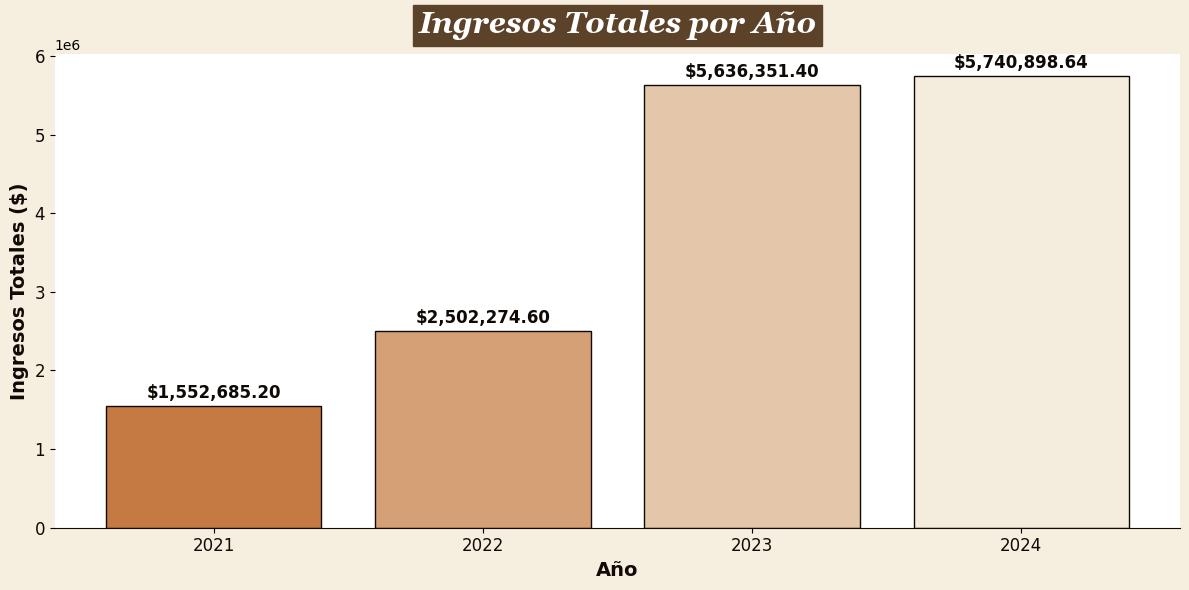

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos actualizados con el año 2024
ingresos_anuales = pd.DataFrame({
    'año': ['2021', '2022', '2023', '2024'],
    'ingresos_totales_anual': [1552685.2, 2502274.6, 5636351.4, 5740898.64]
})

# Colores personalizados
fondo_color = "#f6efdf"          # Beige muy claro para el fondo
titulo_fondo_color = "#5c4228"  # Marrón oscuro para el fondo del título
titulo_texto_color = "#ffffff"  # Texto del título en blanco
barra_color_inicial = "#c57a43"  # Marrón para el inicio del degradado
barra_color_final = "#f4eddd"   # Beige claro para el final del degradado
texto_color = "#0f0a05"         # Texto en marrón oscuro

# Configuración de estilo
plt.figure(figsize=(12, 6), facecolor=fondo_color)

# Crear el degradado para las barras
colors = sns.blend_palette([barra_color_inicial, barra_color_final], n_colors=len(ingresos_anuales))

# Crear el gráfico de barras
bar_plot = plt.bar(
    ingresos_anuales['año'], 
    ingresos_anuales['ingresos_totales_anual'], 
    color=colors,
    edgecolor=texto_color
)

# Personalizar el título
plt.title(
    'Ingresos Totales por Año', 
    fontsize=22, color=titulo_texto_color, 
    weight='bold', family='Georgia', style='italic',  # Cursiva parecida a Brush Script
    backgroundcolor=titulo_fondo_color, pad=15
)

# Ejes y etiquetas
plt.xlabel('Año', fontsize=14, color=texto_color, weight='bold')
plt.ylabel('Ingresos Totales ($)', fontsize=14, color=texto_color, weight='bold')
plt.xticks(fontsize=12, color=texto_color)
plt.yticks(fontsize=12, color=texto_color)
plt.gca().spines['top'].set_visible(False)  # Eliminar bordes superiores
plt.gca().spines['right'].set_visible(False)  # Eliminar bordes derechos
plt.gca().spines['left'].set_visible(False)  # Eliminar bordes izquierdos
plt.gca().spines['bottom'].set_color(texto_color)  # Mantener borde inferior visible

# Eliminar la cuadrícula
plt.grid(False)

# Añadir valores encima de las barras
for bar, value in zip(bar_plot, ingresos_anuales['ingresos_totales_anual']):
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() + 50000, 
        f"${value:,.2f}", 
        ha='center', va='bottom', fontsize=12, color=texto_color, weight='bold'
    )

# Ajustar el diseño
plt.tight_layout()

# Mostrar gráfico
plt.show()


### 19.1.2 Ingresos Brutos Totales por Año

**Descripción:**  
Muestra los ingresos **brutos** anuales, incluyendo ajustes de precios e impuestos, para reflejar la cifra global que ingresa antes de deducir costos.


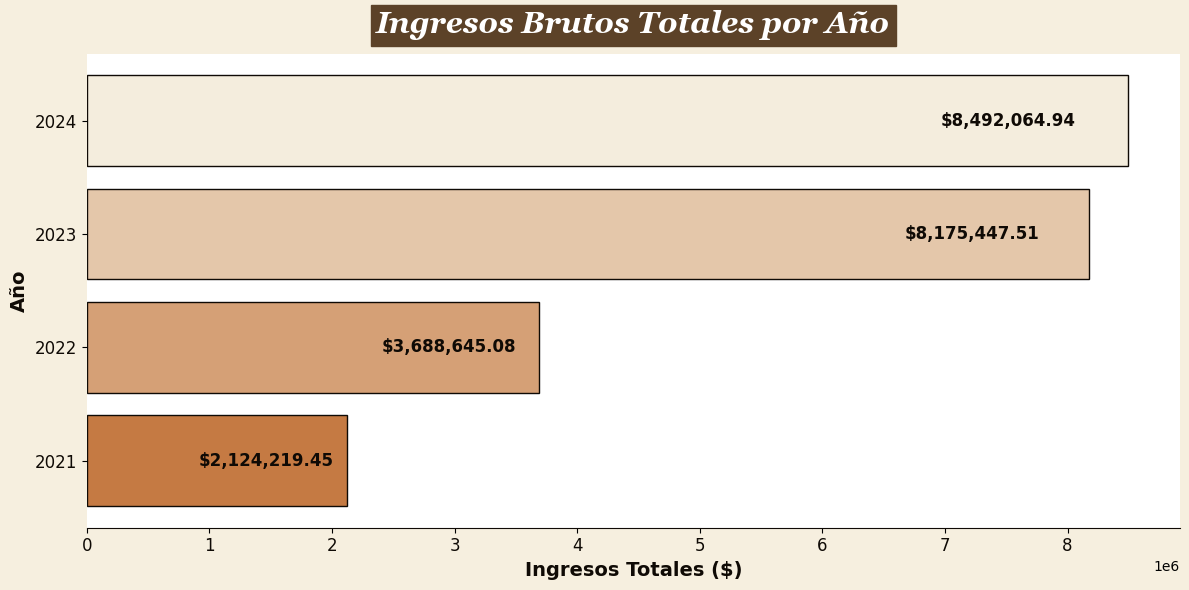

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos actualizados
ingresos_brutos = pd.DataFrame({
    'Año': ['2021', '2022', '2023', '2024'],
    'Ingresos Totales': [2124219.45, 3688645.08, 8175447.51, 8492064.94]
})

# Colores personalizados
fondo_color = "#f6efdf"          # Beige muy claro para el fondo
titulo_fondo_color = "#5c4228"  # Marrón oscuro para el fondo del título
titulo_texto_color = "#ffffff"  # Texto del título en blanco
barra_color_inicial = "#c57a43"  # Marrón oscuro para el inicio del degradado
barra_color_final = "#f4eddd"   # Beige claro para el final del degradado
texto_color = "#0f0a05"         # Texto en marrón oscuro

# Configuración de estilo
plt.figure(figsize=(12, 6), facecolor=fondo_color)

# Crear el degradado para las barras
colors = sns.blend_palette([barra_color_inicial, barra_color_final], n_colors=len(ingresos_brutos))

# Crear el gráfico de barras horizontales
bar_plot = plt.barh(
    ingresos_brutos['Año'], 
    ingresos_brutos['Ingresos Totales'], 
    color=colors,
    edgecolor=texto_color
)

# Personalizar el título
plt.title(
    'Ingresos Brutos Totales por Año', 
    fontsize=22, color=titulo_texto_color, 
    weight='bold', family='Georgia', style='italic',
    backgroundcolor=titulo_fondo_color, pad=15
)

# Ejes y etiquetas
plt.xlabel('Ingresos Totales ($)', fontsize=14, color=texto_color, weight='bold')
plt.ylabel('Año', fontsize=14, color=texto_color, weight='bold')
plt.xticks(fontsize=12, color=texto_color)
plt.yticks(fontsize=12, color=texto_color)
plt.gca().spines['top'].set_visible(False)  # Eliminar bordes superiores
plt.gca().spines['right'].set_visible(False)  # Eliminar bordes derechos
plt.gca().spines['left'].set_visible(False)  # Eliminar bordes izquierdos
plt.gca().spines['bottom'].set_color(texto_color)  # Mantener borde inferior visible

# Añadir valores al final de las barras
for bar, value in zip(bar_plot, ingresos_brutos['Ingresos Totales']):
    plt.text(
        bar.get_width() - (bar.get_width() * 0.05),  # Posición ajustada
        bar.get_y() + bar.get_height() / 2, 
        f"${value:,.2f}", 
        ha='right', va='center', fontsize=12, color=texto_color, weight='bold'
    )

# Ajustar el diseño
plt.tight_layout()

# Mostrar gráfico
plt.show()

#### 19.1.3 Promedio de Ingresos de ventas

**Descripción:**  
Representa el **promedio** de ingresos que cada venta genera, para 2024.




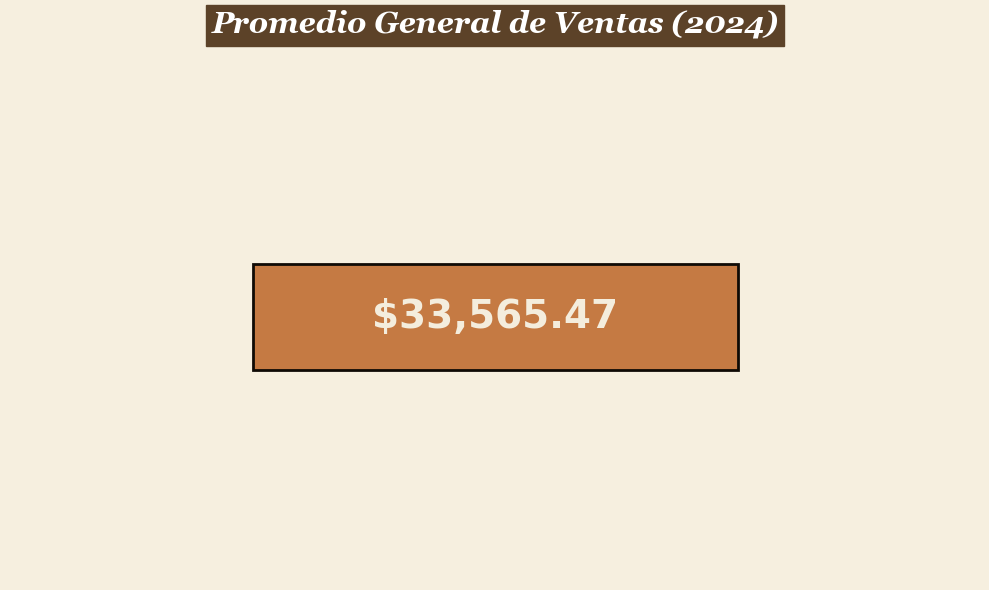

In [19]:
import matplotlib.pyplot as plt

# Promedio general (simulado)
promedio_general = 33565.47

# Estilo
fondo_color = "#f6efdf"
titulo_fondo_color = "#5c4228"
titulo_texto_color = "#ffffff"
texto_color = "#0f0a05"

# Crear figura
plt.figure(figsize=(10, 6), facecolor=fondo_color)

# Dibujar un rectángulo con el promedio
plt.gca().add_patch(plt.Rectangle((0.25, 0.4), 0.5, 0.2, color="#c57a43", ec=texto_color, lw=2))
plt.text(0.5, 0.5, f"${promedio_general:,.2f}", ha='center', va='center', fontsize=28, color="#f4eddd", weight='bold')

# Personalizar título
plt.title(
    'Promedio General de Ventas (2024)', 
    fontsize=22, color=titulo_texto_color, 
    weight='bold', family='Georgia', style='italic',  # Cursiva parecida a Brush Script
    backgroundcolor=titulo_fondo_color, pad=15
)

# Eliminar ejes y cuadrícula
plt.axis('off')

# Ajustar diseño
plt.tight_layout()
plt.show()


### 19.1.4 Ventas por Encima/Debajo del Promedio

**Descripción:**  
Compara el **promedio mensual** de ventas (enero-octubre 2024) con el **promedio general** (ticket global), 
mostrando meses que superan o no ese umbral.


C:\Users\Pilar\AppData\Local\Temp\ipykernel_7056\922480594.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


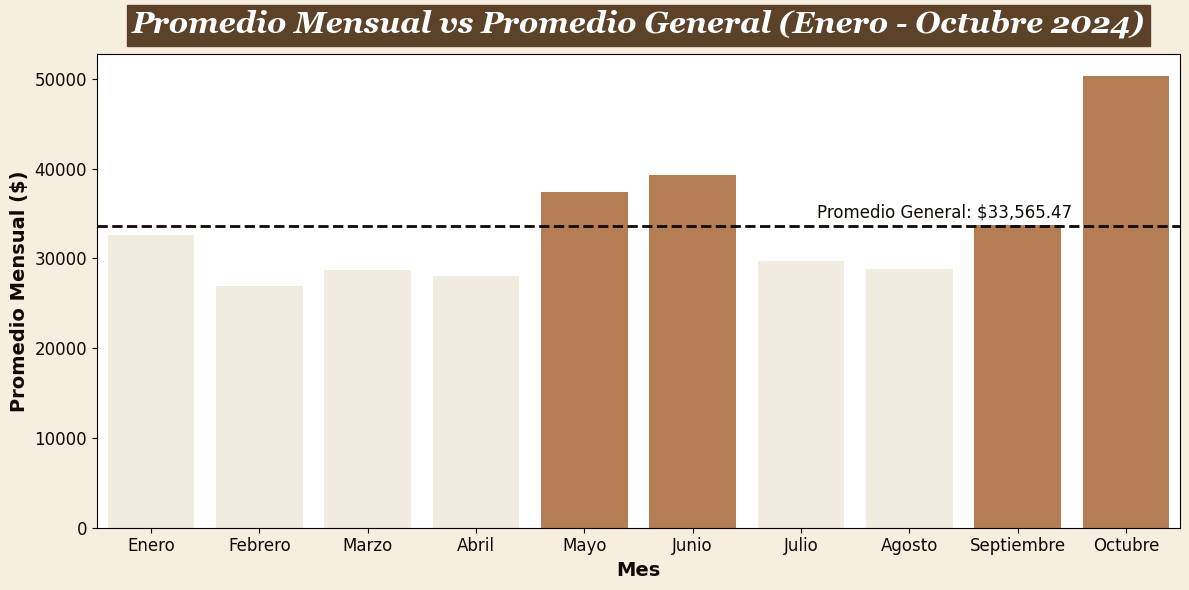

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Datos obtenidos
data_promedio_mes = pd.DataFrame({
    'mes': ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10'],
    'promedio_mensual': [
        32632.880476, 26904.544000, 28727.962632, 28092.313846,
        37377.928889, 39294.579565, 29736.002000, 28823.078095,
        33779.630000, 50289.734000
    ]
})

# Mapear números de meses a nombres
meses = {
    '01': 'Enero', '02': 'Febrero', '03': 'Marzo', '04': 'Abril',
    '05': 'Mayo', '06': 'Junio', '07': 'Julio', '08': 'Agosto',
    '09': 'Septiembre', '10': 'Octubre'
}
data_promedio_mes['Mes'] = data_promedio_mes['mes'].map(meses)

# Promedio general de las ventas
promedio_general = 33565.47

# Estilo
fondo_color = "#f6efdf"
titulo_fondo_color = "#5c4228"
titulo_texto_color = "#ffffff"
barra_color_encima = "#c57a43"
barra_color_debajo = "#f4eddd"
texto_color = "#0f0a05"

# Crear figura
plt.figure(figsize=(12, 6), facecolor=fondo_color)

# Gráfico de barras con colores dinámicos
sns.barplot(
    data=data_promedio_mes,
    x='Mes',
    y='promedio_mensual',
    palette=[barra_color_encima if x > promedio_general else barra_color_debajo for x in data_promedio_mes['promedio_mensual']]
)

# Agregar una línea del promedio general
plt.axhline(y=promedio_general, color=texto_color, linestyle='--', linewidth=2)
plt.text(8.5, promedio_general + 1000, f"Promedio General: ${promedio_general:,.2f}", color=texto_color, fontsize=12, ha='right')

# Personalizar título
plt.title(
    'Promedio Mensual vs Promedio General (Enero - Octubre 2024)',
   fontsize=22, color=titulo_texto_color, 
    weight='bold', family='Georgia', style='italic', 
    backgroundcolor=titulo_fondo_color, pad=15
)

# Etiquetas de los ejes
plt.xlabel('Mes', fontsize=14, color=texto_color, weight='bold')
plt.ylabel('Promedio Mensual ($)', fontsize=14, color=texto_color, weight='bold')
plt.xticks(fontsize=12, color=texto_color)
plt.yticks(fontsize=12, color=texto_color)

# Ajustar diseño
plt.tight_layout()
plt.show()


### 19.1.5 Cargo de Impuesto Mensual

**Descripción:**  
Muestra el cargo impositivo mes a mes, con valores negativos que indican la salida de dinero por impuestos en cada mes de 2024.


C:\Users\Pilar\AppData\Local\Temp\ipykernel_7056\4177332539.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(


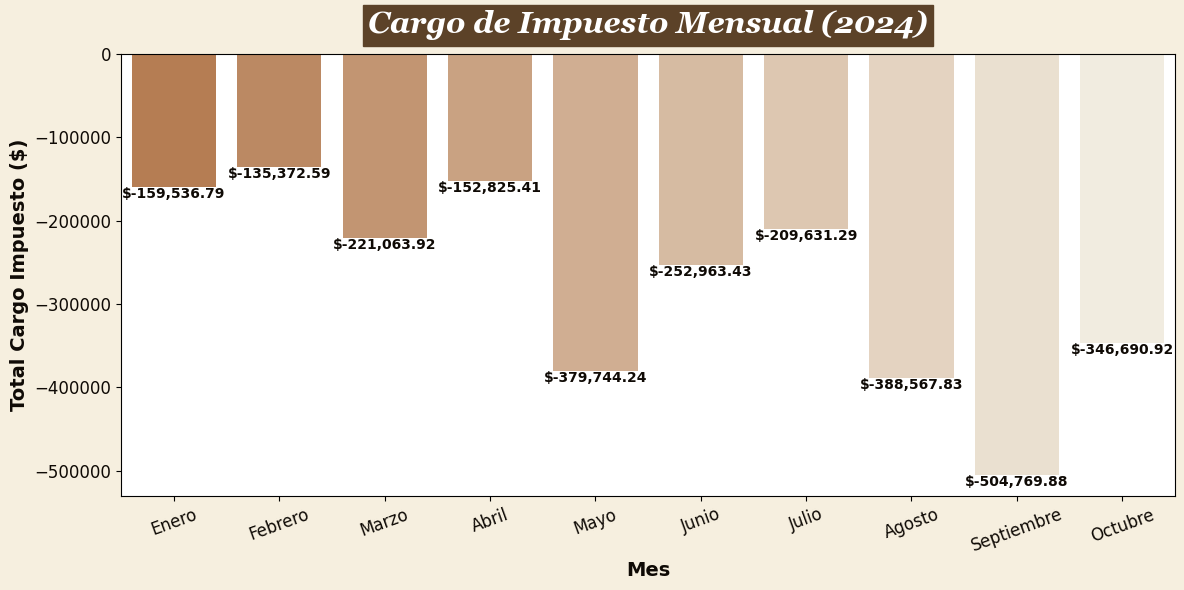

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos reales
cargo_impuesto_mensual = pd.DataFrame({
    'mes': ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10'],
    'total_cargo_impuesto': [
        -159536.79, -135372.59, -221063.92, -152825.41, 
        -379744.24, -252963.43, -209631.29, -388567.83,
        -504769.88, -346690.92
    ]
})

# Mapear números de meses a nombres
meses = {
    '01': 'Enero', '02': 'Febrero', '03': 'Marzo', '04': 'Abril',
    '05': 'Mayo', '06': 'Junio', '07': 'Julio', '08': 'Agosto',
    '09': 'Septiembre', '10': 'Octubre'
}
cargo_impuesto_mensual['Mes'] = cargo_impuesto_mensual['mes'].map(meses)

# Estilo
fondo_color = "#f6efdf"          # Beige muy claro para el fondo
titulo_fondo_color = "#5c4228"  # Marrón oscuro para el fondo del título
titulo_texto_color = "#ffffff"  # Texto del título en blanco
barra_color_inicial = "#c57a43"  # Marrón para el inicio del degradado
barra_color_final = "#f4eddd"   # Beige claro para el final del degradado
texto_color = "#0f0a05"         # Texto en marrón oscuro

# Crear figura
plt.figure(figsize=(12, 6), facecolor=fondo_color)

# Crear barras con degradado
colors = sns.blend_palette([barra_color_inicial, barra_color_final], n_colors=len(cargo_impuesto_mensual))
bar_plot = sns.barplot(
    data=cargo_impuesto_mensual,
    x='Mes',
    y='total_cargo_impuesto',
    palette=colors
)

# Agregar valores encima de las barras
for bar, value in zip(bar_plot.patches, cargo_impuesto_mensual['total_cargo_impuesto']):
    bar_plot.annotate(
        f"${value:,.2f}",
        (bar.get_x() + bar.get_width() / 2, value),
        ha='center',
        va='bottom' if value > 0 else 'top',
        fontsize=10,
        color=texto_color,
        weight='bold'
    )

# Personalizar el título con el estilo de "Ingresos Totales por Año"
plt.title(
    'Cargo de Impuesto Mensual (2024)', 
    fontsize=22, color=titulo_texto_color, 
    weight='bold', family='Georgia', style='italic',  # Cursiva parecida a Brush Script
    backgroundcolor=titulo_fondo_color, pad=15
)

# Etiquetas de ejes
plt.xlabel('Mes', fontsize=14, color=texto_color, weight='bold')
plt.ylabel('Total Cargo Impuesto ($)', fontsize=14, color=texto_color, weight='bold')
plt.xticks(fontsize=12, color=texto_color, rotation=20)  # Rotación para mejor separación
plt.yticks(fontsize=12, color=texto_color)

# Ajustar diseño
plt.tight_layout()
plt.show()



### 19.1.6 Cantidad Anual de Ventas

**Descripción:**  
Indica cuántas ventas se registraron por año (2021 - 2024), reflejando la evolución de la demanda.



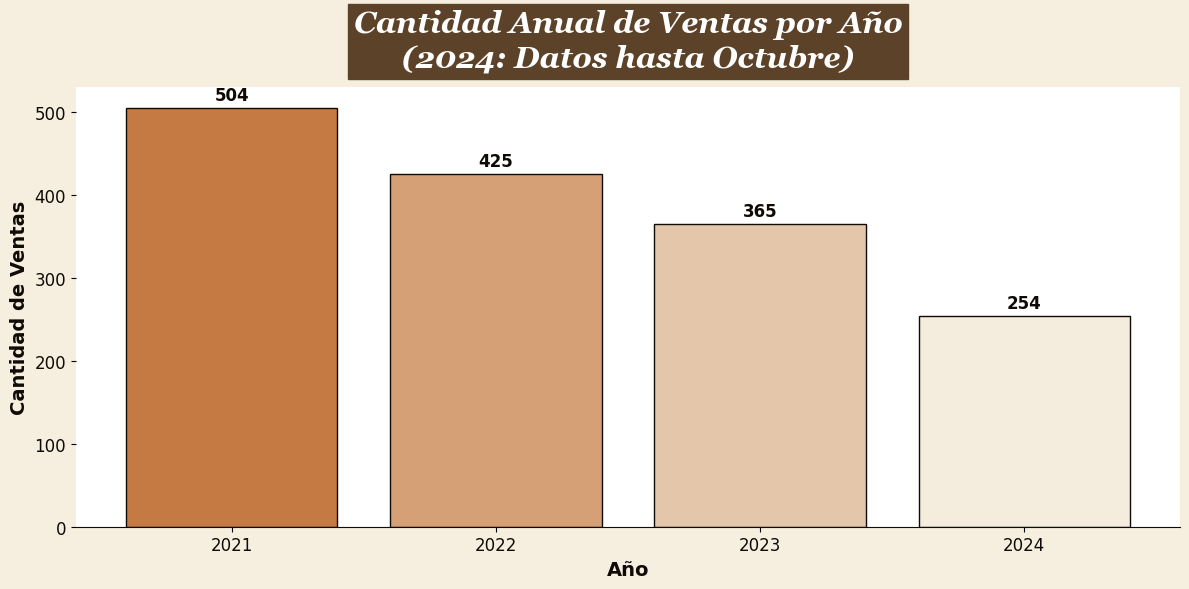

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos actualizados
ventas_anuales = pd.DataFrame({
    'Año': ['2021', '2022', '2023', '2024'],
    'Cantidad de Ventas': [504, 425, 365, 254]
})

# Colores personalizados
fondo_color = "#f6efdf"          # Beige muy claro para el fondo
titulo_fondo_color = "#5c4228"  # Marrón oscuro para el fondo del título
titulo_texto_color = "#ffffff"  # Texto del título en blanco
barra_color_inicial = "#c57a43"  # Marrón oscuro para el inicio del degradado
barra_color_final = "#f4eddd"   # Beige claro para el final del degradado
texto_color = "#0f0a05"         # Texto en marrón oscuro

# Configuración de estilo
plt.figure(figsize=(12, 6), facecolor=fondo_color)

# Crear el degradado para las barras
colors = sns.blend_palette([barra_color_inicial, barra_color_final], n_colors=len(ventas_anuales))

# Crear el gráfico de barras
bar_plot = plt.bar(
    ventas_anuales['Año'], 
    ventas_anuales['Cantidad de Ventas'], 
    color=colors,
    edgecolor=texto_color
)

# Añadir valores encima de las barras
for bar, value in zip(bar_plot, ventas_anuales['Cantidad de Ventas']):
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() + 5, 
        f"{value}", 
        ha='center', va='bottom', fontsize=12, color=texto_color, weight='bold'
    )

# Personalizar el título (se aclara lo de 2024)
plt.title(
    'Cantidad Anual de Ventas por Año\n(2024: Datos hasta Octubre)', 
    fontsize=22, color=titulo_texto_color, 
    weight='bold', family='Georgia', style='italic',
    backgroundcolor=titulo_fondo_color, pad=15
)

# Etiquetas de ejes
plt.xlabel('Año', fontsize=14, color=texto_color, weight='bold')
plt.ylabel('Cantidad de Ventas', fontsize=14, color=texto_color, weight='bold')
plt.xticks(fontsize=12, color=texto_color)
plt.yticks(fontsize=12, color=texto_color)

# Quitar bordes innecesarios
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_color(texto_color)

# Ajustar diseño
plt.tight_layout()
plt.show()


### 19.1.7 Ventas por Mes

**Descripción:**  
Divide la información de ventas en 2024 por mes, mostrando **número de transacciones** y **total en pesos** lado a lado.


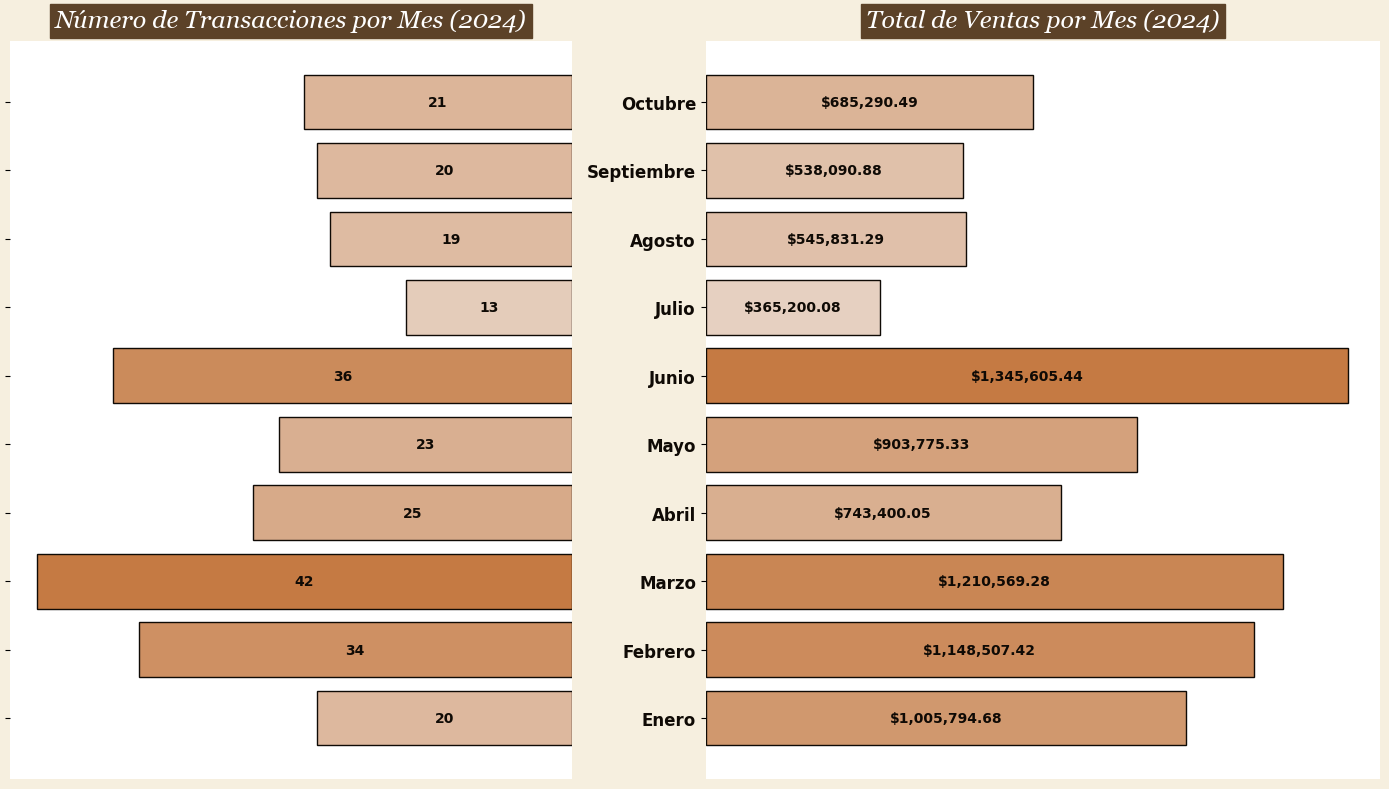

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Datos
ventas_por_mes_año = pd.DataFrame({
    'mes': ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 
            'Julio', 'Agosto', 'Septiembre', 'Octubre'],
    'numero_transacciones': [20, 34, 42, 25, 23, 36, 13, 19, 20, 21],
    'total_ventas': [1005794.68, 1148507.42, 1210569.28, 743400.05, 903775.33, 
                     1345605.44, 365200.08, 545831.29, 538090.88, 685290.49]
})

# Crear degradado único
palette = sns.light_palette("#c57a43", as_cmap=True)

# Normalizar valores
ventas_por_mes_año['color_intensidad'] = ventas_por_mes_año['numero_transacciones'] / ventas_por_mes_año['numero_transacciones'].max()
ventas_por_mes_año['color_total'] = ventas_por_mes_año['total_ventas'] / ventas_por_mes_año['total_ventas'].max()

# Configurar la figura
fig, axes = plt.subplots(1, 2, figsize=(14, 8), facecolor="#f6efdf", gridspec_kw={'width_ratios': [1, 1.2]})

# -------------------------------
# Gráfico izquierdo: Cantidad de Ventas (barras negativas)
# -------------------------------
for i, row in ventas_por_mes_año.iterrows():
    color = palette(row['color_intensidad'])  # Aplicar el degradado
    axes[0].barh(i, -row['numero_transacciones'], color=color, edgecolor="#0f0a05")
    axes[0].text(-row['numero_transacciones'] / 2, i, f"{row['numero_transacciones']}", 
                 ha='center', va='center', color="#0f0a05", weight='bold')

axes[0].set_title(
    "Número de Transacciones por Mes (2024)", 
    fontsize=18, color="#ffffff", family="Georgia", style="italic",
    backgroundcolor="#5c4228", pad=10
)
axes[0].set_yticks(range(len(ventas_por_mes_año)))
axes[0].set_yticklabels([''] * len(ventas_por_mes_año))  # Eliminar nombres duplicados
axes[0].set_xticks([])

# -------------------------------
# Gráfico derecho: Total de Ventas
# -------------------------------
for i, row in ventas_por_mes_año.iterrows():
    color = palette(row['color_total'])  # Aplicar el degradado
    axes[1].barh(i, row['total_ventas'], color=color, edgecolor="#0f0a05")
    axes[1].text(row['total_ventas'] / 2, i, f"${row['total_ventas']:,.2f}", 
                 ha='center', va='center', color="#0f0a05", weight='bold')

axes[1].set_title(
    "Total de Ventas por Mes (2024)", 
    fontsize=18, color="#ffffff", family="Georgia", style="italic",
    backgroundcolor="#5c4228", pad=10
)
axes[1].set_yticks(range(len(ventas_por_mes_año)))
axes[1].set_yticklabels(ventas_por_mes_año['mes'], fontsize=12, color="#0f0a05", weight='bold')
axes[1].set_xticks([])

# Configuración general
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

# Ajustar diseño
plt.tight_layout()
plt.show()


### 19.1.8 Ventas por Día de la Semana

**Descripción:**  
Presenta la cantidad y el total de ventas para cada día de la semana en 2024, 
permitiendo ver qué días concentran más transacciones y mayores ingresos.


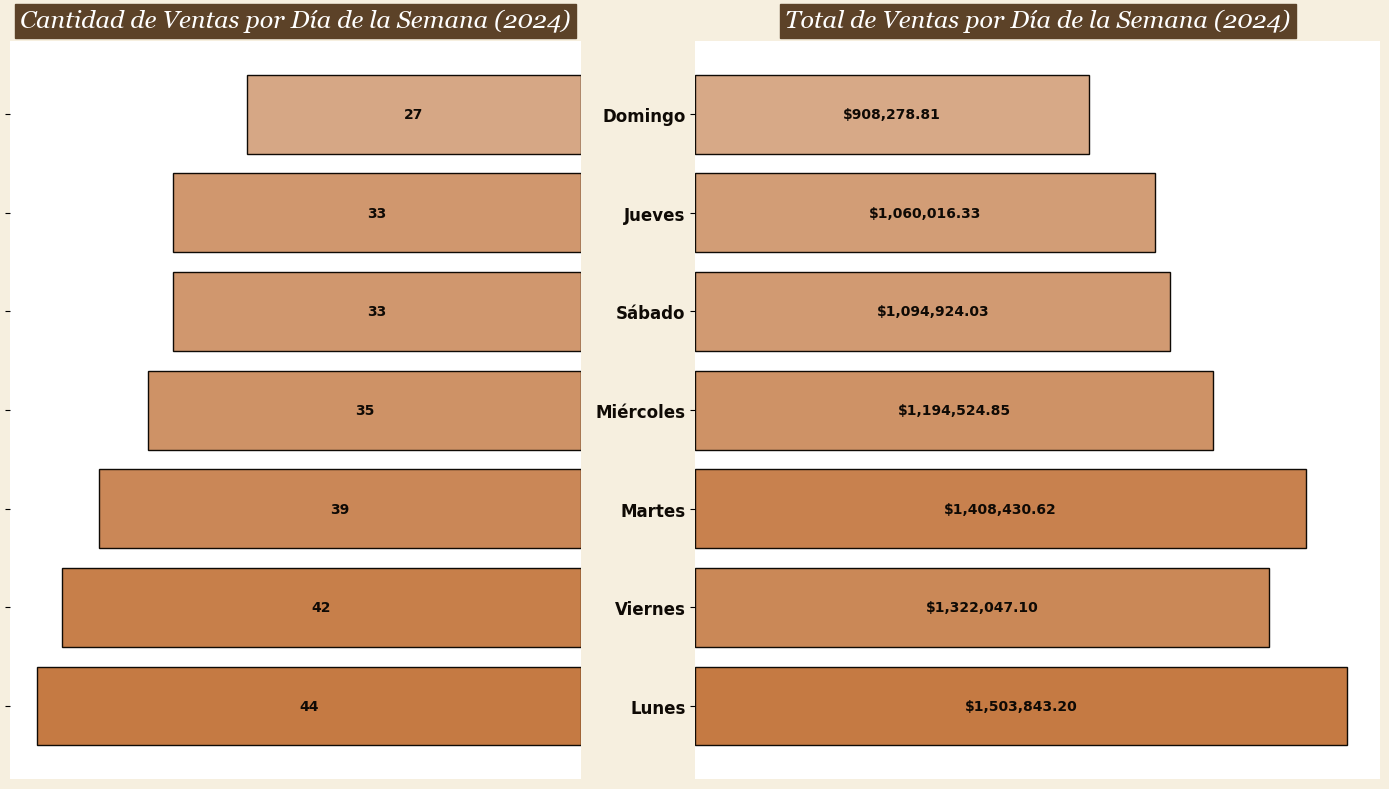

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Datos reales de la consulta SQL
ventas_por_dia_semana = pd.DataFrame({
    'dia_semana': ['Lunes', 'Viernes', 'Martes', 'Miércoles', 'Sábado', 'Jueves', 'Domingo'],
    'numero_ventas': [44, 42, 39, 35, 33, 33, 27],
    'total_ventas': [1503843.20, 1322047.10, 1408430.62, 1194524.85, 1094924.03, 1060016.33, 908278.81]
})

# Configurar degradado único
palette = sns.light_palette("#c57a43", as_cmap=True)

# Normalizar valores para intensidad del degradado
ventas_por_dia_semana['color_cantidad'] = ventas_por_dia_semana['numero_ventas'] / ventas_por_dia_semana['numero_ventas'].max()
ventas_por_dia_semana['color_total'] = ventas_por_dia_semana['total_ventas'] / ventas_por_dia_semana['total_ventas'].max()

# Configurar la figura
fig, axes = plt.subplots(1, 2, figsize=(14, 8), facecolor="#f6efdf", gridspec_kw={'width_ratios': [1, 1.2]})

# -------------------------------
# Gráfico izquierdo: Cantidad de Ventas
# -------------------------------
for i, row in ventas_por_dia_semana.iterrows():
    color = palette(row['color_cantidad'])
    axes[0].barh(row['dia_semana'], -row['numero_ventas'], color=color, edgecolor="#0f0a05")
    axes[0].text(-row['numero_ventas'] / 2, i, f"{row['numero_ventas']}", ha='center', va='center', color="#0f0a05", weight='bold')

axes[0].set_title(
    "Cantidad de Ventas por Día de la Semana (2024)", 
    fontsize=18, color="#ffffff", family="Georgia", style="italic",
    backgroundcolor="#5c4228", pad=10
)
axes[0].set_yticks(range(len(ventas_por_dia_semana)))
axes[0].set_yticklabels([''] * len(ventas_por_dia_semana))
axes[0].set_xticks([])

# -------------------------------
# Gráfico derecho: Total de Ventas
# -------------------------------
for i, row in ventas_por_dia_semana.iterrows():
    color = palette(row['color_total'])
    axes[1].barh(row['dia_semana'], row['total_ventas'], color=color, edgecolor="#0f0a05")
    axes[1].text(row['total_ventas'] / 2, i, f"${row['total_ventas']:,.2f}", ha='center', va='center', color="#0f0a05", weight='bold')

axes[1].set_title(
    "Total de Ventas por Día de la Semana (2024)", 
    fontsize=18, color="#ffffff", family="Georgia", style="italic",
    backgroundcolor="#5c4228", pad=10
)
axes[1].set_yticks(range(len(ventas_por_dia_semana)))
axes[1].set_yticklabels(ventas_por_dia_semana['dia_semana'], fontsize=12, color="#0f0a05", weight='bold')
axes[1].set_xticks([])

# Configuración general
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

# Ajustar diseño
plt.tight_layout()
plt.show()


### 19.1.9 Horas Pico de Venta

**Descripción:**  
Grafica la cantidad de ventas por hora (0-23 hs) para evidenciar en qué momentos del día se concentra el mayor número de transacciones.


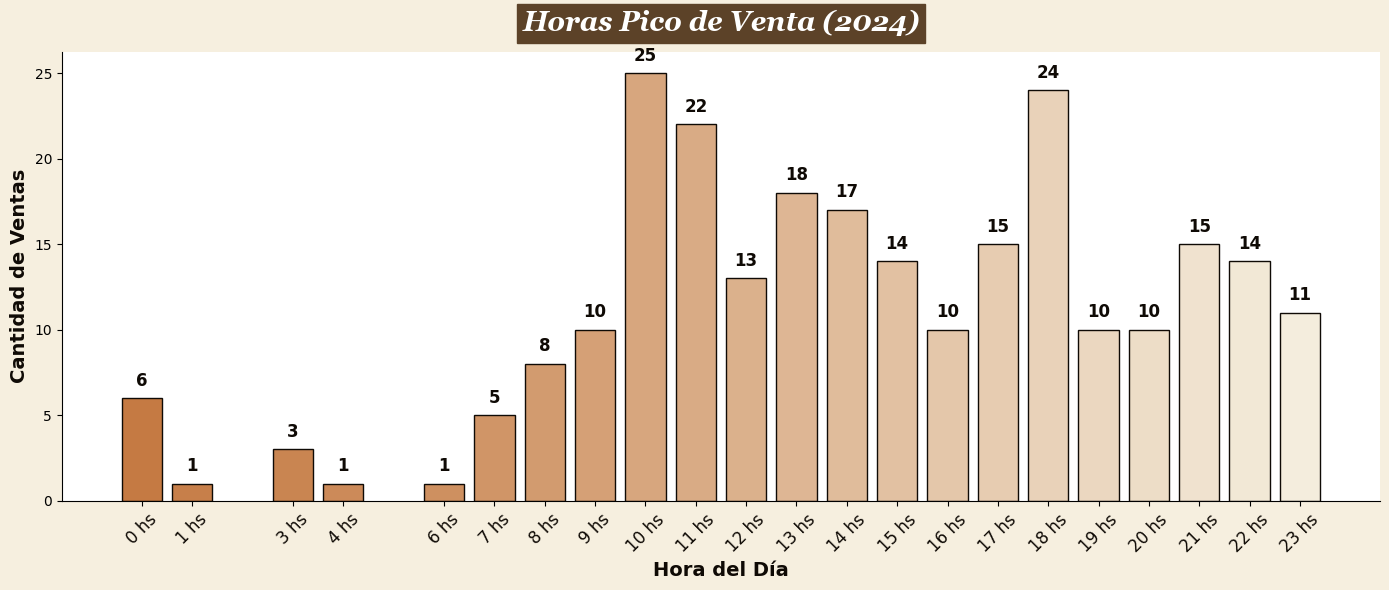

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos reales de la consulta SQL
horas_pico_venta = pd.DataFrame({
    'hora': ['00', '01', '03', '04', '06', '07', '08', '09', '10', '11', 
             '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', 
             '22', '23'],
    'cantidad_ventas': [6, 1, 3, 1, 1, 5, 8, 10, 25, 22, 13, 18, 17, 14, 
                        10, 15, 24, 10, 10, 15, 14, 11]
})

# Ordenar por hora para asegurar el flujo correcto
horas_pico_venta['hora'] = horas_pico_venta['hora'].astype(int)
horas_pico_venta = horas_pico_venta.sort_values(by='hora')

# Configurar degradado de colores
fondo_color = "#f6efdf"          # Fondo beige claro
titulo_fondo_color = "#5c4228"  # Fondo marrón oscuro del título
titulo_texto_color = "#ffffff"  # Texto blanco en el título
barra_color_inicial = "#c57a43"  # Marrón inicial
barra_color_final = "#f4eddd"   # Beige final
texto_color = "#0f0a05"         # Texto marrón oscuro

# Crear degradado para las barras
colors = sns.blend_palette([barra_color_inicial, barra_color_final], n_colors=len(horas_pico_venta))

# Configurar la figura
plt.figure(figsize=(14, 6), facecolor=fondo_color)

# Crear gráfico de barras
bar_plot = plt.bar(
    horas_pico_venta['hora'], 
    horas_pico_venta['cantidad_ventas'], 
    color=colors, 
    edgecolor=texto_color
)

# Título estilizado
plt.title(
    'Horas Pico de Venta (2024)', 
    fontsize=20, color=titulo_texto_color, 
    weight='bold', family='Georgia', style='italic',
    backgroundcolor=titulo_fondo_color, pad=15
)

# Etiquetas del eje X con "hs"
plt.xticks(horas_pico_venta['hora'], [f"{h} hs" for h in horas_pico_venta['hora']], 
           fontsize=12, color=texto_color, rotation=45)

# Etiquetas del eje Y
plt.ylabel('Cantidad de Ventas', fontsize=14, color=texto_color, weight='bold')
plt.xlabel('Hora del Día', fontsize=14, color=texto_color, weight='bold')

# Añadir valores encima de las barras
for bar, value in zip(bar_plot, horas_pico_venta['cantidad_ventas']):
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() + 0.5, 
        f"{value}", 
        ha='center', va='bottom', fontsize=12, color=texto_color, weight='bold'
    )

# Eliminar bordes superiores y derechos
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Ajustar diseño
plt.tight_layout()
plt.show()



## 20. Visualizaciones - Tabla `publicacion`

Esta sección agrupa todas las **visualizaciones** relacionadas con la tabla `publicacion`.

### Índice de Visualizaciones

1. **20.1 Calzados Más Vendidos**  
2. **20.2 Conteo de Publicaciones por Tipo de Producto**  
3. **20.3 Ingresos Totales por Tipo de Producto**  
4. **20.4 Distribución de Colores en Productos**  
5. **20.5 Ingresos Totales por Color de Producto**  
6. **20.6 Top 10 Productos Más Vendidos (Por Título)**  
7. **20.7 Top 10 Productos Más Vendidos Excluyendo Calzados**  
8. **20.8 Top 10 Productos con Mayor Ingreso**

**Metodología de Visualización**  
En cada subapartado (20.x) se mostrará:  
- **Título y Descripción** de la gráfica.  
- **Código** (o referencia a la imagen) que genera la visualización (usando `matplotlib`, `seaborn`, etc.).  
- (Opcional) **Interpretación** breve sobre la gráfica.

A continuación, se presentan las visualizaciones de **Publicaciones** en el **orden establecido**.


### 20.1 Calzados Más Vendidos

**Descripción:**  
Muestra los 10 calzados de tipo sandalia con mayores ingresos, permitiendo identificar los productos más exitosos en ventas.


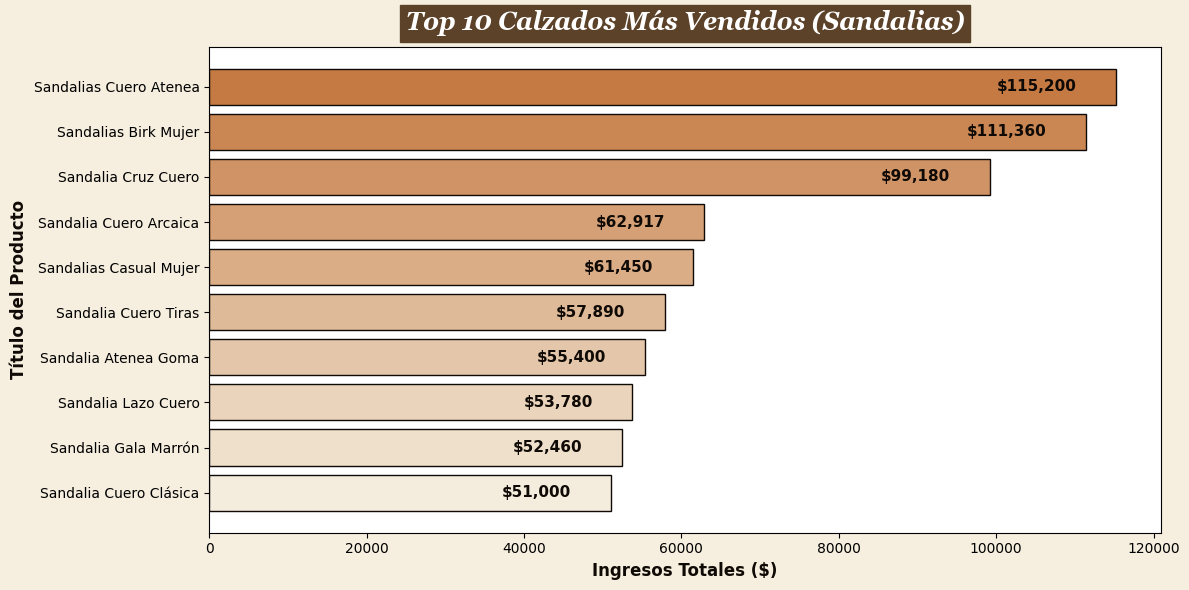

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos simulados de la consulta SQL
calzados_mas_vendidos = pd.DataFrame({
    'titulo_publicacion': [
        'Sandalias Cuero Atenea', 'Sandalias Birk Mujer', 'Sandalia Cruz Cuero', 
        'Sandalia Cuero Arcaica', 'Sandalias Casual Mujer', 'Sandalia Cuero Tiras', 
        'Sandalia Atenea Goma', 'Sandalia Lazo Cuero', 'Sandalia Gala Marrón', 'Sandalia Cuero Clásica'
    ],
    'ingresos_productos': [115200, 111360, 99180, 62917, 61450, 57890, 55400, 53780, 52460, 51000]
})

# Configuración de colores y estilo
fondo_color = "#f6efdf"
titulo_fondo_color = "#5c4228"
titulo_texto_color = "#ffffff"
barra_color_inicial = "#c57a43"
barra_color_final = "#f4eddd"
texto_color = "#0f0a05"

# Degradado de colores
colors = sns.blend_palette([barra_color_inicial, barra_color_final], n_colors=len(calzados_mas_vendidos))

# Configuración de la figura
plt.figure(figsize=(12, 6), facecolor=fondo_color)
bar_plot = plt.barh(
    calzados_mas_vendidos['titulo_publicacion'], 
    calzados_mas_vendidos['ingresos_productos'], 
    color=colors, edgecolor=texto_color
)

# Estilizado del título
plt.title(
    "Top 10 Calzados Más Vendidos (Sandalias)", 
    fontsize=18, color=titulo_texto_color, weight='bold', family='Georgia', 
    style='italic', backgroundcolor=titulo_fondo_color, pad=12
)

# Etiquetas del eje X e Y
plt.xlabel("Ingresos Totales ($)", fontsize=12, color=texto_color, weight='bold')
plt.ylabel("Título del Producto", fontsize=12, color=texto_color, weight='bold')

# Mostrar valores en las barras
for bar, value in zip(bar_plot, calzados_mas_vendidos['ingresos_productos']):
    plt.text(
        bar.get_width() - 5000, bar.get_y() + bar.get_height() / 2, 
        f"${value:,}", ha='right', va='center', fontsize=11, color=texto_color, weight='bold'
    )

# Ajustes de diseño
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()




### 20.2 Conteo de Publicaciones por Tipo de Producto

**Descripción:**  
Esta visualización muestra la cantidad de publicaciones agrupadas por tipo de producto, 
identificando las categorías con mayor oferta.




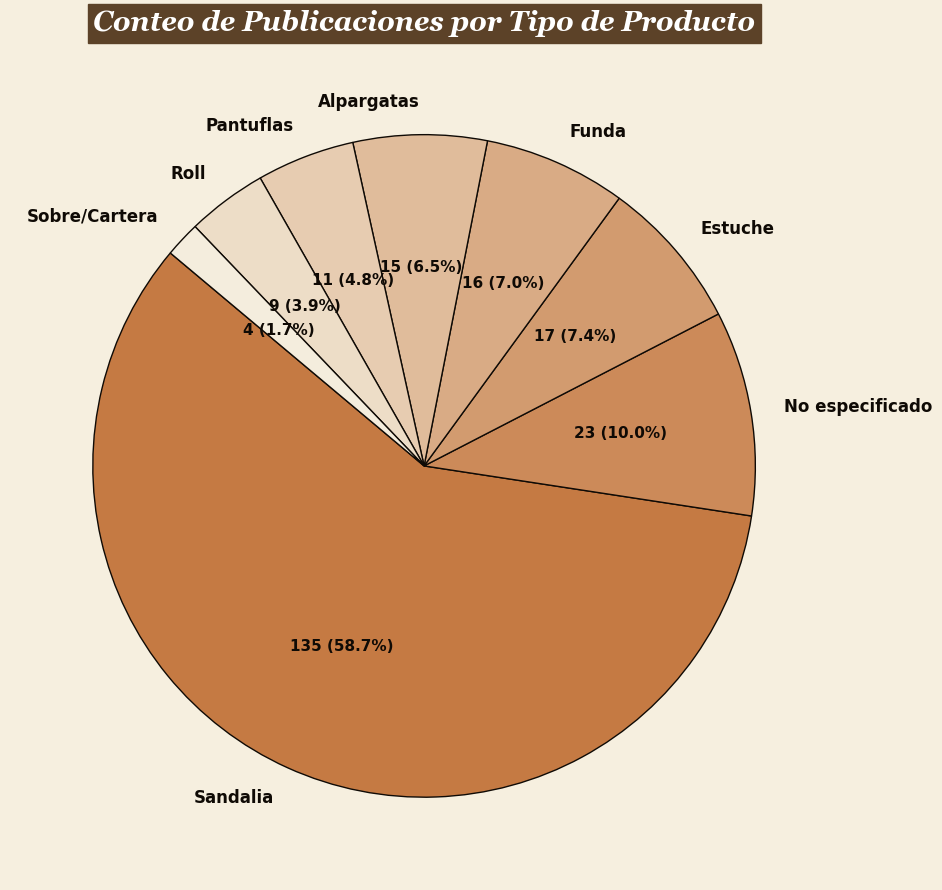

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos reales de la consulta SQL con "Sobre" y "Cartera" combinados
conteo_por_tipo = pd.DataFrame({
    'tipo_producto': ['Sandalia', 'No especificado', 'Estuche', 'Funda', 'Alpargatas', 
                      'Pantuflas', 'Roll', 'Sobre/Cartera'],
    'cantidad': [135, 23, 17, 16, 15, 11, 9, 4]  # Se sumaron 2 + 2 = 4 para Sobre/Cartera
})

# Configurar degradado de colores
fondo_color = "#f6efdf"          # Fondo beige claro
titulo_fondo_color = "#5c4228"  # Fondo marrón oscuro del título
titulo_texto_color = "#ffffff"  # Texto blanco en el título
barra_color_inicial = "#c57a43"  # Marrón inicial
barra_color_final = "#f4eddd"   # Beige final
texto_color = "#0f0a05"         # Texto marrón oscuro

# Crear degradado de colores
colors = sns.blend_palette([barra_color_inicial, barra_color_final], n_colors=len(conteo_por_tipo))

# Configurar la figura con mayor tamaño
plt.figure(figsize=(12, 9), facecolor=fondo_color)

# Función para mostrar cantidad y porcentaje
def autopct_format(pct, all_values):
    total = sum(all_values)
    absolute = int(round(pct/100.*total))
    return f"{absolute} ({pct:.1f}%)"

# Crear gráfico circular con etiquetas ajustadas
wedges, texts, autotexts = plt.pie(
    conteo_por_tipo['cantidad'], 
    labels=conteo_por_tipo['tipo_producto'], 
    autopct=lambda pct: autopct_format(pct, conteo_por_tipo['cantidad']),
    startangle=140, 
    colors=colors, 
    wedgeprops={'edgecolor': texto_color}
)

# Ajustar estilo de etiquetas
for text in texts:
    text.set_fontsize(12)
    text.set_color(texto_color)
    text.set_weight('bold')

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_color(texto_color)
    autotext.set_weight('bold')

# Título estilizado
plt.title(
    'Conteo de Publicaciones por Tipo de Producto', 
    fontsize=20, color=titulo_texto_color, weight='bold',
    family='Georgia', style='italic', backgroundcolor=titulo_fondo_color, pad=15
)

# Ajustar layout para evitar superposición
plt.tight_layout()
plt.show()





### 20.3 Ingresos Totales por Tipo de Producto

**Descripción:**  
Presenta los ingresos totales generados por cada tipo de producto, para detectar las categorías más rentables.


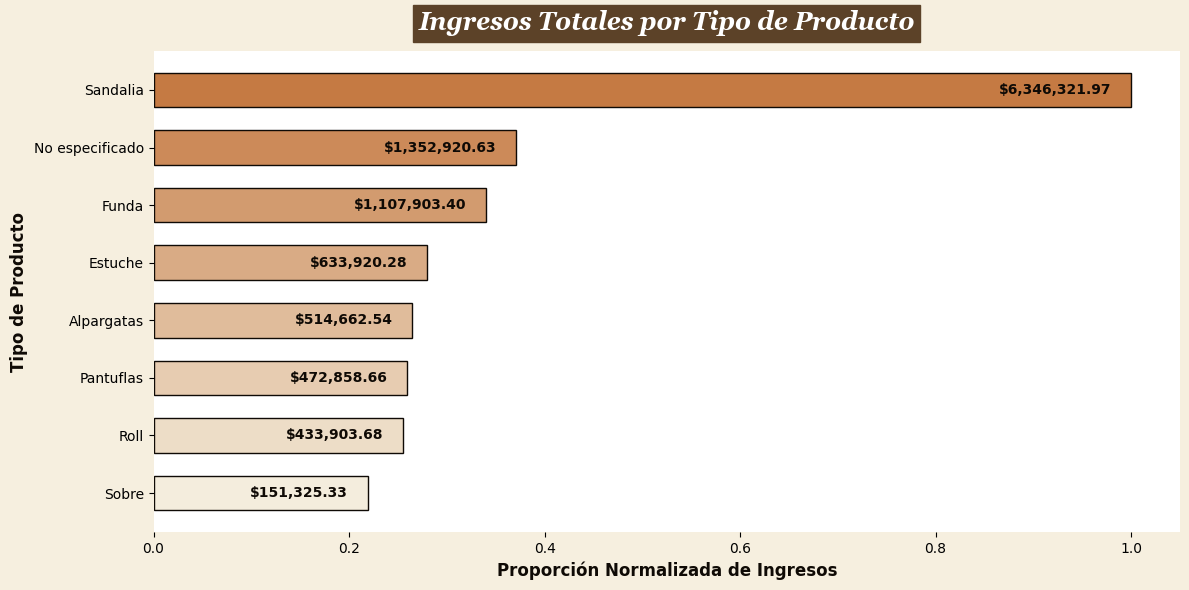

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos de la consulta SQL
ingresos_por_tipo = pd.DataFrame({
    'tipo_producto': ['Sandalia', 'No especificado', 'Funda', 'Estuche', 'Alpargatas', 'Pantuflas', 'Roll', 'Sobre'],
    'ingresos_totales': [6346321.97, 1352920.63, 1107903.40, 633920.28, 514662.54, 472858.66, 433903.68, 151325.33]
})

# Configurar degradado de colores
fondo_color = "#f6efdf"          # Fondo beige claro
titulo_fondo_color = "#5c4228"  # Fondo marrón oscuro del título
titulo_texto_color = "#ffffff"  # Texto blanco en el título
barra_color_inicial = "#c57a43"  # Marrón inicial
barra_color_final = "#f4eddd"   # Beige final
texto_color = "#0f0a05"         # Texto marrón oscuro

# Normalizar los valores para ajustar la proporción gradualmente
ingresos_por_tipo['proporcion'] = ingresos_por_tipo['ingresos_totales'] / max(ingresos_por_tipo['ingresos_totales']) * 0.8 + 0.2

# Crear degradado de colores
colors = sns.blend_palette([barra_color_inicial, barra_color_final], n_colors=len(ingresos_por_tipo))

# Configurar la figura
plt.figure(figsize=(12, 6), facecolor=fondo_color)

# Crear barras con ajuste proporcional
bar_plot = plt.barh(
    ingresos_por_tipo['tipo_producto'], 
    ingresos_por_tipo['proporcion'], 
    color=colors, 
    edgecolor=texto_color, 
    height=0.6
)

# Título estilizado
plt.title(
    'Ingresos Totales por Tipo de Producto', 
    fontsize=18, color=titulo_texto_color, 
    weight='bold', family='Georgia', style='italic',
    backgroundcolor=titulo_fondo_color, pad=15
)

# Etiquetas del eje Y
plt.ylabel('Tipo de Producto', fontsize=12, color=texto_color, weight='bold')
plt.xlabel('Proporción Normalizada de Ingresos', fontsize=12, color=texto_color, weight='bold')

# Agregar montos dentro de las barras
for bar, valor, monto in zip(bar_plot, ingresos_por_tipo['proporcion'], ingresos_por_tipo['ingresos_totales']):
    plt.text(
        bar.get_width() - 0.02, 
        bar.get_y() + bar.get_height() / 2, 
        f"${monto:,.2f}", 
        ha='right', va='center', fontsize=10, color=texto_color, weight='bold'
    )

# Ajustes finales
plt.gca().invert_yaxis()  # Invertir el eje Y para la barra más grande arriba
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.tight_layout()
plt.show()





### 20.4 Distribución de Colores en Productos

**Descripción:**  
Muestra cuántos productos hay de cada color, permitiendo ver la preferencia cromática en la oferta.


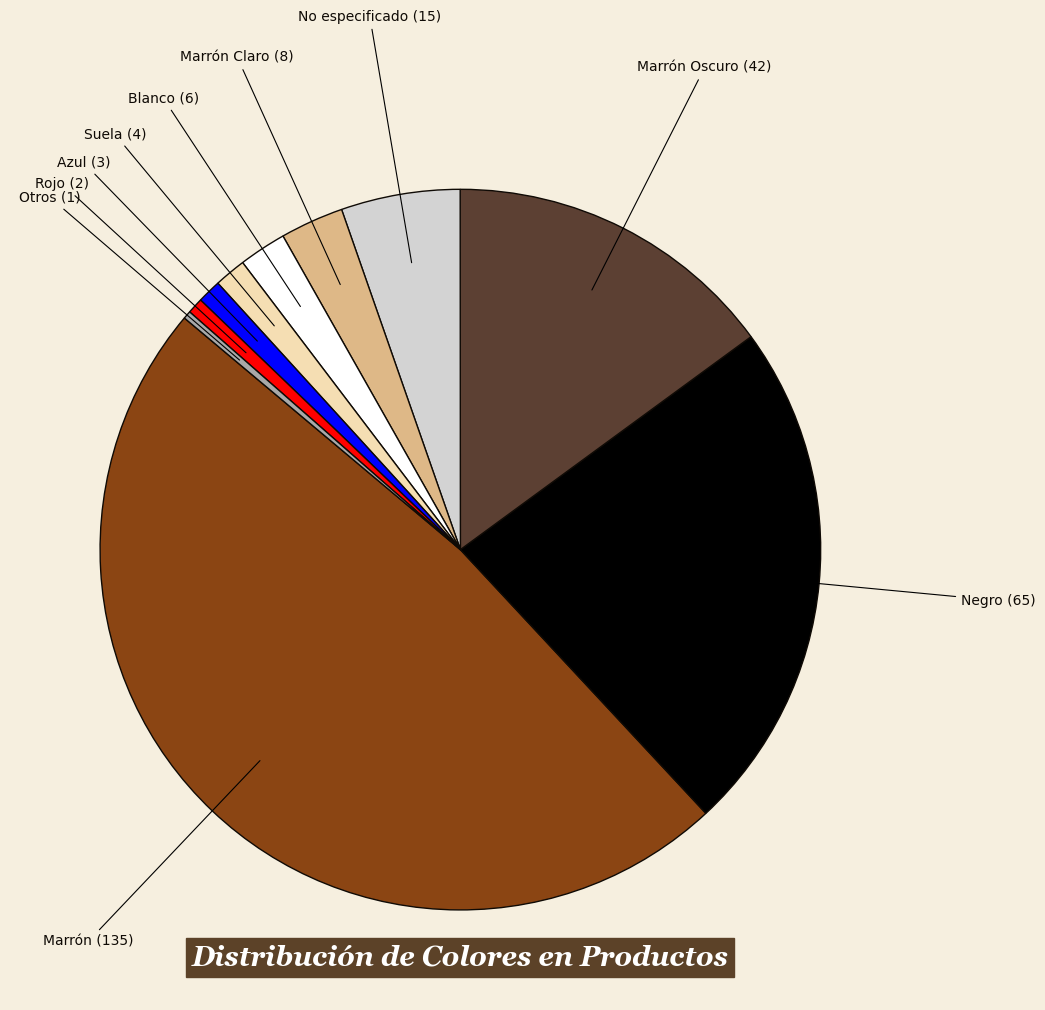

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Datos reales
conteo_por_tipo = pd.DataFrame({
    'color': ['Marrón', 'Negro', 'Marrón Oscuro', 'No especificado', 
              'Marrón Claro', 'Blanco', 'Suela', 'Azul', 'Rojo', 'Otros'],
    'cantidad': [135, 65, 42, 15, 8, 6, 4, 3, 2, 1]
})

# Configuración de colores
colores_por_color = ['#8B4513', '#000000', '#5C4033', '#D3D3D3', '#DEB887', 
                     '#FFFFFF', '#F5DEB3', '#0000FF', '#FF0000', '#A9A9A9']

# Configurar el tamaño del gráfico
plt.figure(figsize=(14, 10), facecolor="#f6efdf")

# Crear el gráfico circular
wedges, texts = plt.pie(
    conteo_por_tipo['cantidad'],
    startangle=140,
    colors=colores_por_color,
    wedgeprops={'edgecolor': "#0f0a05"}
)

# Añadir etiquetas fuera del gráfico con líneas guía mejoradas
for i, (wedge, label, value) in enumerate(zip(wedges, conteo_por_tipo['color'], conteo_por_tipo['cantidad'])):
    angle = (wedge.theta2 + wedge.theta1) / 2  # Ángulo central de cada porción
    x = 1.3 * np.cos(np.radians(angle))  # Coordenada X (separación aumentada)
    y = 1.3 * np.sin(np.radians(angle))  # Coordenada Y
    x_text = 1.5 * np.cos(np.radians(angle))  # Posición del texto más separada
    y_text = 1.5 * np.sin(np.radians(angle))

    # Dibujar una línea guía
    plt.annotate(
        f"{label} ({value})",  # Texto de la etiqueta con cantidad
        xy=(wedge.center[0] + np.cos(np.radians(angle)) * 0.8, wedge.center[1] + np.sin(np.radians(angle)) * 0.8),
        xytext=(x_text, y_text),
        ha='center', va='center', fontsize=10, color="#0f0a05",
        arrowprops=dict(facecolor='black', arrowstyle='-', lw=0.8)
    )

# Configurar título estilizado (movido al final)
plt.subplots_adjust(bottom=0.2)
plt.figtext(
    0.5, 0.05,  # Posición centrada debajo del gráfico
    'Distribución de Colores en Productos', 
    fontsize=20, color="#ffffff", weight='bold',
    family='Georgia', style='italic', backgroundcolor="#5c4228", ha='center'
)

# Ajustar diseño
plt.tight_layout()
plt.show()





### 20.5 Ingresos Totales por Color de Producto

**Descripción:**  
Suma los ingresos totales para cada color, permitiendo analizar qué colores generan mayor facturación.



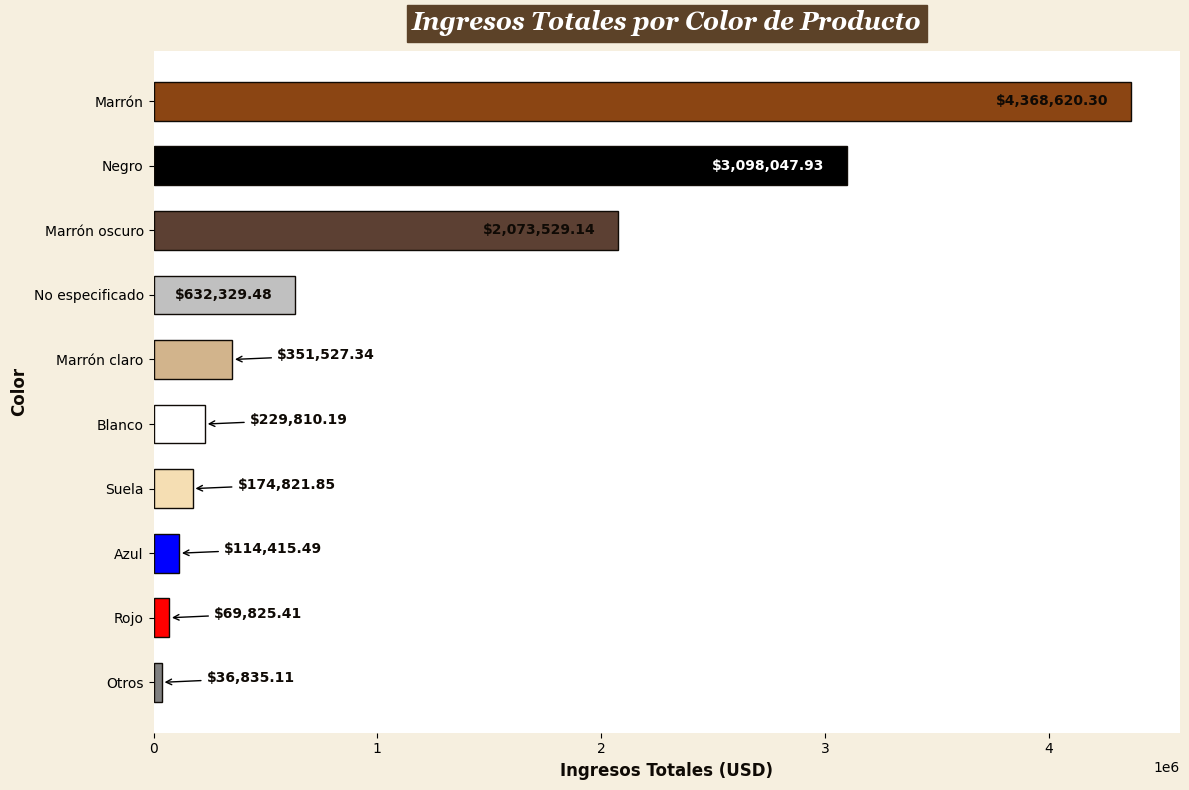

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos de la consulta SQL
ingresos_por_color = pd.DataFrame({
    'color': ['Marrón', 'Negro', 'Marrón oscuro', 'No especificado', 
              'Marrón claro', 'Blanco', 'Suela', 'Azul', 'Rojo', 'Otros'],
    'ingresos_totales': [4368620.30, 3098047.93, 2073529.14, 632329.48, 
                         351527.34, 229810.19, 174821.85, 114415.49, 69825.41, 36835.11]
})

# Configuración de colores específicos para las barras
colores_barras = {
    'Marrón': "#8B4513",
    'Negro': "#000000",
    'Marrón oscuro': "#5C4033",
    'No especificado': "#C0C0C0",
    'Marrón claro': "#D2B48C",
    'Blanco': "#FFFFFF",
    'Suela': "#F5DEB3",
    'Azul': "#0000FF",
    'Rojo': "#FF0000",
    'Otros': "#808080"
}
ingresos_por_color['color_barras'] = ingresos_por_color['color'].map(colores_barras)

# Configuración del gráfico
fondo_color = "#f6efdf"  # Fondo beige claro
titulo_fondo_color = "#5c4228"  # Fondo marrón oscuro del título
titulo_texto_color = "#ffffff"  # Texto blanco en el título
texto_color = "#0f0a05"  # Texto marrón oscuro

# Configuración de la figura
plt.figure(figsize=(12, 8), facecolor=fondo_color)

# Crear barras horizontales
bar_plot = plt.barh(
    ingresos_por_color['color'], 
    ingresos_por_color['ingresos_totales'], 
    color=ingresos_por_color['color_barras'], 
    edgecolor=texto_color, 
    height=0.6
)

# Título estilizado
plt.title(
    'Ingresos Totales por Color de Producto', 
    fontsize=18, color=titulo_texto_color, weight='bold',
    family='Georgia', style='italic', backgroundcolor=titulo_fondo_color, pad=15
)

# Etiquetas del eje Y
plt.ylabel('Color', fontsize=12, color=texto_color, weight='bold')
plt.xlabel('Ingresos Totales (USD)', fontsize=12, color=texto_color, weight='bold')

# Añadir montos dentro o fuera de las barras con flechas si es necesario
for bar, monto in zip(bar_plot, ingresos_por_color['ingresos_totales']):
    if bar.get_width() > 500000:  # Si la barra es suficientemente grande
        plt.text(
            bar.get_width() - 100000, 
            bar.get_y() + bar.get_height() / 2, 
            f"${monto:,.2f}", 
            ha='right', va='center', fontsize=10, color="#FFFFFF" if bar.get_facecolor() == (0.0, 0.0, 0.0, 1.0) else texto_color,
            weight='bold'
        )
    else:  # Si la barra es pequeña, usa una flecha
        plt.annotate(
            f"${monto:,.2f}", 
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(bar.get_width() + 200000, bar.get_y() + bar.get_height() / 2),
            fontsize=10, color=texto_color, weight='bold',
            arrowprops=dict(facecolor=texto_color, arrowstyle="->")
        )

# Ajustar diseño
plt.gca().invert_yaxis()  # Invertir el eje Y para que la barra más grande quede arriba
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.tight_layout()
plt.show()


### 20.6 Top 10 Productos Más Vendidos (Por Título)

**Descripción:**  
Muestra los productos con mayor cantidad vendida (independientemente de si son calzado u otra categoría).


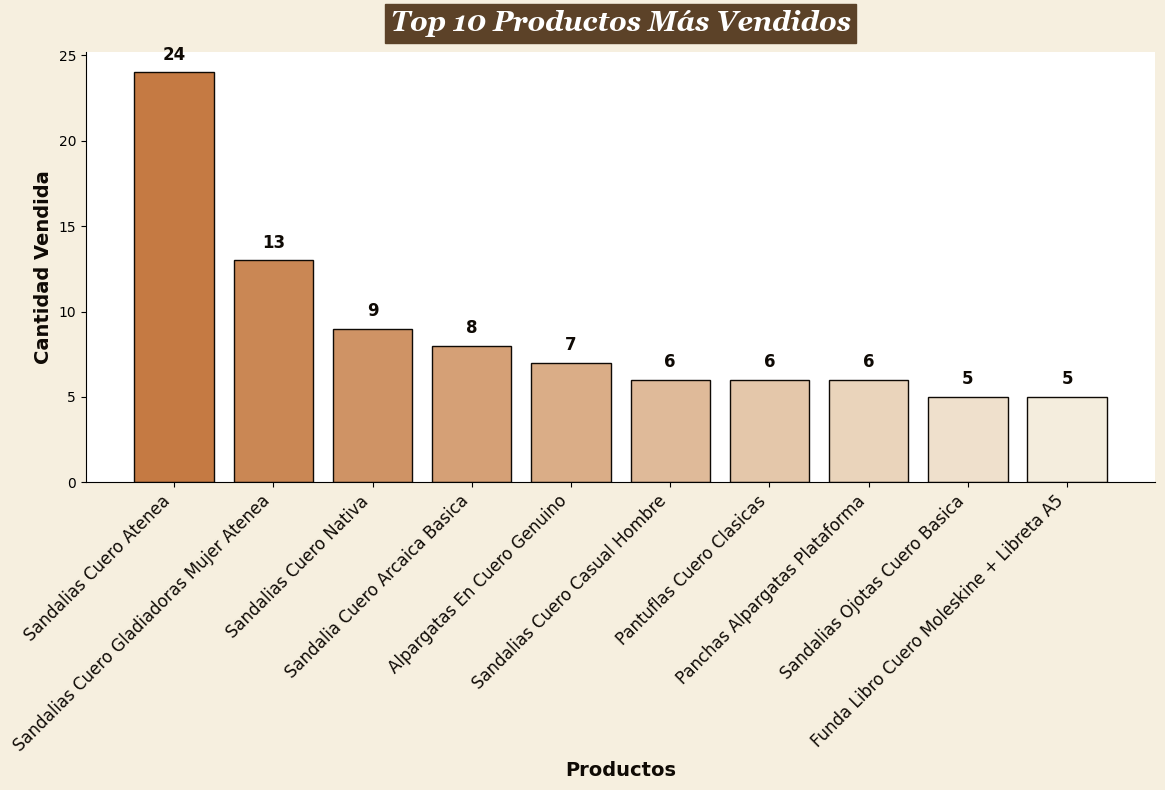

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos de la consulta SQL
productos_top_10 = pd.DataFrame({
    'titulo_publicacion': [
        'Sandalias Cuero Atenea', 
        'Sandalias Cuero Gladiadoras Mujer Atenea', 
        'Sandalias Cuero Nativa', 
        'Sandalia Cuero Arcaica Basica', 
        'Alpargatas En Cuero Genuino', 
        'Sandalias Cuero Casual Hombre', 
        'Pantuflas Cuero Clasicas', 
        'Panchas Alpargatas Plataforma', 
        'Sandalias Ojotas Cuero Basica', 
        'Funda Libro Cuero Moleskine + Libreta A5'
    ],
    'cantidad_vendida': [24, 13, 9, 8, 7, 6, 6, 6, 5, 5]
})

# Configurar colores
fondo_color = "#f6efdf"          # Fondo beige claro
titulo_fondo_color = "#5c4228"  # Fondo marrón oscuro del título
titulo_texto_color = "#ffffff"  # Texto blanco en el título
barra_color_inicial = "#c57a43"  # Marrón inicial
barra_color_final = "#f4eddd"   # Beige final
texto_color = "#0f0a05"         # Texto marrón oscuro

# Crear degradado de colores
colors = sns.blend_palette([barra_color_inicial, barra_color_final], n_colors=len(productos_top_10))

# Configurar la figura
plt.figure(figsize=(12, 8), facecolor=fondo_color)

# Crear gráfico de barras
bar_plot = plt.bar(
    productos_top_10['titulo_publicacion'], 
    productos_top_10['cantidad_vendida'], 
    color=colors, 
    edgecolor=texto_color
)

# Título estilizado
plt.title(
    'Top 10 Productos Más Vendidos', 
    fontsize=20, color=titulo_texto_color, 
    weight='bold', family='Georgia', style='italic',
    backgroundcolor=titulo_fondo_color, pad=15
)

# Etiquetas del eje X con rotación
plt.xticks(
    range(len(productos_top_10['titulo_publicacion'])), 
    productos_top_10['titulo_publicacion'], 
    rotation=45, ha='right', fontsize=12, color=texto_color
)

# Etiquetas del eje Y
plt.ylabel('Cantidad Vendida', fontsize=14, color=texto_color, weight='bold')
plt.xlabel('Productos', fontsize=14, color=texto_color, weight='bold')

# Agregar valores encima de las barras
for bar, value in zip(bar_plot, productos_top_10['cantidad_vendida']):
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() + 0.5, 
        f"{value}", 
        ha='center', va='bottom', fontsize=12, color=texto_color, weight='bold'
    )

# Ajustar diseño
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


### 20.7 Top 10 Productos Más Vendidos Excluyendo Calzados

**Descripción:**  
Muestra los 10 productos más vendidos que **no** pertenecen a la categoría de calzados, para ver qué otros ítems destacan.


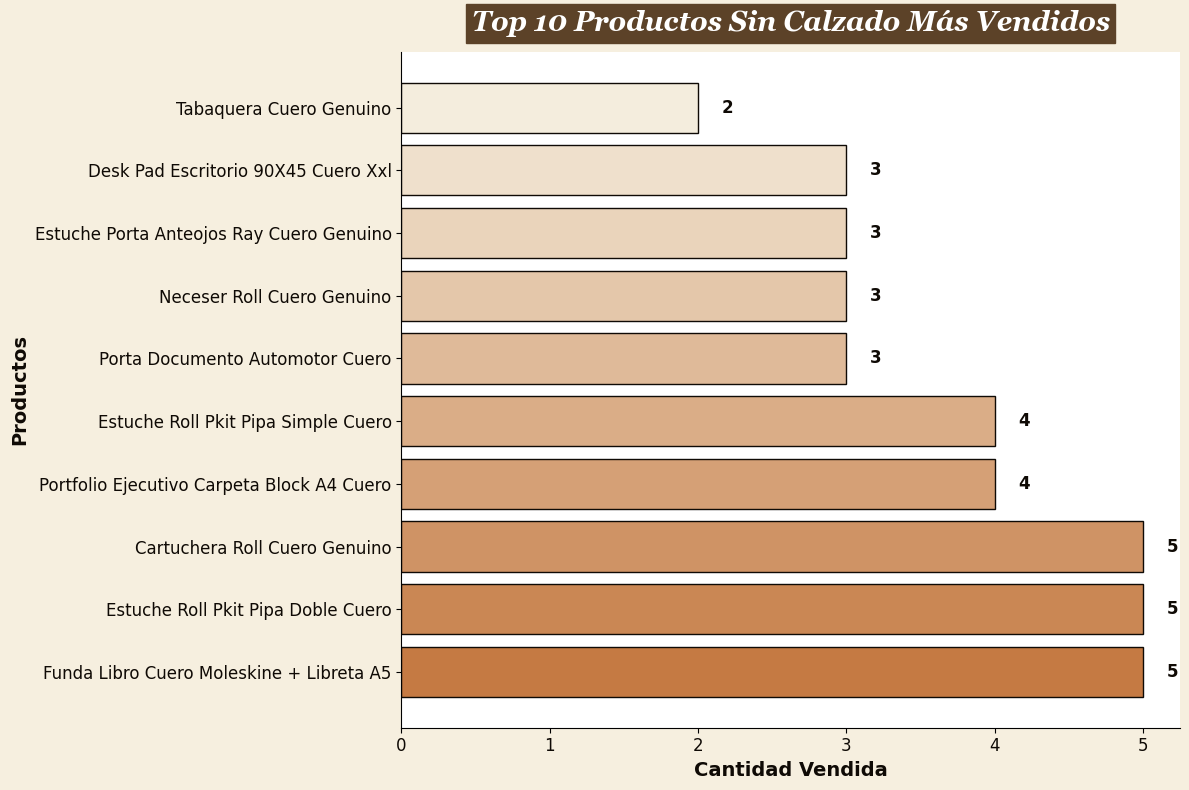

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos de la consulta SQL
productos_top_10_sin_calzado = pd.DataFrame({
    'titulo_publicacion': [
        'Funda Libro Cuero Moleskine + Libreta A5',
        'Estuche Roll Pkit Pipa Doble Cuero',
        'Cartuchera Roll Cuero Genuino',
        'Portfolio Ejecutivo Carpeta Block A4 Cuero',
        'Estuche Roll Pkit Pipa Simple Cuero',
        'Porta Documento Automotor Cuero',
        'Neceser Roll Cuero Genuino',
        'Estuche Porta Anteojos Ray Cuero Genuino',
        'Desk Pad Escritorio 90X45 Cuero Xxl',
        'Tabaquera Cuero Genuino'
    ],
    'cantidad_vendida': [5, 5, 5, 4, 4, 3, 3, 3, 3, 2]
})

# Configuración de colores
fondo_color = "#f6efdf"          # Fondo beige claro
titulo_fondo_color = "#5c4228"  # Fondo marrón oscuro del título
titulo_texto_color = "#ffffff"  # Texto blanco en el título
barra_color_inicial = "#c57a43"  # Marrón inicial
barra_color_final = "#f4eddd"   # Beige final
texto_color = "#0f0a05"         # Texto marrón oscuro

# Crear degradado de colores
colors = sns.blend_palette([barra_color_inicial, barra_color_final], n_colors=len(productos_top_10_sin_calzado))

# Configurar la figura
plt.figure(figsize=(12, 8), facecolor=fondo_color)

# Crear gráfico de barras horizontales
bar_plot = plt.barh(
    productos_top_10_sin_calzado['titulo_publicacion'], 
    productos_top_10_sin_calzado['cantidad_vendida'], 
    color=colors, 
    edgecolor=texto_color
)

# Título estilizado
plt.title(
    'Top 10 Productos Sin Calzado Más Vendidos', 
    fontsize=20, color=titulo_texto_color, 
    weight='bold', family='Georgia', style='italic',
    backgroundcolor=titulo_fondo_color, pad=15
)

# Etiquetas del eje X
plt.xlabel('Cantidad Vendida', fontsize=14, color=texto_color, weight='bold')

# Etiquetas del eje Y con productos
plt.ylabel('Productos', fontsize=14, color=texto_color, weight='bold')
plt.xticks(fontsize=12, color=texto_color)
plt.yticks(fontsize=12, color=texto_color)

# Agregar valores al final de las barras
for bar, value in zip(bar_plot, productos_top_10_sin_calzado['cantidad_vendida']):
    plt.text(
        bar.get_width() + 0.2, 
        bar.get_y() + bar.get_height() / 2, 
        f"{value}", 
        ha='center', va='center', fontsize=12, color=texto_color, weight='bold'
    )

# Ajustes finales
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


### 20.8 Top 10 Productos con Mayor Ingreso

**Descripción:**  
Lista los productos que generan más ingresos totales, permitiendo identificar los ítems premium o de mayor rentabilidad.


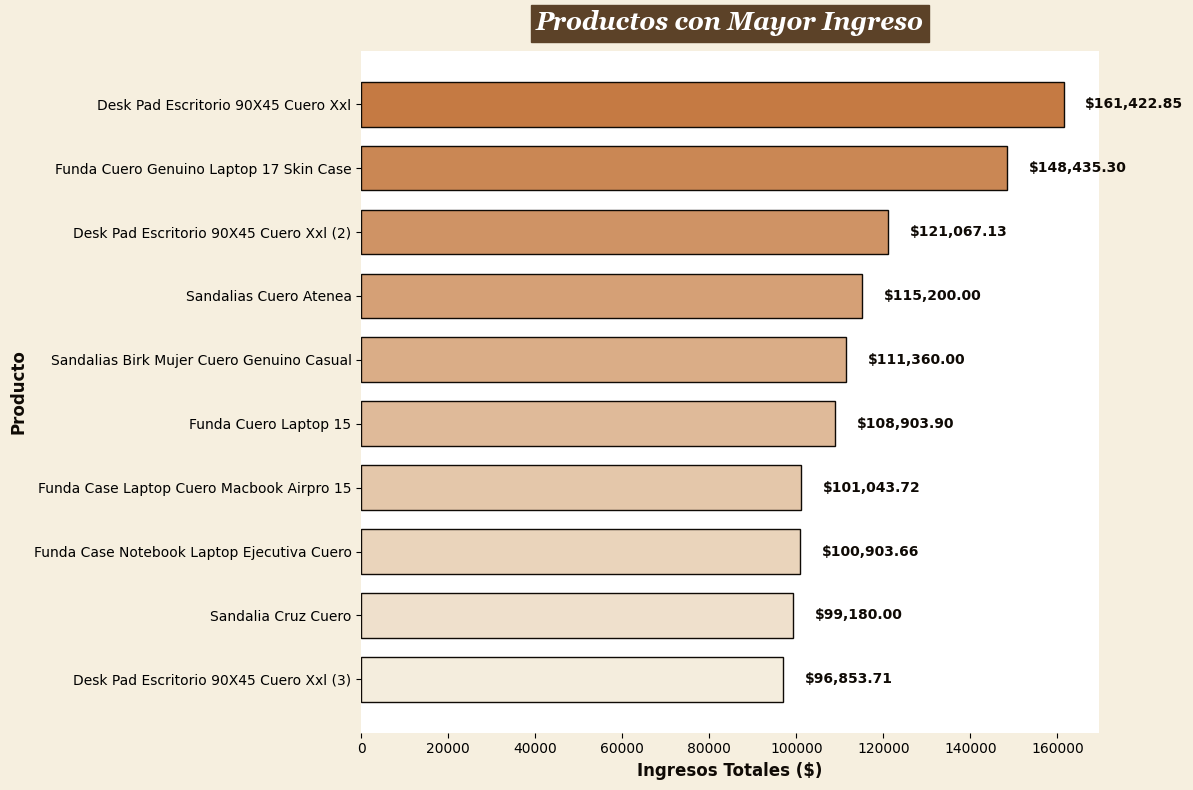

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos de la consulta SQL
productos_mayor_ingreso = pd.DataFrame({
    'titulo_publicacion': [
        'Desk Pad Escritorio 90X45 Cuero Xxl', 
        'Funda Cuero Genuino Laptop 17 Skin Case', 
        'Desk Pad Escritorio 90X45 Cuero Xxl (2)', 
        'Sandalias Cuero Atenea', 
        'Sandalias Birk Mujer Cuero Genuino Casual', 
        'Funda Cuero Laptop 15', 
        'Funda Case Laptop Cuero Macbook Airpro 15', 
        'Funda Case Notebook Laptop Ejecutiva Cuero', 
        'Sandalia Cruz Cuero', 
        'Desk Pad Escritorio 90X45 Cuero Xxl (3)'
    ],
    'ingresos_productos': [
        161422.85, 148435.30, 121067.13, 115200.00, 111360.00, 
        108903.90, 101043.72, 100903.66, 99180.00, 96853.71
    ]
})

# Configurar colores
fondo_color = "#f6efdf"          # Fondo beige claro
titulo_fondo_color = "#5c4228"  # Fondo marrón oscuro del título
titulo_texto_color = "#ffffff"  # Texto blanco en el título
barra_color_inicial = "#c57a43"  # Marrón inicial
barra_color_final = "#f4eddd"   # Beige final
texto_color = "#0f0a05"         # Texto marrón oscuro

# Crear degradado de colores
colors = sns.blend_palette([barra_color_inicial, barra_color_final], n_colors=len(productos_mayor_ingreso))

# Configurar la figura
plt.figure(figsize=(12, 8), facecolor=fondo_color)

# Crear gráfico de barras horizontales
bar_plot = plt.barh(
    productos_mayor_ingreso['titulo_publicacion'], 
    productos_mayor_ingreso['ingresos_productos'], 
    color=colors, 
    edgecolor=texto_color, 
    height=0.7
)

# Título estilizado
plt.title(
    'Productos con Mayor Ingreso', 
    fontsize=18, color=titulo_texto_color, 
    weight='bold', family='Georgia', style='italic',
    backgroundcolor=titulo_fondo_color, pad=15
)

# Etiquetas de los ejes
plt.ylabel('Producto', fontsize=12, color=texto_color, weight='bold')
plt.xlabel('Ingresos Totales ($)', fontsize=12, color=texto_color, weight='bold')

# Agregar montos al final de las barras
for bar, valor in zip(bar_plot, productos_mayor_ingreso['ingresos_productos']):
    plt.text(
        bar.get_width() + 5000,  # Mover el texto a la derecha de la barra
        bar.get_y() + bar.get_height() / 2, 
        f"${valor:,.2f}", 
        ha='left', va='center', fontsize=10, color=texto_color, weight='bold'
    )

# Ajustar diseño
plt.gca().invert_yaxis()  # Invertir el eje Y para que la barra más grande esté arriba
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.tight_layout()
plt.show()



## 21. Visualizaciones - Tabla `clientes`

Esta sección agrupa todas las **visualizaciones** relacionadas con la tabla `clientes`.

### Índice de Visualizaciones

1. **21.1 Cantidad de Clientes por Provincia**  
2. **21.2 Top 10 Ciudades con Más Ventas**  
3. **21.3 Barrios con Más Ventas en Capital Federal**  
4. **21.4 Distribución de Ventas en CABA (Mapa Folium)**  
5. **21.5 Distribución de Clientes por Rango de DNI**  
6. **21.6 Top 10 Clientes con Más Compras**

**Metodología de Visualización**  
En cada subapartado (21.x) se mostrará:  
- **Título y Descripción** de la gráfica.  
- **Código** (o referencia a la imagen) que genera la visualización (usando `matplotlib`, `seaborn`, `folium`, etc.).  
- (Opcional) **Interpretación** breve sobre la gráfica.

A continuación, se presentan las visualizaciones de **Clientes** en el **orden establecido**.


### 21.1 Cantidad de Clientes por Provincia

**Descripción:**  
Muestra la distribución de clientes en cada provincia argentina, evidenciando las zonas con mayor concentración de usuarios.


In [18]:
import geopandas as gpd

# Asegúrate de tener el archivo 'argentina_provincias.geojson' en el mismo directorio
geojson_path = "argentina_provincias.geojson"

try:
    mapa_argentina = gpd.read_file(geojson_path)
    print(mapa_argentina.head())
except Exception as e:
    print(f"Error: {e}")


                nombre                                           geometry
0              Tucumán  POLYGON ((-66.20361 -26.62782, -66.0498 -26.64...
1  Santiago del Estero  POLYGON ((-64.42108 -26.28356, -65.03906 -27.8...
2                Salta  POLYGON ((-66.11572 -26.21459, -65.85205 -26.3...
3                Jujuy  POLYGON ((-67.22534 -23.69483, -66.47827 -24.2...
4              Formosa  POLYGON ((-62.3584 -24.08659, -58.40332 -26.80...


C:\Users\Pilar\AppData\Local\Temp\ipykernel_15964\3132003058.py:55: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


C:\Users\Pilar\AppData\Local\Temp\ipykernel_15964\3132003058.py:56: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


C:\Users\Pilar\AppData\Local\Temp\ipykernel_15964\3132003058.py:60: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


C:\Users\Pilar\AppData\Local\Temp\ipykernel_15964\3132003058.py:62: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS befor

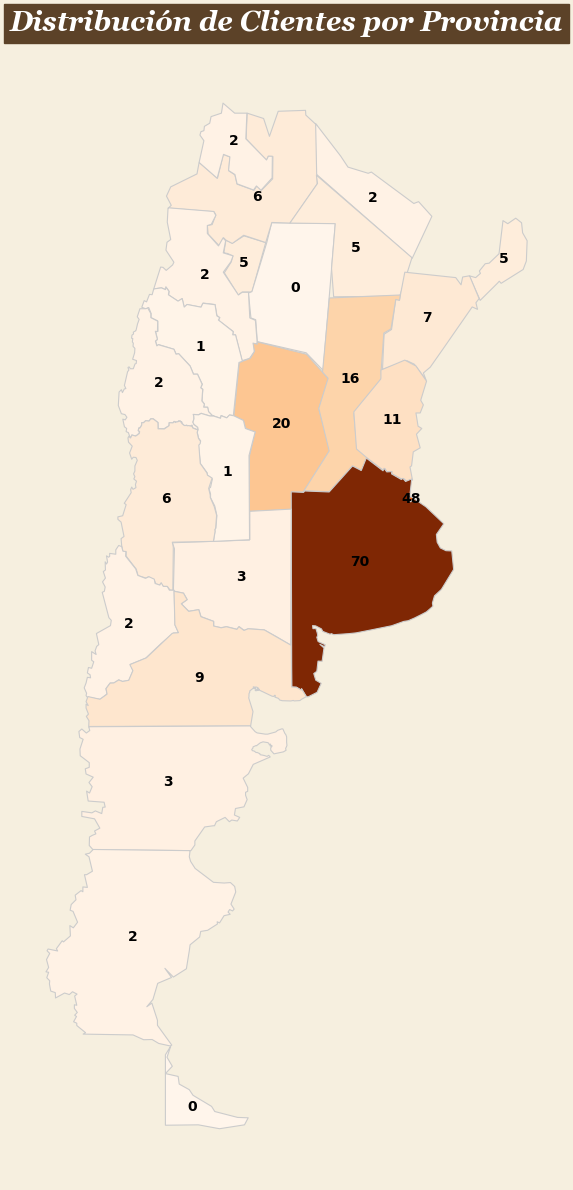

In [23]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Leer el archivo GeoJSON de Argentina
geojson_path = "argentina_provincias.geojson"
mapa_argentina = gpd.read_file(geojson_path)

# Datos de cantidad de clientes por provincia
cantidad_clientes_provincia = pd.DataFrame({
    'provincia': [
        "Buenos Aires", "Capital Federal", "Córdoba", "Santa Fe", "Entre Ríos",
        "Río Negro", "Corrientes", "Salta", "Mendoza", "Tucumán", "Misiones",
        "Chaco", "La Pampa", "Chubut", "Santa Cruz", "San Juan", "Neuquén",
        "Jujuy", "Formosa", "Catamarca", "San Luis", "La Rioja", None
    ],
    'cantidad_de_clientes': [
        70, 48, 20, 16, 11, 9, 7, 6, 6, 5, 5, 5, 3, 3, 2, 2, 2, 2, 2, 2, 1, 1, 1
    ]
})

# Convertir los nombres de provincias a mayúsculas para unificar con GeoJSON
cantidad_clientes_provincia['provincia'] = cantidad_clientes_provincia['provincia'].str.upper()
mapa_argentina['nombre'] = mapa_argentina['nombre'].str.upper()

# Unir datos de clientes con el mapa
mapa_unido = mapa_argentina.merge(
    cantidad_clientes_provincia,
    left_on="nombre",
    right_on="provincia",
    how="left"
)

# Rellenar valores NaN con 0 para las provincias sin clientes
mapa_unido['cantidad_de_clientes'] = mapa_unido['cantidad_de_clientes'].fillna(0)

# Configurar colores
fondo_color = "#f6efdf"  # Fondo beige claro
titulo_fondo_color = "#5c4228"  # Fondo marrón oscuro del título
titulo_texto_color = "#ffffff"  # Texto blanco en el título
cmap = plt.cm.Oranges  # Colores degradados

# Crear el mapa
fig, ax = plt.subplots(1, 1, figsize=(10, 12), facecolor=fondo_color)
mapa_unido.plot(
    column='cantidad_de_clientes',
    cmap=cmap,
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8'
)

# Añadir texto con las cantidades en el centro de cada provincia
for x, y, label in zip(
    mapa_unido.geometry.centroid.x, 
    mapa_unido.geometry.centroid.y, 
    mapa_unido['cantidad_de_clientes']
):
    # Ajustar manualmente las posiciones para provincias problemáticas
    if label == 6 and "SALTA" in mapa_unido.loc[mapa_unido.geometry.centroid.y == y, 'nombre'].values:
        plt.text(x, y - 0.5, int(label), ha='center', va='center', fontsize=10, color='black', weight='bold')
    elif label == 2 and "JUJUY" in mapa_unido.loc[mapa_unido.geometry.centroid.y == y, 'nombre'].values:
        plt.text(x, y + 0.3, int(label), ha='center', va='center', fontsize=10, color='black', weight='bold')
    else:
        plt.text(x, y, int(label), ha='center', va='center', fontsize=10, color='black', weight='bold')

# Configurar el título
plt.title(
    "Distribución de Clientes por Provincia",
    fontsize=20,
    color=titulo_texto_color,
    weight='bold',
    family='Georgia',
    style='italic',
    backgroundcolor=titulo_fondo_color,
    pad=15
)

# Ocultar ejes
ax.axis("off")

# Ajustes finales y mostrar
plt.tight_layout()
plt.show()


### 21.2 Top 10 Ciudades con Más Ventas

**Descripción:**  
Representa las ciudades con la mayor cantidad de ventas, permitiendo identificar polos de consumo significativos a nivel nacional.


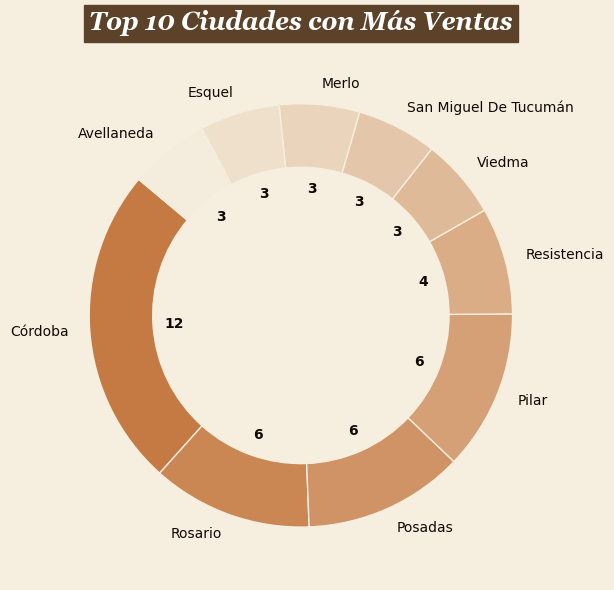

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos actualizados de la consulta SQL
ciudades_top_10 = pd.DataFrame({
    'ciudad': ['Córdoba', 'Rosario', 'Posadas', 'Pilar', 'Resistencia', 'Viedma', 
               'San Miguel De Tucumán', 'Merlo', 'Esquel', 'Avellaneda'],
    'total_ventas': [12, 6, 6, 6, 4, 3, 3, 3, 3, 3]
})

# Configurar colores y estilos
fondo_color = "#f6efdf"          # Fondo beige claro
titulo_fondo_color = "#5c4228"  # Fondo marrón oscuro del título
titulo_texto_color = "#ffffff"  # Texto blanco en el título
barra_color_inicial = "#c57a43"  # Marrón inicial
barra_color_final = "#f4eddd"   # Beige final
texto_color = "#0f0a05"         # Texto marrón oscuro

# Crear degradado de colores
colors = sns.blend_palette([barra_color_inicial, barra_color_final], n_colors=len(ciudades_top_10))

# Crear la figura
plt.figure(figsize=(10, 6), facecolor=fondo_color)

# Gráfico de rosca
wedges, texts, autotexts = plt.pie(
    ciudades_top_10['total_ventas'],
    labels=ciudades_top_10['ciudad'],
    autopct=lambda p: f"{int(round(p * sum(ciudades_top_10['total_ventas']) / 100))}",
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.3, edgecolor=fondo_color)
)

# Estilizar las etiquetas
for text in texts:
    text.set_color(texto_color)
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_color(texto_color)
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

# Título estilizado
plt.title(
    'Top 10 Ciudades con Más Ventas', 
    fontsize=18, color=titulo_texto_color, weight='bold',
    family='Georgia', style='italic', backgroundcolor=titulo_fondo_color, pad=15
)

# Ajustes finales
plt.tight_layout()
plt.show()


### 21.3 Barrios con Más Ventas en Capital Federal

**Descripción:**  
Enumera los barrios que concentran el mayor número de ventas dentro de Capital Federal, resaltando áreas de alta demanda.


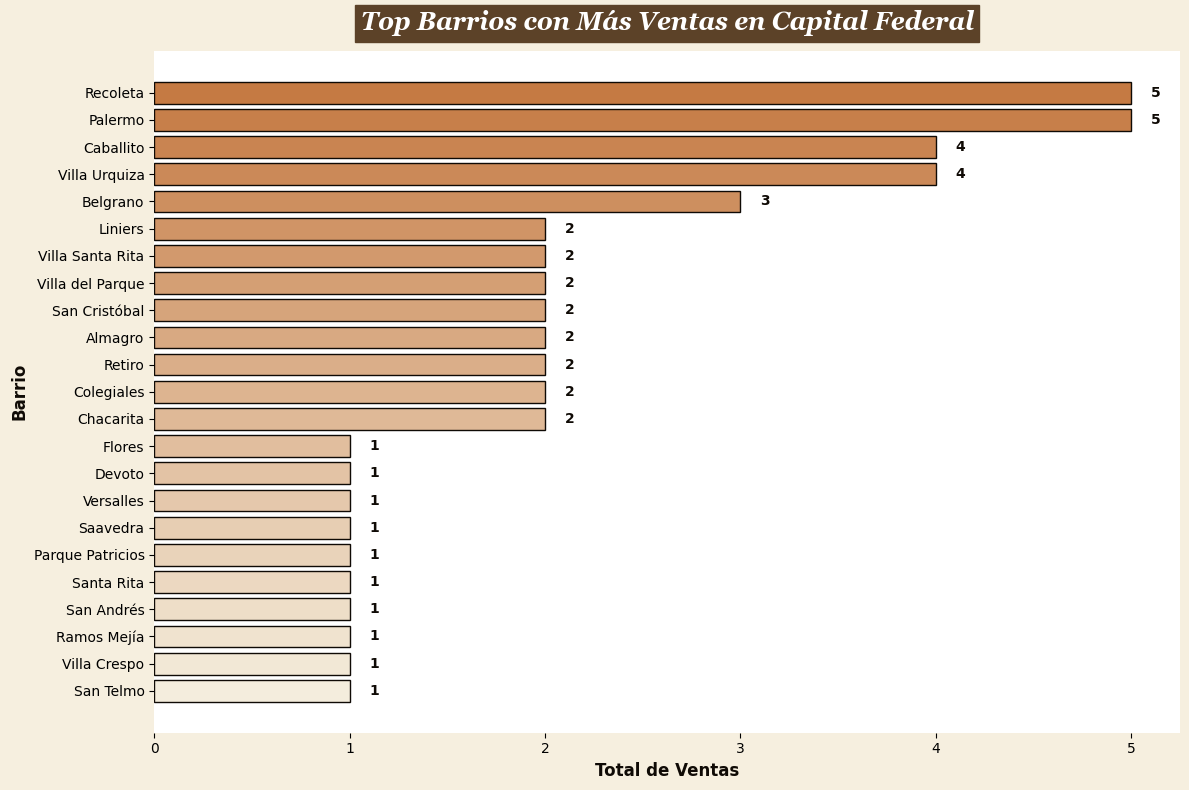

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos actualizados de ventas por barrio
data = pd.DataFrame({
    'barrio': [
        "Recoleta", "Palermo", "Caballito", "Villa Urquiza", "Belgrano", "Chacarita", "Colegiales", "Retiro",
        "Almagro", "Liniers", "Villa del Parque", "San Cristóbal", "Villa Santa Rita", "Flores", "Devoto",
        "Versalles", "Saavedra", "Parque Patricios", "Santa Rita", "San Andrés", "Ramos Mejía", "Villa Crespo",
        "San Telmo"
    ],
    'total_ventas': [
        5, 5, 4, 4, 3, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
    ]
})

# Ordenar los datos por total de ventas de mayor a menor
data = data.sort_values(by="total_ventas", ascending=False)

# Configurar colores y estilos
fondo_color = "#f6efdf"          # Fondo beige claro
titulo_fondo_color = "#5c4228"  # Fondo marrón oscuro del título
titulo_texto_color = "#ffffff"  # Texto blanco en el título
barra_color_inicial = "#c57a43"  # Marrón inicial
barra_color_final = "#f4eddd"   # Beige final
texto_color = "#0f0a05"         # Texto marrón oscuro

# Crear degradado de colores
colors = sns.blend_palette([barra_color_inicial, barra_color_final], n_colors=len(data))

# Configurar la figura
plt.figure(figsize=(12, 8), facecolor=fondo_color)

# Crear gráfico de barras
bar_plot = plt.barh(
    data['barrio'], 
    data['total_ventas'], 
    color=colors, 
    edgecolor=texto_color
)

# Título estilizado
plt.title(
    'Top Barrios con Más Ventas en Capital Federal', 
    fontsize=18, color=titulo_texto_color, weight='bold',
    family='Georgia', style='italic', backgroundcolor=titulo_fondo_color, pad=15
)

# Etiquetas del eje Y
plt.ylabel('Barrio', fontsize=12, color=texto_color, weight='bold')
plt.xlabel('Total de Ventas', fontsize=12, color=texto_color, weight='bold')

# Añadir valores dentro de las barras
for bar, total in zip(bar_plot, data['total_ventas']):
    plt.text(
        bar.get_width() + 0.1,  # Ajustar ligeramente el valor hacia afuera
        bar.get_y() + bar.get_height() / 2, 
        f"{total}", 
        ha='left', va='center', fontsize=10, color=texto_color, weight='bold'
    )

# Ajustes finales
plt.gca().invert_yaxis()  # Invertir el eje Y para la barra más grande arriba
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.tight_layout()
plt.show()



#### 21.4 Distribución de Ventas en CABA (Mapa Folium)

**Descripción:**  
Visualiza sobre un mapa los puntos de mayor actividad de ventas en la Ciudad de Buenos Aires, facilitando la identificación geográfica de “hot spots”.


In [5]:
import pandas as pd
import folium
from IPython.display import display
from matplotlib import cm
from matplotlib.colors import to_hex

# Datos de ventas por barrio
data = pd.DataFrame({
    'barrio': [
        "Recoleta", "Palermo", "Caballito", "Villa Urquiza", "Belgrano", "Chacarita", "Colegiales", "Retiro",
        "Almagro", "Liniers", "Villa del Parque", "San Cristóbal", "Villa Santa Rita", "Flores", "Devoto",
        "Versalles", "Saavedra", "Parque Patricios", "Santa Rita", "San Andrés", "Ramos Mejía", "Villa Crespo",
        "San Telmo"
    ],
    'ventas': [
        5, 5, 4, 4, 3, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
    ],
    'lat': [
        -34.5892, -34.5770, -34.6187, -34.5642, -34.5624, -34.5890, -34.5797, -34.5917,
        -34.6063, -34.6395, -34.6045, -34.6196, -34.6189, -34.6241, -34.6066, -34.6326,
        -34.5658, -34.6296, -34.6189, -34.5870, -34.6410, -34.5972, -34.6342
    ],
    'lon': [
        -58.4000, -58.4302, -58.4452, -58.4898, -58.4508, -58.4513, -58.4405, -58.3758,
        -58.4286, -58.5354, -58.4820, -58.3923, -58.4793, -58.4506, -58.4919, -58.5170,
        -58.4786, -58.4053, -58.4753, -58.5508, -58.5613, -58.4263, -58.3736
    ]
})

# Crear el mapa centrado en Buenos Aires
m = folium.Map(location=[-34.6037, -58.3816], zoom_start=12, tiles="OpenStreetMap")

# Crear una escala de colores basada en las ventas (de naranja claro a marrón oscuro)
cmap = cm.get_cmap('YlOrBr', 5)  # Paleta de colores Yellow-Orange-Brown
color_scale = data['ventas'] / data['ventas'].max()  # Normalizar las ventas entre 0 y 1

# Añadir círculos con números
for idx, row in data.iterrows():
    # Determinar el tamaño del círculo (mínimo 10 para ventas bajas)
    radius = max(10, row['ventas'] * 5)
    
    # Dibujar el círculo
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=radius,  # Tamaño aumentado
        color='black',  # Borde negro para contraste
        fill=True,
        fill_color=to_hex(cmap(color_scale[idx])),  # Color basado en escala
        fill_opacity=0.9,
    ).add_to(m)
    
    # Ajustar el tamaño del texto según el tamaño del círculo
    font_size = max(12, radius // 2)  # Aumentar el tamaño de fuente para círculos pequeños
    
    # Añadir el texto dentro del círculo
    folium.Marker(
        location=[row['lat'], row['lon']],
        icon=folium.DivIcon(html=f"""
            <div style="font-size: {font_size}px; color: black; font-weight: bold; text-align: center;">
                {row['ventas']}
            </div>
        """)
    ).add_to(m)

# Mostrar el mapa en Jupyter Notebook
display(m)


C:\Users\Pilar\AppData\Local\Temp\ipykernel_2096\626152006.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrBr', 5)  # Paleta de colores Yellow-Orange-Brown


### 21.5 Distribución de Clientes por Rango de DNI

**Descripción:**  
Clasifica a los clientes según su rango de DNI, ofreciendo una aproximación a diferentes grupos etarios o históricos.


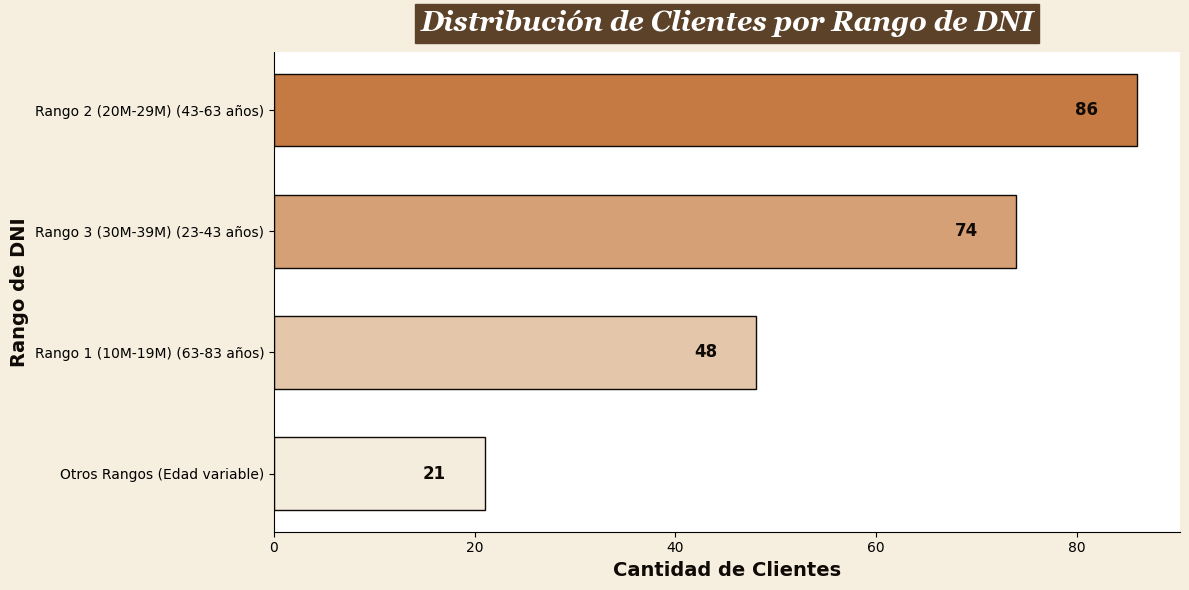

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos de la consulta SQL con aproximación de edades
datos_dni = pd.DataFrame({
    'Rango': [
        'Rango 2 (20M-29M) (43-63 años)',
        'Rango 3 (30M-39M) (23-43 años)',
        'Rango 1 (10M-19M) (63-83 años)',
        'Otros Rangos (Edad variable)'
    ],
    'Cantidad': [86, 74, 48, 21]
})

# Configuración de colores y estilo
fondo_color = "#f6efdf"
titulo_fondo_color = "#5c4228"
titulo_texto_color = "#ffffff"
barra_color_inicial = "#c57a43"
barra_color_final = "#f4eddd"
texto_color = "#0f0a05"

# Crear degradado de colores
colors = sns.blend_palette([barra_color_inicial, barra_color_final], n_colors=len(datos_dni))

# Configuración de la figura
plt.figure(figsize=(12, 6), facecolor=fondo_color)

# Crear barras apiladas
bar_plot = plt.barh(
    datos_dni['Rango'], 
    datos_dni['Cantidad'], 
    color=colors, 
    edgecolor=texto_color, 
    height=0.6
)

# Título estilizado
plt.title(
    "Distribución de Clientes por Rango de DNI", 
    fontsize=20, color=titulo_texto_color, weight="bold",
    family='Georgia', style="italic", backgroundcolor=titulo_fondo_color, pad=15
)

# Etiquetas de los ejes
plt.xlabel("Cantidad de Clientes", fontsize=14, color=texto_color, weight="bold")
plt.ylabel("Rango de DNI", fontsize=14, color=texto_color, weight="bold")

# Añadir valores dentro de las barras
for bar, value in zip(bar_plot, datos_dni['Cantidad']):
    plt.text(
        bar.get_width() - 5, 
        bar.get_y() + bar.get_height() / 2, 
        str(value), 
        ha='center', va='center', fontsize=12, color=texto_color, weight="bold"
    )

# Ajustes finales
plt.gca().invert_yaxis()  # Invertir el eje Y para que los valores más altos estén arriba
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()




### 21.6 Top 10 Clientes con Más Compras

**Descripción:**  
Muestra los clientes con mayor número de compras, ilustrando el grado de fidelidad y potencial de compra recurrente.


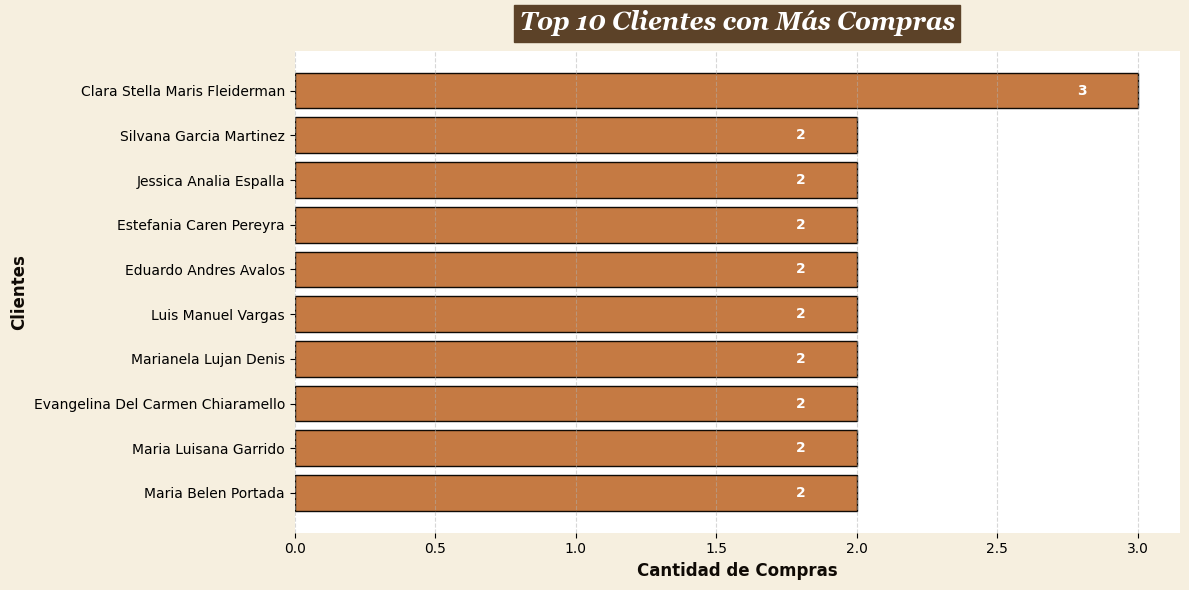

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Datos de la consulta SQL
clientes_mas_compras = pd.DataFrame({
    'nombre_cliente': [
        'Clara Stella Maris Fleiderman',
        'Silvana Garcia Martinez',
        'Jessica Analia Espalla',
        'Estefania Caren Pereyra',
        'Eduardo Andres Avalos',
        'Luis Manuel Vargas',
        'Marianela Lujan Denis',
        'Evangelina Del Carmen Chiaramello',
        'Maria Luisana Garrido',
        'Maria Belen Portada'
    ],
    'total_compras': [3, 2, 2, 2, 2, 2, 2, 2, 2, 2]
})

# Configuración de estilo
fondo_color = "#f6efdf"          # Fondo beige claro
titulo_fondo_color = "#5c4228"  # Fondo marrón oscuro del título
titulo_texto_color = "#ffffff"  # Texto blanco en el título
barra_color_inicial = "#c57a43" # Marrón inicial
barra_color_final = "#f4eddd"   # Beige final
texto_color = "#0f0a05"         # Texto marrón oscuro

# Crear degradado de colores
colors = [barra_color_inicial] * len(clientes_mas_compras)

# Configurar la figura
plt.figure(figsize=(12, 6), facecolor=fondo_color)

# Crear gráfico de barras horizontales
bar_plot = plt.barh(
    clientes_mas_compras['nombre_cliente'], 
    clientes_mas_compras['total_compras'], 
    color=colors, 
    edgecolor=texto_color
)

# Añadir título
plt.title(
    'Top 10 Clientes con Más Compras', 
    fontsize=18, color=titulo_texto_color, weight='bold',
    family='Georgia', style='italic', backgroundcolor=titulo_fondo_color, pad=15
)

# Etiquetas de los ejes
plt.xlabel('Cantidad de Compras', fontsize=12, color=texto_color, weight='bold')
plt.ylabel('Clientes', fontsize=12, color=texto_color, weight='bold')

# Añadir valores dentro de las barras
for bar, value in zip(bar_plot, clientes_mas_compras['total_compras']):
    plt.text(
        value - 0.2, 
        bar.get_y() + bar.get_height() / 2, 
        str(value), 
        ha='center', va='center', fontsize=10, color='white', weight='bold'
    )

# Ajustes estéticos
plt.gca().invert_yaxis()  # Cliente con más compras arriba
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# Mostrar gráfico
plt.show()


## 22. Visualizaciones - Tabla `envios`

Esta sección agrupa todas las **visualizaciones** relacionadas con la tabla `envios`.

### Índice de Visualizaciones

1. **22.1 Tiempo Promedio de Entrega**  
2. **22.2 Envíos por Intervalo de Tiempo del Día**  
3. **22.3 Envíos por Día de la Semana**  

**Metodología de Visualización**  
En cada subapartado (22.x) se mostrará:  
- **Título y Descripción** de la gráfica.  
- **Código** (o referencia a la imagen) que genera la visualización (usando `matplotlib`, `seaborn`, etc.).  
- (Opcional) **Interpretación** breve sobre la gráfica.

A continuación, se presentan las visualizaciones de **Envíos** en el **orden establecido**.

---



### 22.1 Tiempo Promedio de Entrega

**Descripción:**  
Calcula el tiempo promedio de entrega (en días) desde la fecha de envío hasta la fecha de entrega, sirviendo como indicador de eficiencia logística.


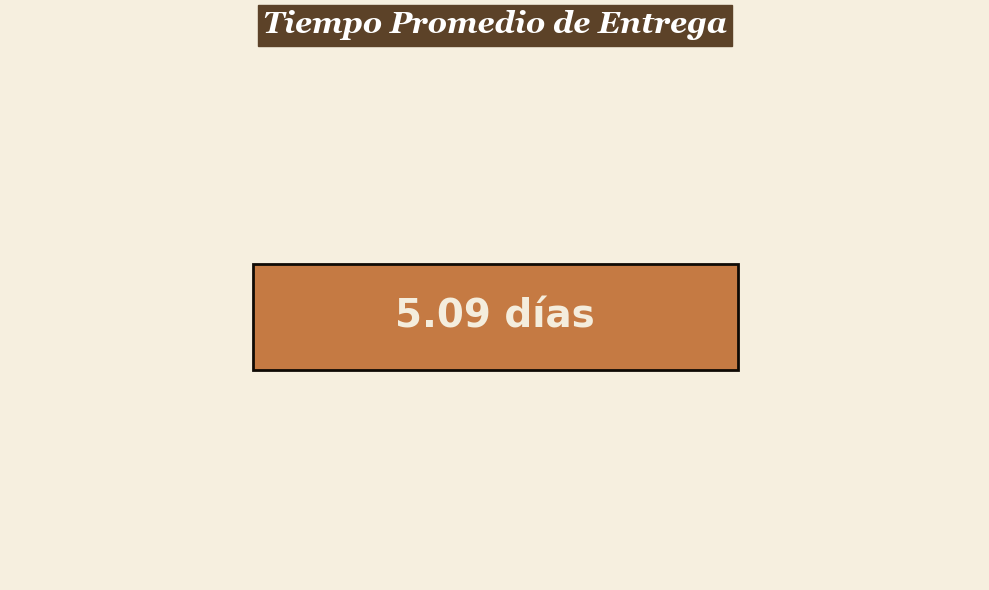

In [4]:
import matplotlib.pyplot as plt

# Tiempo promedio de entrega (resultado)
tiempo_promedio_entrega = 5.09

# Estilo
fondo_color = "#f6efdf"
titulo_fondo_color = "#5c4228"
titulo_texto_color = "#ffffff"
texto_color = "#0f0a05"

# Crear figura
plt.figure(figsize=(10, 6), facecolor=fondo_color)

# Dibujar un rectángulo con el tiempo promedio
plt.gca().add_patch(plt.Rectangle((0.25, 0.4), 0.5, 0.2, color="#c57a43", ec=texto_color, lw=2))
plt.text(0.5, 0.5, f"{tiempo_promedio_entrega:.2f} días", 
         ha='center', va='center', fontsize=28, color="#f4eddd", weight='bold')

# Personalizar título
plt.title(
    'Tiempo Promedio de Entrega', 
    fontsize=22, color=titulo_texto_color, 
    weight='bold', family='Georgia', style='italic',  # Cursiva similar a Brush Script
    backgroundcolor=titulo_fondo_color, pad=15
)

# Eliminar ejes y cuadrícula
plt.axis('off')

# Ajustar diseño
plt.tight_layout()
plt.show()


### 22.2 Envíos por Intervalo de Tiempo del Día

**Descripción:**  
Clasifica la hora de envío en intervalos (tarde, noche, mañana), permitiendo identificar los horarios pico de actividad de despacho.

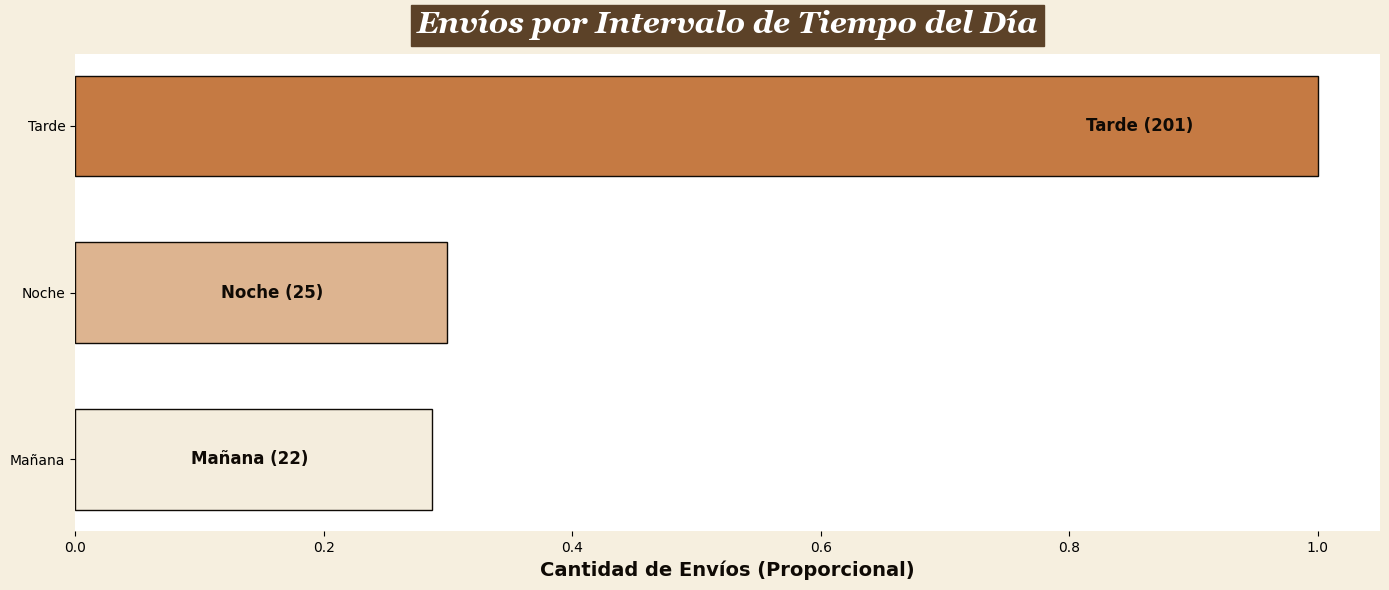

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos actualizados para envíos por intervalo de tiempo
envios_intervalo_tiempo = pd.DataFrame({
    'intervalo_tiempo': ['Tarde', 'Noche', 'Mañana'],
    'total_envios': [201, 25, 22]
})

# Estilo
fondo_color = "#f6efdf"
titulo_fondo_color = "#5c4228"
titulo_texto_color = "#ffffff"
barra_color_inicial = "#c57a43"
barra_color_final = "#f4eddd"
texto_color = "#0f0a05"

# Crear degradado de colores
colors = sns.blend_palette([barra_color_inicial, barra_color_final], n_colors=len(envios_intervalo_tiempo))

# Configurar figura
plt.figure(figsize=(14, 6), facecolor=fondo_color)

# Normalizar valores para ajustar proporciones de las barras
envios_intervalo_tiempo['proporcion'] = envios_intervalo_tiempo['total_envios'] / max(envios_intervalo_tiempo['total_envios']) * 0.8 + 0.2

# Crear gráfico de barras
bar_plot = plt.barh(
    envios_intervalo_tiempo['intervalo_tiempo'], 
    envios_intervalo_tiempo['proporcion'], 
    color=colors, edgecolor=texto_color, height=0.6
)

# Título estilizado
plt.title(
    'Envíos por Intervalo de Tiempo del Día', 
    fontsize=22, color=titulo_texto_color, weight='bold', family='Georgia', 
    style='italic', backgroundcolor=titulo_fondo_color, pad=15
)

# Etiquetas del eje X
plt.xlabel('Cantidad de Envíos (Proporcional)', fontsize=14, color=texto_color, weight='bold')

# Agregar valores con cantidad entre paréntesis dentro de las barras
for bar, intervalo, total in zip(bar_plot, envios_intervalo_tiempo['intervalo_tiempo'], envios_intervalo_tiempo['total_envios']):
    plt.text(
        bar.get_width() - 0.1, bar.get_y() + bar.get_height() / 2, 
        f"{intervalo} ({total})", 
        ha='right', va='center', fontsize=12, color=texto_color, weight='bold'
    )

# Ajustes finales
plt.gca().invert_yaxis()  # Invertir el eje Y para la barra más grande arriba
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.tight_layout()
plt.show()




### 22.3 Envíos por Día de la Semana

**Descripción:**  
Muestra la cantidad de envíos para cada día de la semana, destacando posibles concentraciones en días laborales o fines de semana.

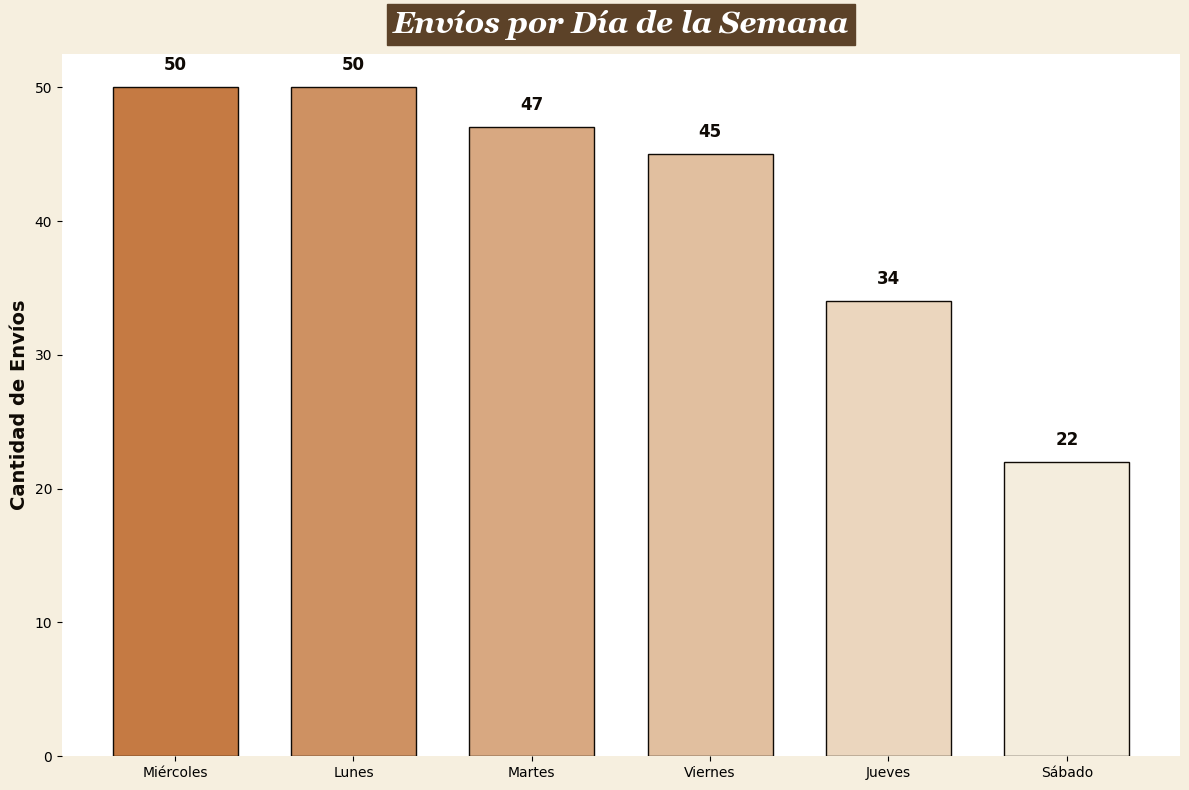

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos actualizados para envíos por día de la semana
envios_por_dia = pd.DataFrame({
    'dia_semana': ['Miércoles', 'Lunes', 'Martes', 'Viernes', 'Jueves', 'Sábado'],
    'total_envios': [50, 50, 47, 45, 34, 22]  # Sumar "Sin Detallar" a "Sábado"
})

# Estilo
fondo_color = "#f6efdf"
titulo_fondo_color = "#5c4228"
titulo_texto_color = "#ffffff"
barra_color_inicial = "#c57a43"
barra_color_final = "#f4eddd"
texto_color = "#0f0a05"

# Crear degradado de colores
colors = sns.blend_palette([barra_color_inicial, barra_color_final], n_colors=len(envios_por_dia))

# Configurar figura
plt.figure(figsize=(12, 8), facecolor=fondo_color)

# Crear gráfico de barras
bar_plot = plt.bar(
    envios_por_dia['dia_semana'], 
    envios_por_dia['total_envios'], 
    color=colors, edgecolor=texto_color, width=0.7
)

# Título estilizado
plt.title(
    'Envíos por Día de la Semana', 
    fontsize=22, color=titulo_texto_color, weight='bold', family='Georgia', 
    style='italic', backgroundcolor=titulo_fondo_color, pad=15
)

# Etiquetas del eje Y
plt.ylabel('Cantidad de Envíos', fontsize=14, color=texto_color, weight='bold')

# Agregar valores dentro de las barras
for bar, total in zip(bar_plot, envios_por_dia['total_envios']):
    plt.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, 
        f"{total}", ha='center', va='bottom', fontsize=12, color=texto_color, weight='bold'
    )

# Ajustes finales
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.tight_layout()
plt.show()


